# Multi-Leg Vessel-Cargo Optimization (Cargill Hackathon)

Run from project root (directory containing data/, processed/, outputs/). Execute cells top to bottom.

This notebook implements a **multi-leg routing optimization** that:
- **Guarantees all 3 committed cargoes are lifted** (exactly once)
- Allows **Cargill vessels to execute multiple cargoes sequentially** (including optional market cargoes)
- Uses **market vessels only for committed cargoes**
- Computes **leg-by-leg fuel burn with time-varying bunker prices** (forward curve)
- **Explicitly recommends which market cargoes to take** and where in each vessel's sequence

## Key Features
- **Sequential legs**: Vessels can carry one cargo at a time, but chain multiple cargoes
- **Waiting allowed**: Vessels can wait at anchorage if arriving before laycan start
- **Realistic distances**: Uses searoute-calculated maritime distances
- **Time-varying fuel costs**: Bunker prices from forward curve based on actual voyage dates

## Notebook Outline

### I. Setup & Data
- Cell 1: Install dependencies (ortools, pandas, folium, matplotlib)
- Cell 2: Load CSVs (vessels, cargoes, distances, bunker, freight rates)

### II. Freight Calculator Pipeline
- Run FreightCalculator: all combinations, optimize_portfolio, scenario_china_delay, scenario_bunker_increase
- Output: optimal assignments, scenario thresholds

### III. Report Visualizations
- Viz 1: Voyage profit and TCE comparison
- Viz 2: Cost breakdown (revenue vs bunker vs port)
- Viz 3: Risk-adjusted vs base-case profit
- Viz 4: Scenario thresholds (China delay, bunker %)
- Viz 5: Geographical voyage paths (folium/matplotlib)
- Viz 6: Best vs worst voyage side-by-side
- Viz 7: Geo comparison (best vs worst overlaid)
- Viz 8: Same cargo, different vessels

### IV. Preprocessing
- Preprocess vessels (Cargill + market): hire rate from FFA 5TC, ETD, speeds, consumption
- Preprocess cargoes: quantity, laycan, ports, freight rate

### V. Leg Evaluator
- evaluate_leg(): ballast, waiting, laden, port time; fuel, hire, revenue, profit, TCE
- Arc generation for Cargill and market vessels

### VI. ML Risk Simulation
- Initialize MLRiskSimulator (weather, congestion, voyage uncertainty)
- Apply risk-adjusted delays and economics

### VII. CP-SAT Optimization
- Build flow model: flow conservation, cargo coverage, DWT, laycan
- Solve, extract assignments, portfolio profit

### VIII. Scenario Analysis
- Scenario 1: China port delay threshold
- Scenario 2: Bunker price increase threshold

### IX. Additional Analysis
- Route visualization (folium map), sensitivity analysis, explainability

### X. Chatbot Demo
- Example queries (optional; requires API keys)

In [46]:
# Cell 1: Install required libraries
# Run this cell first - it will install dependencies if not already installed
%pip install ortools pandas folium matplotlib -q

print("✓ Libraries installed/verified")

Note: you may need to restart the kernel to use updated packages.
✓ Libraries installed/verified


In [47]:
# Cell 2: Load all CSVs (run from project root)
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timedelta
import re

base = Path("data")
if not base.exists():
    base = Path.cwd() / "data"
if not base.exists():
    raise FileNotFoundError("Run from project root (directory containing data/)")
OUTPUTS_DIR = Path("outputs/reports")
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_MAPS = Path("outputs/maps")
OUTPUTS_MAPS.mkdir(parents=True, exist_ok=True)

# Load vessel data

#SHOWS THE DATA OF CARGILLL VESSELS BASICALLY ITS NAME , DWT , ECONOMICAL SPEED , PORT CONSUMPTION , SEA CONSUMPTION , ETC.
print("Loading vessel data...")
cargill_vessels = pd.read_csv(base / "Cargill_Capesize_Vessels.csv")
market_vessels = pd.read_csv(base / "Market_Vessels_Formatted.csv")

# Load cargo data

#SHOWS THE DATA OF CARGILL CARGES BASICALLY ITS ID , QUANTITY, IT SHOULD ALSO ACCOUNT FOR THE LOAD TIME , LOADING COST AT PORT , ETC.
print("Loading cargo data...")
cargill_cargoes = pd.read_csv(base / "Cargill_Committed_Cargoes_Structured.csv")
market_cargoes = pd.read_csv(base / "Market_Cargoes_Structured.csv")

# Load port distances

#DISTANCES BETWEEN TWO PORTS IN NAUTICAL MILES
print("Loading port distances...")
port_distances = pd.read_csv(base / "Port Distances.csv")

# Load port locations
#COORDINATES OF THE PORTS WE ARE CONCERENED WITH 
print("Loading port locations...")
port_locations = pd.read_csv(base / "port_locations.csv")

# Load bunker forward curve

#THE BUNKER PRICE AT DIFFFERENT PORTS AND PROJECTED FOR THE FUTURE TOO
print("Loading bunker forward curve...")
bunker_forward_curve = pd.read_csv(base / "bunker_forward_curve.csv")

# Load freight rates
#SO WE USE THE FFA REOPORT TO ESTIMATE THE FRIEGHT RATE OF A PARTICULAR VESSEL TRAVELLING A PARTICULAR ROUTE , AND ALSO PROJECTED FOR THE FUTURE
print("Loading freight rates...")
freight_rates = pd.read_csv(base / "freight_rates.csv")

print("\n✓ All data loaded successfully!")
print(f"Cargill vessels: {len(cargill_vessels)}")
print(f"Market vessels: {len(market_vessels)}")
print(f"Cargill cargoes: {len(cargill_cargoes)}")
print(f"Market cargoes: {len(market_cargoes)}")
print(f"Port distances: {len(port_distances)}")
print(f"Bunker locations: {len(bunker_forward_curve)}")
print(f"Freight routes: {len(freight_rates)}")

Loading vessel data...
Loading cargo data...
Loading port distances...
Loading port locations...
Loading bunker forward curve...
Loading freight rates...

✓ All data loaded successfully!
Cargill vessels: 4
Market vessels: 11
Cargill cargoes: 3
Market cargoes: 8
Port distances: 15661
Bunker locations: 18
Freight routes: 4


## Freight Calculator Pipeline (Existing Module)

Runs the freight_calculator module for base case TCE, vessel-cargo optimization, and scenario analysis (China delay, bunker price). Expect: assignments table, scenario thresholds.

In [48]:
# Freight Calculator: base case, optimization, scenario analysis
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

try:
    from freight_calculator import FreightCalculator
    calc = FreightCalculator()
    
    # Base case: all combinations + optimal assignments
    all_combos = calc.calculate_all_combinations()
    assignments, _ = calc.optimize_portfolio()
    
    print("OPTIMAL VESSEL-CARGO ASSIGNMENTS (Base Case)")
    print("-" * 60)
    for _, r in assignments.iterrows():
        print(f"  {r['Vessel']:20} -> {r['Route']:30}  TCE: ${r['TCE_USD_per_day']:,.0f}/day  Profit: ${r['Total_Voyage_Profit_USD']:,.0f}")
    print(f"\n  Total Portfolio Profit: ${assignments['Total_Voyage_Profit_USD'].sum():,.0f}")
    
    # Scenario analysis
    delay_df = calc.scenario_china_delay(assignments)
    bunker_df = calc.scenario_bunker_increase(assignments)
    
    print("\nSCENARIO THRESHOLDS")
    print("-" * 60)
    neg_delay = delay_df[delay_df["Total_Portfolio_Profit"] < 0]
    neg_bunker = bunker_df[bunker_df["Total_Portfolio_Profit"] < 0]
    print(f"  China port delay (profit<0): {neg_delay.iloc[0]['China_Delay_Days']} days" if len(neg_delay) > 0 else "  China delay: profit positive up to max tested")
    print(f"  VLSFO increase (profit<0): +{neg_bunker.iloc[0]['Bunker_Increase_Pct']}%" if len(neg_bunker) > 0 else "  Bunker: profit positive up to max tested")
    
    FC_AVAILABLE = True
except Exception as e:
    print(f"Freight calculator not available: {e}")
    FC_AVAILABLE = False

OPTIMAL VESSEL-CARGO ASSIGNMENTS (Base Case)
------------------------------------------------------------
  OCEAN HORIZON        -> West Africa – China             TCE: $28,949/day  Profit: $902,439
  GOLDEN ASCENT        -> Brazil – China                  TCE: $20,627/day  Profit: $493,317
  ANN BELL             -> Australia – China               TCE: $10,330/day  Profit: $-38,796
  PACIFIC GLORY        -> West Africa – India (Bauxite)   TCE: $16,996/day  Profit: $130,553

  Total Portfolio Profit: $1,487,513

SCENARIO THRESHOLDS
------------------------------------------------------------
  China port delay (profit<0): 35 days
  VLSFO increase (profit<0): +30%


## Report Visualisations

Professional charts for direct inclusion in the final report. Each figure is labelled for standalone interpretation.

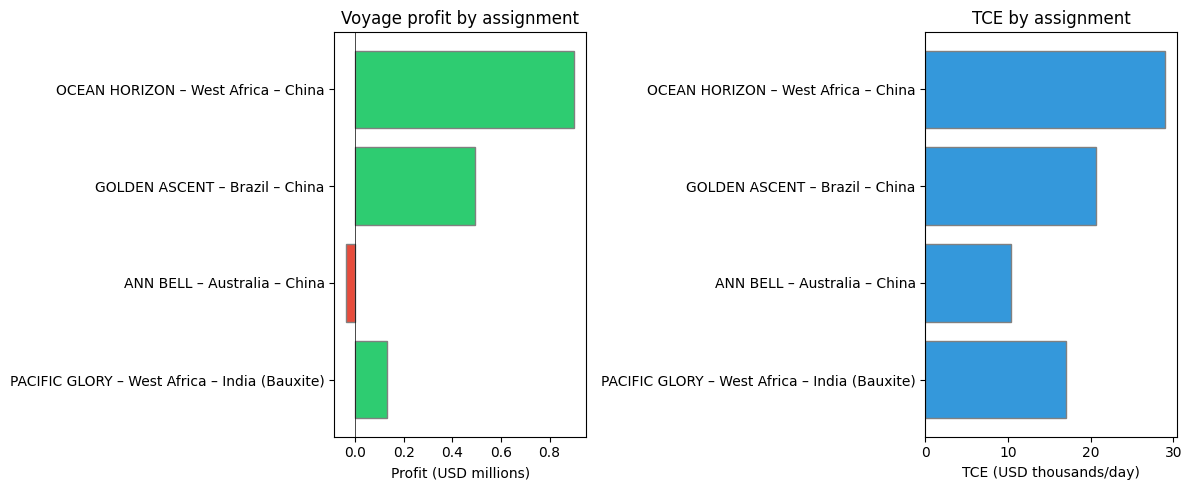

In [49]:
# Viz 1: Voyage-level profit and TCE comparison across optimal vessel-cargo assignments
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Use FC assignments if available, else load from CSV
try:
    assign_viz = assignments if 'assignments' in dir() and hasattr(assignments, '__len__') and len(assignments) > 0 else pd.read_csv(Path("processed/optimal_assignments.csv"))
except Exception:
    assign_viz = pd.read_csv(Path("processed/optimal_assignments.csv"))
assign_viz = assign_viz.copy()
assign_viz["Vessel_Route"] = assign_viz["Vessel"] + " – " + assign_viz["Route"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
colors = ["#2ecc71" if p >= 0 else "#e74c3c" for p in assign_viz["Total_Voyage_Profit_USD"]]
ax1.barh(assign_viz["Vessel_Route"], assign_viz["Total_Voyage_Profit_USD"] / 1e6, color=colors, edgecolor="gray")
ax1.axvline(0, color="black", linewidth=0.5)
ax1.set_xlabel("Profit (USD millions)")
ax1.set_title("Voyage profit by assignment")
ax1.invert_yaxis()

ax2.barh(assign_viz["Vessel_Route"], assign_viz["TCE_USD_per_day"] / 1000, color="#3498db", edgecolor="gray")
ax2.set_xlabel("TCE (USD thousands/day)")
ax2.set_title("TCE by assignment")
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

Observe: profit and TCE by vessel–route. Green bars indicate profitable voyages; red indicates losses.

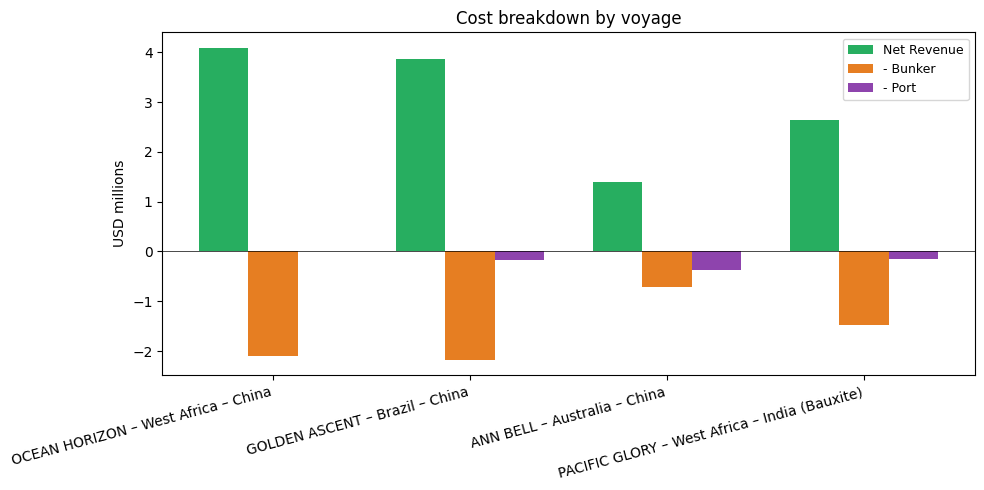

In [50]:
# Viz 2: Cost breakdown – freight revenue vs bunker, port
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(assign_viz))
w = 0.25
revenue = assign_viz["Net_Revenue_USD"] / 1e6
bunker = -assign_viz["Bunker_Cost_USD"] / 1e6
port = -assign_viz["Port_Cost_USD"] / 1e6
ax.bar([i - w for i in x], revenue, w, label="Net Revenue", color="#27ae60")
ax.bar([i for i in x], bunker, w, label="- Bunker", color="#e67e22")
ax.bar([i + w for i in x], port, w, label="- Port", color="#8e44ad")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(assign_viz["Vessel_Route"], rotation=15, ha="right")
ax.set_ylabel("USD millions")
ax.set_title("Cost breakdown by voyage")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

Observe: net revenue vs bunker and port costs. Bunker dominates for long-haul routes.

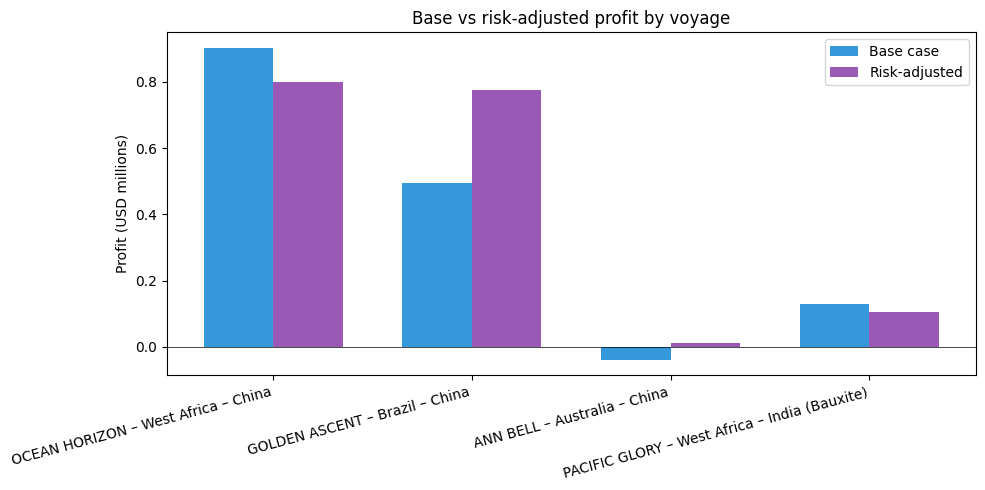

In [51]:
# Viz 3: Risk-adjusted vs base-case profit (before vs after ML risk simulation)
has_risk = "Risk_Adjusted_Profit_USD" in assign_viz.columns and assign_viz["Risk_Adjusted_Profit_USD"].notna().any()
if has_risk:
    fig, ax = plt.subplots(figsize=(10, 5))
    x = range(len(assign_viz))
    w = 0.35
    base = assign_viz["Total_Voyage_Profit_USD"] / 1e6
    risk = assign_viz["Risk_Adjusted_Profit_USD"] / 1e6
    ax.bar([i - w/2 for i in x], base, w, label="Base case", color="#3498db")
    ax.bar([i + w/2 for i in x], risk, w, label="Risk-adjusted", color="#9b59b6")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(assign_viz["Vessel_Route"], rotation=15, ha="right")
    ax.set_ylabel("Profit (USD millions)")
    ax.set_title("Base vs risk-adjusted profit by voyage")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Risk-adjusted metrics not available (run with ML risk enabled).")

Observe: risk-adjusted profit reflects weather, congestion, and delay impacts. Differences highlight voyage sensitivity.

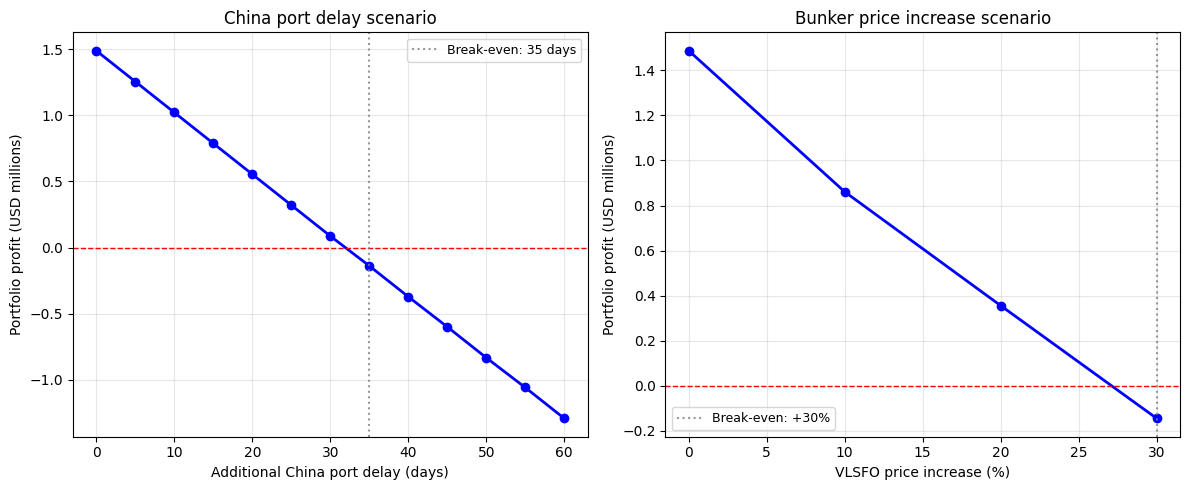

In [52]:
# Viz 4: Scenario analysis – threshold points where optimal decisions change
try:
    d_df = delay_df if 'delay_df' in dir() and len(delay_df) > 0 else pd.read_csv(Path("processed/scenario_china_delay.csv"))
    b_df = bunker_df if 'bunker_df' in dir() and len(bunker_df) > 0 else pd.read_csv(Path("processed/scenario_bunker_increase.csv"))
except Exception:
    d_df = pd.read_csv(Path("processed/scenario_china_delay.csv"))
    b_df = pd.read_csv(Path("processed/scenario_bunker_increase.csv"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(d_df["China_Delay_Days"], d_df["Total_Portfolio_Profit"] / 1e6, "b-o", linewidth=2, markersize=6)
ax1.axhline(0, color="red", linestyle="--", linewidth=1)
neg = d_df[d_df["Total_Portfolio_Profit"] < 0]
thresh_d = neg.iloc[0]["China_Delay_Days"] if len(neg) > 0 else None
if thresh_d is not None:
    ax1.axvline(thresh_d, color="gray", linestyle=":", alpha=0.8, label=f"Break-even: {int(thresh_d)} days")
ax1.set_xlabel("Additional China port delay (days)")
ax1.set_ylabel("Portfolio profit (USD millions)")
ax1.set_title("China port delay scenario")
ax1.legend(loc="best", fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.plot(b_df["Bunker_Increase_Pct"], b_df["Total_Portfolio_Profit"] / 1e6, "b-o", linewidth=2, markersize=6)
ax2.axhline(0, color="red", linestyle="--", linewidth=1)
neg_b = b_df[b_df["Total_Portfolio_Profit"] < 0]
thresh_b = neg_b.iloc[0]["Bunker_Increase_Pct"] if len(neg_b) > 0 else None
if thresh_b is not None:
    ax2.axvline(thresh_b, color="gray", linestyle=":", alpha=0.8, label=f"Break-even: +{int(thresh_b)}%")
ax2.set_xlabel("VLSFO price increase (%)")
ax2.set_ylabel("Portfolio profit (USD millions)")
ax2.set_title("Bunker price increase scenario")
ax2.legend(loc="best", fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Observe: break-even thresholds where portfolio profit turns negative. Red line = zero; vertical line = threshold.

In [53]:
# Viz 5: Geographical voyage paths – load to discharge with direction
try:
    import folium
    HAS_FOLIUM = True
except ImportError:
    HAS_FOLIUM = False

# Build port coordinates from cargo_requirements (matches Load_Port/Discharge_Port format)
cr = pd.read_csv(Path("processed/cargo_requirements.csv"))
port_coords = {}
for _, r in cr.iterrows():
    for role, lat_col, lon_col in [("Load", "Load_Port_Latitude", "Load_Port_Longitude"), ("Discharge", "Discharge_Port_Latitude", "Discharge_Port_Longitude")]:
        port_col = "Load_Port" if role == "Load" else "Discharge_Port"
        if port_col in cr.columns and lat_col in cr.columns and pd.notna(r.get(lat_col)):
            port_coords[str(r[port_col]).strip()] = (float(r[lat_col]), float(r[lon_col]))

# Fallback: port_locations (normalize names for matching)
pl = pd.read_csv(Path("data/port_locations.csv"))
for _, r in pl.iterrows():
    name = str(r["port_name"]).strip()
    port_coords[name] = (float(r["latitude"]), float(r["longitude"]))
    port_coords[name.upper().replace(" ", "_")] = (float(r["latitude"]), float(r["longitude"]))

def get_coords(port):
    if not port or pd.isna(port): return None
    s = str(port).strip()
    if s in port_coords: return port_coords[s]
    base = s.replace("_", " ").upper().split("_")[0]
    for k, v in port_coords.items():
        if base in k.replace("_", " ") or k.replace("_", " ").startswith(base): return v
    return None

if HAS_FOLIUM:
    m = folium.Map(location=[20, 60], zoom_start=2, tiles="CartoDB positron")
    colors = ["#e74c3c", "#3498db", "#2ecc71", "#9b59b6"]
    for idx, row in assign_viz.iterrows():
        load, disc = row["Load_Port"], row["Discharge_Port"]
        c1, c2 = get_coords(load), get_coords(disc)
        if c1 and c2:
            folium.Marker(c1, popup=f"Load: {load}", icon=folium.Icon(color="green")).add_to(m)
            folium.Marker(c2, popup=f"Discharge: {disc}", icon=folium.Icon(color="red")).add_to(m)
            folium.PolyLine([c1, c2], color=colors[idx % len(colors)], weight=3, opacity=0.7,
                           popup=f"{row['Vessel']}: {row['Route']}").add_to(m)
    m.save(str(OUTPUTS_MAPS / "voyage_paths_report.html"))
    display(m)
else:
    # Fallback: matplotlib scatter + lines
    fig, ax = plt.subplots(figsize=(12, 6))
    for idx, row in assign_viz.iterrows():
        c1, c2 = get_coords(row["Load_Port"]), get_coords(row["Discharge_Port"])
        if c1 and c2:
            ax.plot([c1[1], c2[1]], [c1[0], c2[0]], "o-", label=f"{row['Vessel']}: {row['Route']}")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); ax.set_title("Voyage paths")
    ax.legend(bbox_to_anchor=(1.05, 1)); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

Observe: green = load port, red = discharge port. Lines show voyage paths; colours distinguish routes.

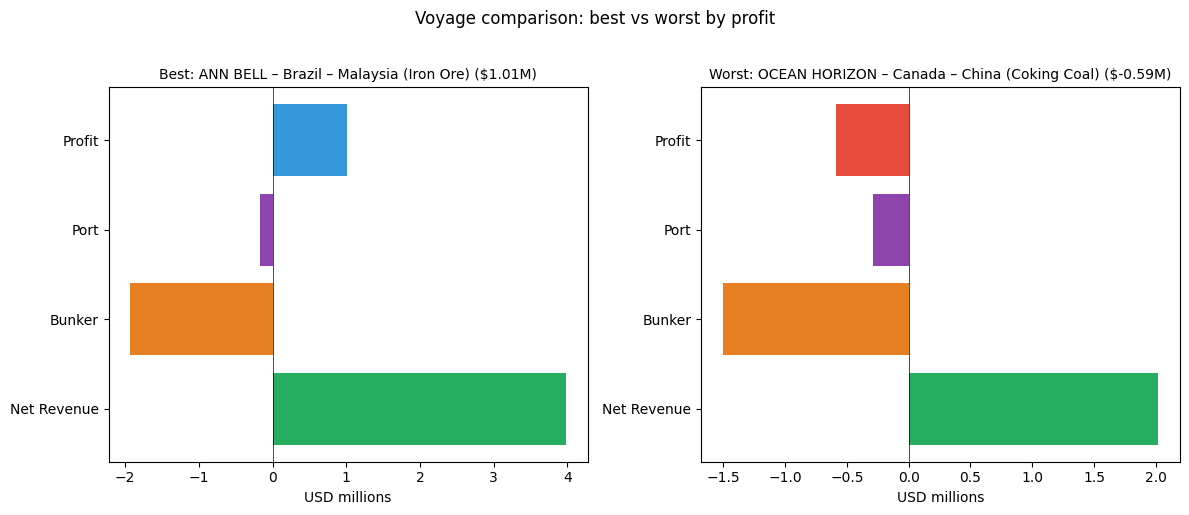

In [54]:
# Viz 6: Side-by-side voyage comparison – two vessels/routes for visual diff
# Compare: (1) highest-profit vs (2) lowest-profit voyage, or two vessels on same cargo
try:
    all_v = all_combos if 'all_combos' in dir() and len(all_combos) > 0 else pd.read_csv(Path("processed/all_voyage_combinations.csv"))
except Exception:
    all_v = pd.read_csv(Path("processed/all_voyage_combinations.csv"))

# Pick two contrasting voyages: best and worst by profit
all_v = all_v.dropna(subset=["Total_Voyage_Profit_USD"])
best = all_v.nlargest(1, "Total_Voyage_Profit_USD").iloc[0]
worst = all_v.nsmallest(1, "Total_Voyage_Profit_USD").iloc[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for ax, row, title in [(ax1, best, f"Best: {best['Vessel']} – {best['Route']} (${best['Total_Voyage_Profit_USD']/1e6:.2f}M)"), (ax2, worst, f"Worst: {worst['Vessel']} – {worst['Route']} (${worst['Total_Voyage_Profit_USD']/1e6:.2f}M)")]:
    comp = ["Net_Revenue_USD", "Bunker_Cost_USD", "Port_Cost_USD", "Total_Voyage_Profit_USD"]
    labs = ["Net Revenue", "Bunker", "Port", "Profit"]
    vals = [row[c]/1e6 for c in comp[:3]] + [row[comp[3]]/1e6]
    vals[1], vals[2] = -vals[1], -vals[2]
    cols = ["#27ae60", "#e67e22", "#8e44ad", "#3498db" if vals[3] >= 0 else "#e74c3c"]
    ax.barh(labs, vals, color=cols)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_xlabel("USD millions")
    ax.set_title(title, fontsize=10)
plt.suptitle("Voyage comparison: best vs worst by profit", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Observe: best vs worst voyage. Cost structure differences (bunker, port) drive profit divergence.

In [55]:
# Viz 7: Geo comparison – two voyages overlaid (best vs worst)
if HAS_FOLIUM:
    m2 = folium.Map(location=[20, 60], zoom_start=2, tiles="CartoDB positron")
    for row in [best, worst]:
        load, disc = row["Load_Port"], row["Discharge_Port"]
        c1, c2 = get_coords(load), get_coords(disc)
        if c1 and c2:
            col = "#2ecc71" if row["Total_Voyage_Profit_USD"] >= 0 else "#e74c3c"
            folium.Marker(c1, popup=f"Load: {load}", icon=folium.Icon(color="green")).add_to(m2)
            folium.Marker(c2, popup=f"Discharge: {disc}", icon=folium.Icon(color="red")).add_to(m2)
            folium.PolyLine([c1, c2], color=col, weight=4, opacity=0.8,
                           popup=f"{row['Vessel']}: {row['Route']} (${row['Total_Voyage_Profit_USD']/1e6:.1f}M)").add_to(m2)
    m2.save(str(OUTPUTS_MAPS / "voyage_comparison_report.html"))
    display(m2)
else:
    fig, ax = plt.subplots(figsize=(10, 6))
    for row in [best, worst]:
        c1, c2 = get_coords(row["Load_Port"]), get_coords(row["Discharge_Port"])
        if c1 and c2:
            col = "#2ecc71" if row["Total_Voyage_Profit_USD"] >= 0 else "#e74c3c"
            ax.plot([c1[1], c2[1]], [c1[0], c2[0]], "o-", color=col, label=f"{row['Vessel']} (${row['Total_Voyage_Profit_USD']/1e6:.1f}M)")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); ax.set_title("Best vs worst voyage comparison"); ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

Observe: best (green) vs worst (red) voyage paths. Route length and fuel exposure drive profit differences.

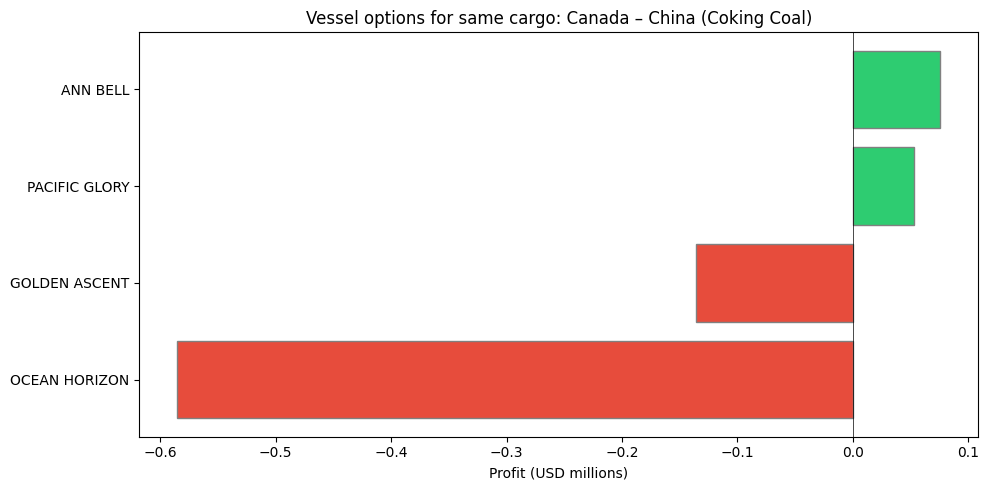

In [56]:
# Viz 8: Same cargo, different vessels – compare vessel options for one route
# Pick a cargo (e.g. West Africa – China) and show all vessel options
route_options = all_v.groupby("Route").agg({"Vessel": "count", "Total_Voyage_Profit_USD": ["max", "min"]}).reset_index()
route_options.columns = ["Route", "N_Vessels", "Max_Profit", "Min_Profit"]
route_options["Spread"] = route_options["Max_Profit"] - route_options["Min_Profit"]
top_route = route_options.nlargest(1, "Spread").iloc[0]["Route"]
same_cargo = all_v[all_v["Route"] == top_route].sort_values("Total_Voyage_Profit_USD", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2ecc71" if p >= 0 else "#e74c3c" for p in same_cargo["Total_Voyage_Profit_USD"]]
ax.barh(same_cargo["Vessel"], same_cargo["Total_Voyage_Profit_USD"] / 1e6, color=colors, edgecolor="gray")
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Profit (USD millions)")
ax.set_title(f"Vessel options for same cargo: {top_route}")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Observe: same cargo route served by multiple vessels. Optimal choice depends on vessel efficiency and position.

Preprocess vessels, cargoes, and build distance lookup. Expect: processed counts per data type.

In [57]:
# Cell 3: Preprocess data (NO PORT NORMALIZATION - using raw CSV values)

# Preprocess vessels
print("Preprocessing vessels...")

# Cargill vessels

#3. Columns NOT used (8 columns)
'''These CSV columns are not referenced in thE CARGILL AND MARKET :
Warranted Speed Laden (kn)
Warranted Speed Ballast (kn)
Warranted Sea Consumption Laden (mt/day)
Warranted Sea Consumption Ballast (mt/day)
Current Position / Status_Latitude
Current Position / Status_Longitude
Bunker Remaining VLSFO (mt) #CAN INCLUDE LATER
Bunker Remaining MGO (mt)'''
cargill_vessels_processed = cargill_vessels.copy()
cargill_vessels_processed['vessel_name'] = cargill_vessels_processed['Vessel Name']
cargill_vessels_processed['deadweight_tonnage_dwt'] = cargill_vessels_processed['DWT (MT)']
cargill_vessels_processed['hire_rate_usd_per_day'] = cargill_vessels_processed['Hire Rate (USD/day)']
cargill_vessels_processed['economical_speed_knots'] = cargill_vessels_processed['Economical Speed Ballast (kn)']
cargill_vessels_processed['sea_consumption_mt_per_day'] = cargill_vessels_processed['Economical Sea Consumption Ballast (mt/day)']
cargill_vessels_processed['port_consumption_mt_per_day'] = cargill_vessels_processed['Port Consumption Working (mt/day)']
cargill_vessels_processed['port_consumption_idle_mt_per_day'] = cargill_vessels_processed['Port Consumption Idle (mt/day)']
cargill_vessels_processed['current_position_port'] = cargill_vessels_processed['Current Position / Status']
cargill_vessels_processed['estimated_time_of_departure'] = pd.to_datetime(cargill_vessels_processed['ETD'])
cargill_vessels_processed['speed_laden'] = cargill_vessels_processed['Economical Speed Laden (kn)']
cargill_vessels_processed['consumption_laden'] = cargill_vessels_processed['Economical Sea Consumption Laden (mt/day)']

# Market vessels
market_vessels_processed = market_vessels.copy()
market_vessels_processed['vessel_name'] = market_vessels_processed['Vessel Name']
market_vessels_processed['deadweight_tonnage_dwt'] = market_vessels_processed['DWT (MT)']
# Market vessel hire rate: use FFA 5TC rate (cost of chartering a market vessel)
# Look up the 5TC rate for each vessel's ETD month
def get_5tc_hire_rate(etd_date):
    """Get FFA 5TC hire rate for a given date from freight_rates.csv."""
    tc5_row = freight_rates[freight_rates['route'].str.contains('5TC')]
    if len(tc5_row) == 0:
        return 18454  # Fallback: Mar-26 5TC rate
    tc5_row = tc5_row.iloc[0]
    
    if isinstance(etd_date, str):
        etd_date = pd.to_datetime(etd_date)
    
    # Try monthly column first (e.g., "2026-03")
    month_key = f"{etd_date.year}-{etd_date.month:02d}"
    if month_key in tc5_row.index and pd.notna(tc5_row[month_key]):
        return float(tc5_row[month_key])
    
    # Try quarterly column (e.g., "2026-Q1")
    quarter = (etd_date.month - 1) // 3 + 1
    q_key = f"{etd_date.year}-Q{quarter}"
    if q_key in tc5_row.index and pd.notna(tc5_row[q_key]):
        return float(tc5_row[q_key])
    
    # Fallback to annual
    year_key = str(etd_date.year)
    if year_key in tc5_row.index and pd.notna(tc5_row[year_key]):
        return float(tc5_row[year_key])
    
    return 18454  # Ultimate fallback

market_vessels_processed['hire_rate_usd_per_day'] = market_vessels_processed['ETD'].apply(
    lambda etd: get_5tc_hire_rate(pd.to_datetime(etd))
)
print("Market vessel hire rates (FFA 5TC):")
for _, v in market_vessels_processed.iterrows():
    print(f"  {v['vessel_name']}: ${v['hire_rate_usd_per_day']:,.0f}/day (ETD: {pd.to_datetime(v['ETD']).date()})")
market_vessels_processed['economical_speed_knots'] = market_vessels_processed['Economical Speed Ballast (kn)']
market_vessels_processed['sea_consumption_mt_per_day'] = market_vessels_processed['Economical Sea Consumption Ballast (mt/day)']
market_vessels_processed['port_consumption_mt_per_day'] = market_vessels_processed['Port Consumption Working (mt/day)']
market_vessels_processed['port_consumption_idle_mt_per_day'] = market_vessels_processed['Port Consumption Idle (mt/day)']
market_vessels_processed['current_position_port'] = market_vessels_processed['Current Position / Status']
market_vessels_processed['estimated_time_of_departure'] = pd.to_datetime(market_vessels_processed['ETD'])
market_vessels_processed['speed_laden'] = market_vessels_processed['Economical Speed Laden (kn)']
market_vessels_processed['consumption_laden'] = market_vessels_processed['Economical Sea Consumption Laden (mt/day)']

# Preprocess cargoes
print("Preprocessing cargoes...")

# Cargill cargoes
'''Columns NOT used in this block (13 columns)
These are present in the CSV but not referenced in lines 49–61:
Customer
Commodity
Quantity_Tolerance
Load_Port_Latitude
Load_Port_Longitude
Load_Port_Notes
Load_Parcel_Size_MT
Discharge_Port_Latitude
Discharge_Port_Longitude
Discharge_Port_Alternatives
Discharge_Parcel_Size_MT
Port_Cost_Notes
Commission_Notes'''
cargill_cargoes_processed = cargill_cargoes.copy()
cargill_cargoes_processed['cargo_id'] = ['CARGILL_' + str(i+1) for i in range(len(cargill_cargoes_processed))]
cargill_cargoes_processed['quantity_mt'] = cargill_cargoes_processed['Quantity_MT']
cargill_cargoes_processed['freight_rate_usd_per_mt'] = cargill_cargoes_processed['Freight_Rate_USD_PMT']
cargill_cargoes_processed['commission_percent'] = cargill_cargoes_processed['Commission_Percent'] / 100.0
cargill_cargoes_processed['laycan_start_date'] = pd.to_datetime(cargill_cargoes_processed['Laycan_Start'])
cargill_cargoes_processed['laycan_end_date'] = pd.to_datetime(cargill_cargoes_processed['Laycan_End'])
cargill_cargoes_processed['load_port'] = cargill_cargoes_processed['Load_Port_Primary']
cargill_cargoes_processed['discharge_port'] = cargill_cargoes_processed['Discharge_Port_Primary']
cargill_cargoes_processed['port_costs_usd'] = cargill_cargoes_processed['Port_Cost_USD'].fillna(0)
cargill_cargoes_processed['load_turn_time_hours'] = cargill_cargoes_processed['Load_Turn_Time_Hours'].fillna(12)
cargill_cargoes_processed['discharge_turn_time_hours'] = cargill_cargoes_processed['Discharge_Turn_Time_Hours'].fillna(24)
cargill_cargoes_processed['route'] = cargill_cargoes_processed['Route']

# Market cargoes

#SAME AS CARGILL ONLY YTHAT PORT COST IS SEPERATED TO LOAD COST AND DISCHARGE COST 

market_cargoes_processed = market_cargoes.copy()
market_cargoes_processed['cargo_id'] = ['MARKET_' + str(i+1) for i in range(len(market_cargoes_processed))]
market_cargoes_processed['quantity_mt'] = market_cargoes_processed['Quantity_MT']
market_cargoes_processed['freight_rate_usd_per_mt'] = market_cargoes_processed['Freight_Rate_USD_PMT']
market_cargoes_processed['commission_percent'] = market_cargoes_processed['Commission_Percent'] / 100.0
market_cargoes_processed['laycan_start_date'] = pd.to_datetime(market_cargoes_processed['Laycan_Start'])
market_cargoes_processed['laycan_end_date'] = pd.to_datetime(market_cargoes_processed['Laycan_End'])
market_cargoes_processed['load_port'] = market_cargoes_processed['Load_Port']
market_cargoes_processed['discharge_port'] = market_cargoes_processed['Discharge_Port']
market_cargoes_processed['port_costs_usd'] = (
    market_cargoes_processed['Port_Cost_Load_USD'].fillna(0) + 
    market_cargoes_processed['Port_Cost_Discharge_USD'].fillna(0)
)
market_cargoes_processed['load_turn_time_hours'] = market_cargoes_processed['Load_Turn_Time_hr'].fillna(12)
market_cargoes_processed['discharge_turn_time_hours'] = market_cargoes_processed['Discharge_Turn_Time_hr'].fillna(24)
market_cargoes_processed['route'] = market_cargoes_processed['Route']

# Build distance lookup from Port Distances.csv using raw port names
print("Building distance lookup from Port Distances.csv...")
port_distances_processed = port_distances.copy()
port_distances_processed['port_from'] = port_distances_processed['PORT_NAME_FROM'].str.strip()
port_distances_processed['port_to'] = port_distances_processed['PORT_NAME_TO'].str.strip()
port_distances_processed['distance_nautical_miles'] = port_distances_processed['DISTANCE']

distance_lookup = {}
for _, row in port_distances_processed.iterrows():
    port_from = row['port_from']
    port_to = row['port_to']
    distance = row['distance_nautical_miles']
    key = (port_from, port_to)
    distance_lookup[key] = distance
    key_reverse = (port_to, port_from)
    if key_reverse not in distance_lookup:
        distance_lookup[key_reverse] = distance

print("\n✓ Data preprocessing complete!")
print(f"Processed {len(cargill_vessels_processed)} Cargill vessels")
print(f"Processed {len(market_vessels_processed)} market vessels")
print(f"Processed {len(cargill_cargoes_processed)} Cargill cargoes")
print(f"Processed {len(market_cargoes_processed)} market cargoes")
print(f"Distance lookup entries: {len(distance_lookup)}")


Preprocessing vessels...
Market vessel hire rates (FFA 5TC):
  ATLANTIC FORTUNE: $18,454/day (ETD: 2026-03-02)
  PACIFIC VANGUARD: $14,157/day (ETD: 2026-02-26)
  CORAL EMPEROR: $18,454/day (ETD: 2026-03-05)
  EVEREST OCEAN: $18,454/day (ETD: 2026-03-03)
  POLARIS SPIRIT: $14,157/day (ETD: 2026-02-28)
  IRON CENTURY: $18,454/day (ETD: 2026-03-09)
  MOUNTAIN TRADER: $18,454/day (ETD: 2026-03-06)
  NAVIS PRIDE: $14,157/day (ETD: 2026-02-27)
  AURORA SKY: $18,454/day (ETD: 2026-03-04)
  ZENITH GLORY: $18,454/day (ETD: 2026-03-07)
  TITAN LEGACY: $18,454/day (ETD: 2026-03-01)
Preprocessing cargoes...
Building distance lookup from Port Distances.csv...

✓ Data preprocessing complete!
Processed 4 Cargill vessels
Processed 11 market vessels
Processed 3 Cargill cargoes
Processed 8 market cargoes
Distance lookup entries: 30896


In [58]:
# Cell 4: Build bunker price lookup function (same as original notebook)

# Reshape bunker forward curve from wide to long format
bunker_long = []
date_cols = [col for col in bunker_forward_curve.columns if re.match(r'^\d{4}-\d{2}-\d{2}$', col)]

for _, row in bunker_forward_curve.iterrows():
    location = row['location']
    fuel_grade = row['fuel_grade']
    lat = row['latitude']
    lon = row['longitude']
    for date_col in date_cols:
        price = row[date_col]
        if pd.notna(price):
            date = pd.to_datetime(date_col)
            bunker_long.append({
                'location': location,
                'fuel_grade': fuel_grade,
                'latitude': lat,
                'longitude': lon,
                'date': date,
                'price': price
            })

bunker_df = pd.DataFrame(bunker_long)
bunker_df = bunker_df.sort_values(['location', 'fuel_grade', 'date'])

# Create location mapping from port names to bunker locations
port_to_bunker_location = {}
for _, port_row in port_locations.iterrows():
    port_name = str(port_row['port_name']).strip()
    port_lat = port_row['latitude']
    port_lon = port_row['longitude']
    
    min_dist = float('inf')
    nearest_location = None
    for _, bunker_row in bunker_forward_curve.iterrows():
        bunker_lat = bunker_row['latitude']
        bunker_lon = bunker_row['longitude']
        dist = ((port_lat - bunker_lat)**2 + (port_lon - bunker_lon)**2)**0.5
        if dist < min_dist:
            min_dist = dist
            nearest_location = bunker_row['location']
    
    port_to_bunker_location[port_name] = nearest_location

def get_bunker_price(port_name, fuel_grade='VLSFO', date=None):
    """Get bunker price for a port and date."""
    if date is None:
        return None
    
    if isinstance(date, datetime):
        date = date.date()
    elif isinstance(date, pd.Timestamp):
        date = date.date()
    
    port_clean = str(port_name).strip() if port_name else None
    if not port_clean:
        return None
    
    bunker_location = None
    if port_clean in port_to_bunker_location:
        bunker_location = port_to_bunker_location[port_clean]
    
    if not bunker_location:
        matching = bunker_df[(bunker_df['fuel_grade'] == fuel_grade) & (bunker_df['date'] == pd.Timestamp(date))]
        if len(matching) > 0:
            return matching['price'].mean()
        return None
    
    location_prices = bunker_df[(bunker_df['location'] == bunker_location) & 
                                 (bunker_df['fuel_grade'] == fuel_grade)].copy()
    
    if len(location_prices) == 0:
        if fuel_grade == 'MGO':
            location_prices = bunker_df[(bunker_df['location'] == bunker_location) & 
                                         (bunker_df['fuel_grade'] == 'VLSFO')].copy()
        if len(location_prices) == 0:
            return None
    
    location_prices = location_prices.sort_values('date')
    target_date = pd.Timestamp(date)
    
    exact = location_prices[location_prices['date'] == target_date]
    if len(exact) > 0:
        return exact.iloc[0]['price']
    
    if target_date < location_prices['date'].min():
        return location_prices.iloc[0]['price']
    
    if target_date > location_prices['date'].max():
        return location_prices.iloc[-1]['price']
    
    before = location_prices[location_prices['date'] < target_date].iloc[-1]
    after = location_prices[location_prices['date'] > target_date].iloc[0]
    
    days_between = (after['date'] - before['date']).days
    days_to_target = (target_date - before['date']).days
    
    if days_between == 0:
        return before['price']
    
    weight = days_to_target / days_between
    interpolated_price = before['price'] * (1 - weight) + after['price'] * weight
    
    return interpolated_price

print("✓ Bunker price lookup function ready")

✓ Bunker price lookup function ready


In [59]:
# Cell 5: Build freight rate lookup function (same as original notebook)

# Reshape freight rates from wide to long format
freight_long = []
period_cols = [col for col in freight_rates.columns if col != 'route']

for _, row in freight_rates.iterrows():
    route = row['route']
    for period_col in period_cols:
        rate = row[period_col]
        if pd.notna(rate) and rate != '':
            freight_long.append({
                'route': route,
                'period': period_col,
                'rate': rate
            })

freight_rates_long = pd.DataFrame(freight_long)

def match_route_to_freight_rate(cargo_route):
    """Match a cargo route to a freight rate route."""
    if pd.isna(cargo_route):
        return None
    
    route_str = str(cargo_route).strip()
    
    route_mapping = {
        'Brazil – China': 'C3 (Tubarao-Qingdao)',
        'Brazil – China (Iron Ore)': 'C3 (Tubarao-Qingdao)',
        'Australia – China': 'C5 (West Australia-Qingdao)',
        'Australia – China (Iron Ore)': 'C5 (West Australia-Qingdao)',
        'West Africa – China': None,
        'West Africa – India': None,
        'South Africa – China': None,
        'Indonesia – India': None,
        'Canada – China': None,
        'Australia – South Korea': None,
        'Brazil – Malaysia': None,
    }
    
    if route_str in route_mapping:
        return route_mapping[route_str]
    
    route_upper = route_str.upper()
    for freight_route in freight_rates['route'].unique():
        freight_route_clean = str(freight_route).strip().upper()
        if 'BRAZIL' in route_upper and 'CHINA' in route_upper and 'C3' in freight_route_clean:
            return freight_route
        if 'AUSTRALIA' in route_upper and 'CHINA' in route_upper and 'C5' in freight_route_clean:
            return freight_route
    
    return None

def get_market_freight_rate(cargo_route, laycan_date):
    """Get market freight rate for a cargo route and laycan period."""
    matched_route = match_route_to_freight_rate(cargo_route)
    if not matched_route:
        return None
    
    if isinstance(laycan_date, datetime):
        laycan_date = laycan_date.date()
    elif isinstance(laycan_date, pd.Timestamp):
        laycan_date = laycan_date.date()
    
    year = laycan_date.year
    month = laycan_date.month
    quarter = (month - 1) // 3 + 1
    
    period_candidates = [
        f"{year}-{month:02d}",
        f"{year}-Q{quarter}",
        str(year),
    ]
    
    for period in period_candidates:
        matching = freight_rates_long[
            (freight_rates_long['route'] == matched_route) & 
            (freight_rates_long['period'] == period)
        ]
        if len(matching) > 0:
            return matching.iloc[0]['rate']
    
    route_rates = freight_rates_long[freight_rates_long['route'] == matched_route]
    if len(route_rates) > 0:
        return route_rates['rate'].iloc[0]
    
    return None

# Market cargo freight rates are now read directly from CSV (Freight_Rate_USD_PMT column)
# No conversion needed - rates are already in USD/MT format
# The freight rate lookup functions above are kept for potential opportunity cost calculations

print("✓ Freight rate lookup function ready")
print("  Note: Market cargo freight rates are read directly from CSV (Freight_Rate_USD_PMT column)")

✓ Freight rate lookup function ready
  Note: Market cargo freight rates are read directly from CSV (Freight_Rate_USD_PMT column)


Initialize ML risk simulator (weather, congestion, voyage uncertainty). Risk-adjusted metrics will be applied to leg evaluations.

In [60]:
# Cell 6.5: Initialize ML Risk Simulation Module
# This runs BEFORE optimization to simulate operational risks and adjust profit calculations

import sys
from pathlib import Path

# Add current directory to path
sys.path.insert(0, str(Path.cwd()))

try:
    from ml_risk_simulation import MLRiskSimulator
    print("=" * 80)
    print("ML RISK SIMULATION MODULE - INITIALIZATION")
    print("=" * 80)
    print()
    print("Initializing ML-based risk simulator with evidence-based parameters...")
    print("  - Weather delays: Industry benchmarks (1-3% of voyage time)")
    print("  - Port congestion: Industry statistics (20-30% probability)")
    print("  - Voyage uncertainty: Industry standard (5-10% CV)")
    print("  - Demurrage: Industry rates ($20k-$30k/day, 10-20% occurrence)")
    print()
    
    # Initialize risk simulator with fixed seed for reproducibility
    risk_simulator = MLRiskSimulator(random_seed=42)
    ML_RISK_ENABLED = True
    
    print("✓ ML Risk Simulator initialized")
    print("  Risk simulation will be applied to all leg evaluations BEFORE optimization")
    print("  This ensures optimization uses risk-adjusted profits, not deterministic estimates")
    print()
    
except ImportError as e:
    print(f"⚠ Warning: ML Risk Simulation module not available: {e}")
    print("  Running in deterministic mode (no risk adjustments)")
    ML_RISK_ENABLED = False
    risk_simulator = None


ML RISK SIMULATION MODULE - INITIALIZATION

Initializing ML-based risk simulator with evidence-based parameters...
  - Weather delays: Industry benchmarks (1-3% of voyage time)
  - Port congestion: Industry statistics (20-30% probability)
  - Voyage uncertainty: Industry standard (5-10% CV)
  - Demurrage: Industry rates ($20k-$30k/day, 10-20% occurrence)

✓ ML Risk Simulator initialized
  Risk simulation will be applied to all leg evaluations BEFORE optimization
  This ensures optimization uses risk-adjusted profits, not deterministic estimates



In [61]:
# Cell 6: Implement generalized leg evaluator (with waiting logic)

def get_distance(port_from, port_to, distance_lookup):
    """Get distance between two ports using raw port names."""
    if not port_from or not port_to:
        return None
    
    port_from_clean = str(port_from).strip()
    port_to_clean = str(port_to).strip()
    
    distance = distance_lookup.get((port_from_clean, port_to_clean))
    if distance is not None:
        return distance
    
    distance = distance_lookup.get((port_to_clean, port_from_clean))
    if distance is not None:
        return distance
    
    return None

def evaluate_leg(start_port, start_time, vessel_row, cargo_row, distance_lookup, get_bunker_price_fn, get_market_freight_rate_fn):
    """
    Evaluate a single leg: vessel goes from start_port at start_time to execute cargo.
    
    Args:
        start_port: Port name where vessel starts (raw string)
        start_time: datetime when vessel departs start_port
        vessel_row: Vessel dataframe row
        cargo_row: Cargo dataframe row
        distance_lookup: Dictionary of port-to-port distances
        get_bunker_price_fn: Function to get bunker price
        get_market_freight_rate_fn: Function to get market freight rate
    
    Returns:
        dict with leg details and profit, or None if infeasible
    """
    try:
        # 1. Capacity check
        if cargo_row['quantity_mt'] > vessel_row['deadweight_tonnage_dwt']:
            return None
        
        # 2. Distance lookups
        ballast_port_from = start_port
        ballast_port_to = cargo_row['load_port']
        laden_port_from = cargo_row['load_port']
        laden_port_to = cargo_row['discharge_port']
        
        if not ballast_port_from or not ballast_port_to or not laden_port_to:
            return None
        
        ballast_distance = get_distance(ballast_port_from, ballast_port_to, distance_lookup)
        laden_distance = get_distance(laden_port_from, laden_port_to, distance_lookup)
        
        if ballast_distance is None or laden_distance is None:
            return None
        
        # 3. Time calculations
        # Ballast leg
        ballast_speed = vessel_row['economical_speed_knots']
        days_ballast = ballast_distance / (ballast_speed * 24.0)
        
        # Arrival at load port
        if isinstance(start_time, str):
            start_time = pd.to_datetime(start_time)
        elif isinstance(start_time, pd.Timestamp):
            start_time = start_time.to_pydatetime()
        
        arrival_at_load = start_time + timedelta(days=days_ballast)
        
        # 4. Waiting logic (if arriving before laycan start)
        laycan_start = cargo_row['laycan_start_date']
        if isinstance(laycan_start, pd.Timestamp):
            laycan_start = laycan_start.to_pydatetime()
        
        laycan_end = cargo_row['laycan_end_date']
        if isinstance(laycan_end, pd.Timestamp):
            laycan_end = laycan_end.to_pydatetime()
        
        waiting_days = 0.0
        actual_load_start = arrival_at_load
        
        if arrival_at_load.date() < laycan_start.date():
            # Arrive early - wait until laycan start
            waiting_days = (laycan_start.date() - arrival_at_load.date()).days
            actual_load_start = laycan_start
        elif arrival_at_load.date() > laycan_end.date():
            # Arrive too late - infeasible
            return None
        
        # Laden leg
        laden_speed = vessel_row['speed_laden']
        days_laden = laden_distance / (laden_speed * 24.0)
        
        # Port time
        port_days = (cargo_row['load_turn_time_hours'] + cargo_row['discharge_turn_time_hours']) / 24.0
        
        # Total time
        total_days = days_ballast + waiting_days + port_days + days_laden
        
        # Completion time
        completion_time = actual_load_start + timedelta(days=port_days + days_laden)
        
        # 5. Revenue
        freight_rate = cargo_row['freight_rate_usd_per_mt']
        quantity = cargo_row['quantity_mt']
        revenue = freight_rate * quantity
        
        # 6. Costs
        # Commission
        commission = cargo_row['commission_percent'] * revenue
        
        # Fuel costs (time-varying based on actual dates)
        # Ballast fuel (priced at start_port, start_time)
        fuel_ballast = vessel_row['sea_consumption_mt_per_day'] * days_ballast
        bunker_price_ballast = get_bunker_price_fn(ballast_port_from, 'VLSFO', start_time.date())
        if bunker_price_ballast is None:
            bunker_price_ballast = 500  # Default fallback
        
        # Waiting fuel (idle consumption at load port, priced at load port, arrival date)
        fuel_waiting = vessel_row['port_consumption_idle_mt_per_day'] * waiting_days
        bunker_price_waiting = get_bunker_price_fn(ballast_port_to, 'VLSFO', arrival_at_load.date())
        if bunker_price_waiting is None:
            bunker_price_waiting = 500
        
        # Laden fuel (priced at load port, departure date)
        fuel_laden = vessel_row['consumption_laden'] * days_laden
        bunker_price_laden = get_bunker_price_fn(laden_port_from, 'VLSFO', actual_load_start.date())
        if bunker_price_laden is None:
            bunker_price_laden = 500
        
        # Port fuel (working consumption during load/discharge)
        fuel_port = vessel_row['port_consumption_mt_per_day'] * port_days
        bunker_price_port = get_bunker_price_fn(laden_port_from, 'VLSFO', actual_load_start.date())
        if bunker_price_port is None:
            bunker_price_port = 500
        
        fuel_cost = (fuel_ballast * bunker_price_ballast + 
                    fuel_waiting * bunker_price_waiting +
                    fuel_laden * bunker_price_laden + 
                    fuel_port * bunker_price_port)
        
        # Hire cost
        hire_cost = vessel_row['hire_rate_usd_per_day'] * total_days
        
        # Port costs
        port_costs = cargo_row['port_costs_usd']
        
        total_costs = commission + fuel_cost + hire_cost + port_costs
        
        # Profit (base deterministic calculation)
        profit = revenue - total_costs
        
        # Opportunity cost (market rate comparison)
        market_rate = get_market_freight_rate_fn(cargo_row.get('route'), cargo_row['laycan_start_date'])
        opportunity_cost = None
        if market_rate is not None:
            market_revenue = market_rate * quantity
            opportunity_cost = market_revenue - revenue
        
        # ML RISK SIMULATION: Apply risk adjustments BEFORE optimization
        # This ensures optimization uses risk-adjusted profits, not deterministic estimates
        risk_adjusted_profit = profit
        risk_profile = None
        risk_adjustment_data = None
        
        if ML_RISK_ENABLED and risk_simulator is not None:
            try:
                # Determine route type for risk simulation
                route_type = 'default'
                if 'BRAZIL' in ballast_port_to.upper() or 'BRAZIL' in laden_port_to.upper():
                    if 'CHINA' in laden_port_to.upper() or 'ASIA' in laden_port_to.upper():
                        route_type = 'transpacific'
                elif 'AUSTRALIA' in ballast_port_to.upper() and 'CHINA' in laden_port_to.upper():
                    route_type = 'asia_australia'
                elif 'AFRICA' in ballast_port_to.upper() or 'KAMSAR' in ballast_port_to.upper():
                    route_type = 'asia_africa'
                elif 'EUROPE' in laden_port_to.upper():
                    route_type = 'asia_europe'
                
                # Calculate base fuel consumption in MT
                base_fuel_mt = (
                    fuel_ballast + fuel_waiting + fuel_laden + fuel_port
                ) / 500.0  # Rough estimate: average bunker price ~$500/MT
                
                # Simulate comprehensive risk
                risk_profile = risk_simulator.simulate_comprehensive_risk(
                    voyage_date=start_time,
                    load_port=ballast_port_to,
                    discharge_port=laden_port_to,
                    base_duration_days=total_days,
                    base_fuel_mt=base_fuel_mt,
                    ballast_distance_nm=ballast_distance,
                    laden_distance_nm=laden_distance,
                    laycan_start=laycan_start,
                    laycan_end=laycan_end,
                    port_days=port_days,
                    route_type=route_type
                )
                
                # Calculate risk-adjusted profit
                risk_adjustment_data = risk_simulator.calculate_risk_adjusted_profit(
                    base_profit=profit,
                    base_fuel_cost=fuel_cost,
                    base_hire_cost=hire_cost,
                    base_duration_days=total_days,
                    risk_profile=risk_profile,
                    hire_rate_per_day=vessel_row['hire_rate_usd_per_day']
                )
                
                # Use risk-adjusted profit for optimization
                risk_adjusted_profit = risk_adjustment_data['risk_adjusted_profit']
                
            except Exception as e:
                # If risk simulation fails, use base profit
                print(f"Warning: Risk simulation failed for leg {ballast_port_to}->{laden_port_to}: {e}")
                risk_adjusted_profit = profit
        
        # Return result - use risk-adjusted profit if available, otherwise base profit
        result = {
            'profit': risk_adjusted_profit,  # Risk-adjusted profit used for optimization
            'base_profit': profit,  # Store base profit for comparison
            'revenue': revenue,
            'costs': total_costs,
            'commission': commission,
            'fuel_cost': fuel_cost,
            'fuel_cost_ballast': fuel_ballast * bunker_price_ballast,
            'fuel_cost_waiting': fuel_waiting * bunker_price_waiting,
            'fuel_cost_laden': fuel_laden * bunker_price_laden,
            'fuel_cost_port': fuel_port * bunker_price_port,
            'hire_cost': hire_cost,
            'port_costs': port_costs,
            'opportunity_cost': opportunity_cost,
            'market_rate': market_rate,
            'offered_rate': freight_rate,
            'days_ballast': days_ballast,
            'days_waiting': waiting_days,
            'days_laden': days_laden,
            'days_port': port_days,
            'total_days': total_days,
            'ballast_distance': ballast_distance,
            'laden_distance': laden_distance,
            'arrival_at_load': arrival_at_load,
            'actual_load_start': actual_load_start,
            'completion_time': completion_time,
            'end_port': laden_port_to,
            'end_time': completion_time,
            'bunker_price_ballast': bunker_price_ballast,
            'bunker_price_waiting': bunker_price_waiting,
            'bunker_price_laden': bunker_price_laden,
            'bunker_price_port': bunker_price_port
        }
        
        # Add risk data if available
        if risk_profile is not None:
            result['risk_profile'] = risk_profile
        if risk_adjustment_data is not None:
            result['risk_adjusted_fuel_cost'] = risk_adjustment_data['risk_adjusted_fuel_cost']
            result['risk_adjusted_hire_cost'] = risk_adjustment_data['risk_adjusted_hire_cost']
            result['risk_adjusted_duration_days'] = risk_adjustment_data['risk_adjusted_duration_days']
            result['total_risk_cost'] = risk_adjustment_data['total_risk_cost']
            result['risk_impact'] = risk_adjustment_data['risk_impact']
        
        return result
    
    except Exception as e:
        print(f"Error evaluating leg: {e}")
        import traceback
        traceback.print_exc()
        return None

print("✓ Leg evaluator function implemented")

✓ Leg evaluator function implemented


In [62]:
# Cell 7: Generate feasible arcs for multi-leg routing

print("Generating feasible arcs for multi-leg routing...")
print("=" * 80)

# Combine all cargoes for easier indexing
all_cargoes = pd.concat([
    cargill_cargoes_processed.assign(cargo_type='committed', cargo_idx_in_type=range(len(cargill_cargoes_processed))),
    market_cargoes_processed.assign(cargo_type='market', cargo_idx_in_type=range(len(market_cargoes_processed)))
], ignore_index=True).reset_index(drop=True)

# Create cargo index mapping
cargo_to_idx = {}
for idx, cargo in all_cargoes.iterrows():
    cargo_id = cargo['cargo_id']
    cargo_to_idx[cargo_id] = idx

print(f"Total cargoes: {len(all_cargoes)} ({len(cargill_cargoes_processed)} committed, {len(market_cargoes_processed)} market)")

# Generate arcs for Cargill vessels
cargill_arcs = []

for v_idx, vessel in cargill_vessels_processed.iterrows():
    vessel_name = vessel['vessel_name']
    start_port = vessel['current_position_port']
    start_time = vessel['estimated_time_of_departure']
    
    print(f"\nVessel: {vessel_name}")
    print(f"  Start: {start_port} at {start_time.date()}")
    
    # Arcs from Start -> any cargo
    for c_idx, cargo in all_cargoes.iterrows():
        leg_data = evaluate_leg(
            start_port, start_time, vessel, cargo,
            distance_lookup, get_bunker_price, get_market_freight_rate
        )
        
        if leg_data is not None:
            cargill_arcs.append({
                'vessel_idx': v_idx,
                'vessel_name': vessel_name,
                'from_node': 'START',
                'from_port': start_port,
                'from_time': start_time,
                'to_node': cargo['cargo_id'],
                'to_cargo_idx': c_idx,
                'cargo_type': cargo['cargo_type'],
                'leg_data': leg_data,
                'profit': leg_data['profit'],
                'end_port': leg_data['end_port'],
                'end_time': leg_data['end_time']
            })
    
    # Arcs from cargo -> cargo (for chaining)
    # For each cargo that this vessel can reach, check if it can chain to another cargo
    for c1_idx, cargo1 in all_cargoes.iterrows():
        # Check if vessel can reach cargo1 from start
        leg1_data = evaluate_leg(
            start_port, start_time, vessel, cargo1,
            distance_lookup, get_bunker_price, get_market_freight_rate
        )
        
        if leg1_data is not None:
            # Now check if we can chain cargo2 after cargo1
            end_port_c1 = leg1_data['end_port']
            end_time_c1 = leg1_data['end_time']
            
            for c2_idx, cargo2 in all_cargoes.iterrows():
                if c1_idx == c2_idx:
                    continue  # Can't chain to itself
                
                leg2_data = evaluate_leg(
                    end_port_c1, end_time_c1, vessel, cargo2,
                    distance_lookup, get_bunker_price, get_market_freight_rate
                )
                
                if leg2_data is not None:
                    cargill_arcs.append({
                        'vessel_idx': v_idx,
                        'vessel_name': vessel_name,
                        'from_node': cargo1['cargo_id'],
                        'from_port': end_port_c1,
                        'from_time': end_time_c1,
                        'to_node': cargo2['cargo_id'],
                        'to_cargo_idx': c2_idx,
                        'cargo_type': cargo2['cargo_type'],
                        'leg_data': leg2_data,
                        'profit': leg2_data['profit'],
                        'end_port': leg2_data['end_port'],
                        'end_time': leg2_data['end_time']
                    })

print(f"\n✓ Generated {len(cargill_arcs)} feasible arcs for Cargill vessels")

# Generate arcs for Market vessels (only Start -> committed cargoes)
market_arcs = []

for m_idx, vessel in market_vessels_processed.iterrows():
    vessel_name = vessel['vessel_name']
    start_port = vessel['current_position_port']
    start_time = vessel['estimated_time_of_departure']
    
    # Only committed cargoes for market vessels
    for c_idx, cargo in cargill_cargoes_processed.iterrows():
        leg_data = evaluate_leg(
            start_port, start_time, vessel, cargo,
            distance_lookup, get_bunker_price, get_market_freight_rate
        )
        
        if leg_data is not None:
            market_arcs.append({
                'vessel_idx': m_idx,
                'vessel_name': vessel_name,
                'from_node': 'START',
                'from_port': start_port,
                'from_time': start_time,
                'to_node': cargo['cargo_id'],
                'to_cargo_idx': c_idx,
                'cargo_type': 'committed',
                'leg_data': leg_data,
                'profit': leg_data['profit'],
                'end_port': leg_data['end_port'],
                'end_time': leg_data['end_time']
            })

print(f"✓ Generated {len(market_arcs)} feasible arcs for Market vessels")
print(f"\nTotal feasible arcs: {len(cargill_arcs) + len(market_arcs)}")

Generating feasible arcs for multi-leg routing...
Total cargoes: 11 (3 committed, 8 market)

Vessel: ANN BELL
  Start: QINGDAO at 2026-02-25

Vessel: OCEAN HORIZON
  Start: MAP TA PHUT at 2026-03-01

Vessel: PACIFIC GLORY
  Start: GWANGYANG LNG TERMINAL at 2026-03-10

Vessel: GOLDEN ASCENT
  Start: FANGCHENG at 2026-03-08

✓ Generated 20 feasible arcs for Cargill vessels
✓ Generated 10 feasible arcs for Market vessels

Total feasible arcs: 30


CP-SAT model: vessel flow conservation, cargo coverage, objective. Expect: model built confirmation.

In [63]:
# Cell 8: Implement CP-SAT flow model for multi-leg optimization

from ortools.sat.python import cp_model

print("Building CP-SAT flow model...")
print("=" * 80)

model = cp_model.CpModel()

# Create decision variables for Cargill vessel arcs
cargill_arc_vars = {}
for i, arc in enumerate(cargill_arcs):
    var_name = f"cargill_arc_{arc['vessel_idx']}_{arc['from_node']}_{arc['to_node']}"
    cargill_arc_vars[i] = model.NewBoolVar(var_name)

# Create decision variables for Market vessel assignments
market_arc_vars = {}
for i, arc in enumerate(market_arcs):
    var_name = f"market_arc_{arc['vessel_idx']}_{arc['to_node']}"
    market_arc_vars[i] = model.NewBoolVar(var_name)

print(f"Created {len(cargill_arc_vars)} Cargill vessel arc variables")
print(f"Created {len(market_arc_vars)} Market vessel assignment variables")

# Constraint 1: Each committed cargo must be assigned exactly once
print("\nAdding constraint: Each committed cargo assigned exactly once...")
for c_idx, cargo in cargill_cargoes_processed.iterrows():
    cargo_id = cargo['cargo_id']
    
    # Find all arcs that assign this committed cargo
    cargill_arcs_for_cargo = [
        i for i, arc in enumerate(cargill_arcs)
        if arc['to_node'] == cargo_id and arc['cargo_type'] == 'committed'
    ]
    market_arcs_for_cargo = [
        i for i, arc in enumerate(market_arcs)
        if arc['to_node'] == cargo_id
    ]
    
    # Sum of all assignments to this cargo must equal 1
    terms = []
    for arc_idx in cargill_arcs_for_cargo:
        terms.append(cargill_arc_vars[arc_idx])
    for arc_idx in market_arcs_for_cargo:
        terms.append(market_arc_vars[arc_idx])
    
    if len(terms) > 0:
        model.Add(sum(terms) == 1)
    else:
        print(f"  WARNING: Committed cargo {cargo_id} has no feasible assignments!")

# Constraint 2: Market cargoes are optional (at most once, Cargill vessels only)
print("Adding constraint: Market cargoes optional (at most once)...")
market_cargo_ids = set()
for arc in cargill_arcs:
    if arc['cargo_type'] == 'market':
        market_cargo_ids.add(arc['to_node'])

for cargo_id in market_cargo_ids:
    arcs_for_cargo = [
        i for i, arc in enumerate(cargill_arcs)
        if arc['to_node'] == cargo_id and arc['cargo_type'] == 'market'
    ]
    
    if len(arcs_for_cargo) > 0:
        model.Add(sum(cargill_arc_vars[i] for i in arcs_for_cargo) <= 1)

# Constraint 3: Flow conservation for Cargill vessels (allowing end at cargo nodes)
# For each vessel and each cargo node with OUTFLOW: inflow == outflow
# If there is no outflow (vessel ends there), inflow can be 1 and outflow 0
print("Adding constraint: Flow conservation for Cargill vessels...")

# Get all unique cargo nodes (committed + market)
all_cargo_nodes = set()
for arc in cargill_arcs:
    if arc['from_node'] != 'START':
        all_cargo_nodes.add(arc['from_node'])
    all_cargo_nodes.add(arc['to_node'])

# For each Cargill vessel and each cargo node
for v_idx in cargill_vessels_processed.index:
    vessel_name = cargill_vessels_processed.loc[v_idx, 'vessel_name']
    
    for cargo_node in all_cargo_nodes:
        # Inflow: arcs ending at this node for this vessel
        inflow_arcs = [
            i for i, arc in enumerate(cargill_arcs)
            if arc['vessel_idx'] == v_idx and arc['to_node'] == cargo_node
        ]
        
        # Outflow: arcs starting from this node for this vessel
        outflow_arcs = [
            i for i, arc in enumerate(cargill_arcs)
            if arc['vessel_idx'] == v_idx and arc['from_node'] == cargo_node
        ]
        
        # Flow conservation: outflow <= inflow (vessel can stop at any node)
        # - A vessel can only LEAVE a cargo node if it ARRIVED there
        # - A vessel CAN arrive and choose not to continue (end of route)
        if len(outflow_arcs) > 0 and len(inflow_arcs) > 0:
            inflow_sum = sum(cargill_arc_vars[i] for i in inflow_arcs)
            outflow_sum = sum(cargill_arc_vars[i] for i in outflow_arcs)
            model.Add(outflow_sum <= inflow_sum)

# Constraint 4: Each Cargill vessel can start at most once
# (sum of arcs from START for each vessel <= 1)
print("Adding constraint: Each Cargill vessel starts at most once...")
for v_idx in cargill_vessels_processed.index:
    start_arcs = [
        i for i, arc in enumerate(cargill_arcs)
        if arc['vessel_idx'] == v_idx and arc['from_node'] == 'START'
    ]
    
    if len(start_arcs) > 0:
        model.Add(sum(cargill_arc_vars[i] for i in start_arcs) <= 1)

# Constraint 5: Each Market vessel can be assigned at most once
print("Adding constraint: Each Market vessel assigned at most once...")
for m_idx in market_vessels_processed.index:
    vessel_arcs = [
        i for i, arc in enumerate(market_arcs)
        if arc['vessel_idx'] == m_idx
    ]
    
    if len(vessel_arcs) > 0:
        model.Add(sum(market_arc_vars[i] for i in vessel_arcs) <= 1)

# Objective: Maximize total profit
print("\nSetting objective: Maximize total profit...")
objective_terms = []

# Cargill vessel arcs
for i, arc in enumerate(cargill_arcs):
    profit_scaled = int(round(arc['profit'] * 100))  # Scale to integers
    objective_terms.append(cargill_arc_vars[i] * profit_scaled)

# Market vessel arcs
for i, arc in enumerate(market_arcs):
    profit_scaled = int(round(arc['profit'] * 100))
    objective_terms.append(market_arc_vars[i] * profit_scaled)

model.Maximize(sum(objective_terms))

print("✓ CP-SAT model built successfully")
print(f"  Total variables: {len(cargill_arc_vars) + len(market_arc_vars)}")
print(f"  Objective terms: {len(objective_terms)}")


Building CP-SAT flow model...
Created 20 Cargill vessel arc variables
Created 10 Market vessel assignment variables

Adding constraint: Each committed cargo assigned exactly once...
Adding constraint: Market cargoes optional (at most once)...
Adding constraint: Flow conservation for Cargill vessels...
Adding constraint: Each Cargill vessel starts at most once...
Adding constraint: Each Market vessel assigned at most once...

Setting objective: Maximize total profit...
✓ CP-SAT model built successfully
  Total variables: 30
  Objective terms: 30


In [64]:
# Cell 9: Solve the CP-SAT model

print("Solving CP-SAT model...")
print("=" * 80)

solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 300.0  # 5 minutes
solver.parameters.num_search_workers = 4

status = solver.Solve(model)

print(f"\nSolution status: {solver.StatusName(status)}")

if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
    print(f"Objective value: ${solver.ObjectiveValue() / 100:.2f}")
    
    # Extract selected arcs
    selected_cargill_arcs = []
    selected_market_arcs = []
    
    for i, arc in enumerate(cargill_arcs):
        if solver.Value(cargill_arc_vars[i]) == 1:
            selected_cargill_arcs.append(arc)
    
    for i, arc in enumerate(market_arcs):
        if solver.Value(market_arc_vars[i]) == 1:
            selected_market_arcs.append(arc)
    
    print(f"\nSelected {len(selected_cargill_arcs)} Cargill vessel arcs")
    print(f"Selected {len(selected_market_arcs)} Market vessel assignments")
    
    # Verify all committed cargoes are assigned
    assigned_committed = set()
    for arc in selected_cargill_arcs:
        if arc['cargo_type'] == 'committed':
            assigned_committed.add(arc['to_node'])
    for arc in selected_market_arcs:
        assigned_committed.add(arc['to_node'])
    
    print(f"\nCommitted cargoes assigned: {len(assigned_committed)}/{len(cargill_cargoes_processed)}")
    for c_idx, cargo in cargill_cargoes_processed.iterrows():
        if cargo['cargo_id'] in assigned_committed:
            print(f"  ✓ {cargo['cargo_id']}")
        else:
            print(f"  ❌ {cargo['cargo_id']} NOT ASSIGNED!")
    
    # Identify market cargoes taken
    assigned_market = set()
    for arc in selected_cargill_arcs:
        if arc['cargo_type'] == 'market':
            assigned_market.add(arc['to_node'])
    
    print(f"\nMarket cargoes taken: {len(assigned_market)}")
    for cargo_id in assigned_market:
        print(f"  ✓ {cargo_id}")
    
else:
    print("No feasible solution found!")
    selected_cargill_arcs = []
    selected_market_arcs = []

Solving CP-SAT model...

Solution status: OPTIMAL
Objective value: $7380621.72

Selected 4 Cargill vessel arcs
Selected 3 Market vessel assignments

Committed cargoes assigned: 3/3
  ✓ CARGILL_1
  ✓ CARGILL_2
  ✓ CARGILL_3

Market cargoes taken: 4
  ✓ MARKET_8
  ✓ MARKET_5
  ✓ MARKET_4
  ✓ MARKET_1


In [65]:
# Cell 10: Reconstruct vessel sequences and generate detailed reports

if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
    print("Reconstructing vessel sequences...")
    print("=" * 80)
    
    # Reconstruct paths for each Cargill vessel
    vessel_sequences = {}  # vessel_idx -> list of arcs in order
    
    for v_idx in cargill_vessels_processed.index:
        vessel_name = cargill_vessels_processed.loc[v_idx, 'vessel_name']
        vessel_sequences[v_idx] = []
        
        # Find arcs for this vessel
        vessel_arcs = [arc for arc in selected_cargill_arcs if arc['vessel_idx'] == v_idx]
        
        if len(vessel_arcs) == 0:
            continue
        
        # Build sequence by following arcs from START
        # Find starting arc (from START)
        start_arcs = [arc for arc in vessel_arcs if arc['from_node'] == 'START']
        
        if len(start_arcs) > 0:
            # Start with first arc from START
            current_arc = start_arcs[0]
            sequence = [current_arc]
            
            # Follow chain
            while True:
                next_node = current_arc['to_node']
                next_arcs = [arc for arc in vessel_arcs 
                            if arc['from_node'] == next_node and arc not in sequence]
                
                if len(next_arcs) == 0:
                    break
                
                current_arc = next_arcs[0]
                sequence.append(current_arc)
            
            vessel_sequences[v_idx] = sequence
    
    # Build detailed assignment report
    assignments = []
    market_cargo_recommendations = []
    
    # Cargill vessel sequences
    for v_idx, sequence in vessel_sequences.items():
        if len(sequence) == 0:
            continue
        
        vessel_name = cargill_vessels_processed.loc[v_idx, 'vessel_name']
        cumulative_profit = 0
        cumulative_days = 0
        
        for leg_idx, arc in enumerate(sequence):
            leg_data = arc['leg_data']
            cargo_id = arc['to_node']
            cargo_type = arc['cargo_type']
            
            # Get cargo details
            if cargo_type == 'committed':
                cargo = cargill_cargoes_processed[cargill_cargoes_processed['cargo_id'] == cargo_id].iloc[0]
            else:
                cargo = market_cargoes_processed[market_cargoes_processed['cargo_id'] == cargo_id].iloc[0]
            
            cumulative_profit += leg_data['profit']
            cumulative_days += leg_data['total_days']
            
            assignments.append({
                'Vessel_Type': 'Cargill',
                'Vessel_Name': vessel_name,
                'Leg_Number': leg_idx + 1,
                'Cargo_Type': 'Committed' if cargo_type == 'committed' else 'Market',
                'Cargo_ID': cargo_id,
                'Load_Port': cargo['load_port'],
                'Discharge_Port': cargo['discharge_port'],
                'Quantity_MT': cargo['quantity_mt'],
                'Leg_Profit': leg_data['profit'],
                'Cumulative_Profit': cumulative_profit,
                'Leg_Days': leg_data['total_days'],
                'Cumulative_Days': cumulative_days,
                'TCE_Leg': leg_data['profit'] / leg_data['total_days'] if leg_data['total_days'] > 0 else 0,
                'TCE_Cumulative': cumulative_profit / cumulative_days if cumulative_days > 0 else 0,
                'Revenue': leg_data['revenue'],
                'Fuel_Cost': leg_data['fuel_cost'],
                'Fuel_Cost_Ballast': leg_data['fuel_cost_ballast'],
                'Fuel_Cost_Waiting': leg_data['fuel_cost_waiting'],
                'Fuel_Cost_Laden': leg_data['fuel_cost_laden'],
                'Fuel_Cost_Port': leg_data['fuel_cost_port'],
                'Hire_Cost': leg_data['hire_cost'],
                'Port_Costs': leg_data['port_costs'],
                'Commission': leg_data['commission'],
                'Days_Ballast': leg_data['days_ballast'],
                'Days_Waiting': leg_data['days_waiting'],
                'Days_Laden': leg_data['days_laden'],
                'Days_Port': leg_data['days_port'],
                'Ballast_Distance': leg_data['ballast_distance'],
                'Laden_Distance': leg_data['laden_distance'],
                'Start_Time': arc['from_time'],
                'Arrival_Load': leg_data['arrival_at_load'],
                'Actual_Load_Start': leg_data['actual_load_start'],
                'Completion_Time': leg_data['completion_time'],
                'Bunker_Price_Ballast': leg_data['bunker_price_ballast'],
                'Bunker_Price_Waiting': leg_data['bunker_price_waiting'],
                'Bunker_Price_Laden': leg_data['bunker_price_laden'],
                'Bunker_Price_Port': leg_data['bunker_price_port']
            })
            
            # Track market cargoes explicitly
            if cargo_type == 'market':
                market_cargo_recommendations.append({
                    'Vessel_Name': vessel_name,
                    'Leg_Number': leg_idx + 1,
                    'Market_Cargo_ID': cargo_id,
                    'Load_Port': cargo['load_port'],
                    'Discharge_Port': cargo['discharge_port'],
                    'Quantity_MT': cargo['quantity_mt'],
                    'Freight_Rate': cargo['freight_rate_usd_per_mt'],
                    'Leg_Profit': leg_data['profit'],
                    'Leg_TCE': leg_data['profit'] / leg_data['total_days'] if leg_data['total_days'] > 0 else 0,
                    'Incremental_Profit': leg_data['profit'],
                    'Fuel_Cost': leg_data['fuel_cost'],
                    'Hire_Cost': leg_data['hire_cost'],
                    'Total_Days': leg_data['total_days'],
                    'Position_In_Sequence': f"After leg {leg_idx}" if leg_idx > 0 else "First leg",
                    'Previous_Cargo': sequence[leg_idx-1]['to_node'] if leg_idx > 0 else 'START'
                })
    
    # Market vessel assignments
    for arc in selected_market_arcs:
        vessel_name = arc['vessel_name']
        cargo_id = arc['to_node']
        cargo = cargill_cargoes_processed[cargill_cargoes_processed['cargo_id'] == cargo_id].iloc[0]
        leg_data = arc['leg_data']
        
        assignments.append({
            'Vessel_Type': 'Market',
            'Vessel_Name': vessel_name,
            'Leg_Number': 1,
            'Cargo_Type': 'Committed',
            'Cargo_ID': cargo_id,
            'Load_Port': cargo['load_port'],
            'Discharge_Port': cargo['discharge_port'],
            'Quantity_MT': cargo['quantity_mt'],
            'Leg_Profit': leg_data['profit'],
            'Cumulative_Profit': leg_data['profit'],
            'Leg_Days': leg_data['total_days'],
            'Cumulative_Days': leg_data['total_days'],
            'TCE_Leg': leg_data['profit'] / leg_data['total_days'] if leg_data['total_days'] > 0 else 0,
            'TCE_Cumulative': leg_data['profit'] / leg_data['total_days'] if leg_data['total_days'] > 0 else 0,
            'Revenue': leg_data['revenue'],
            'Fuel_Cost': leg_data['fuel_cost'],
            'Fuel_Cost_Ballast': leg_data['fuel_cost_ballast'],
            'Fuel_Cost_Waiting': leg_data['fuel_cost_waiting'],
            'Fuel_Cost_Laden': leg_data['fuel_cost_laden'],
            'Fuel_Cost_Port': leg_data['fuel_cost_port'],
            'Hire_Cost': leg_data['hire_cost'],
            'Port_Costs': leg_data['port_costs'],
            'Commission': leg_data['commission'],
            'Days_Ballast': leg_data['days_ballast'],
            'Days_Waiting': leg_data['days_waiting'],
            'Days_Laden': leg_data['days_laden'],
            'Days_Port': leg_data['days_port'],
            'Ballast_Distance': leg_data['ballast_distance'],
            'Laden_Distance': leg_data['laden_distance'],
            'Start_Time': arc['from_time'],
            'Arrival_Load': leg_data['arrival_at_load'],
            'Actual_Load_Start': leg_data['actual_load_start'],
            'Completion_Time': leg_data['completion_time'],
            'Bunker_Price_Ballast': leg_data['bunker_price_ballast'],
            'Bunker_Price_Waiting': leg_data['bunker_price_waiting'],
            'Bunker_Price_Laden': leg_data['bunker_price_laden'],
            'Bunker_Price_Port': leg_data['bunker_price_port']
        })
    
    assignments_df = pd.DataFrame(assignments)
    market_recos_df = pd.DataFrame(market_cargo_recommendations)
    
    print(f"\n✓ Generated detailed reports")
    print(f"  Total assignments: {len(assignments_df)}")
    print(f"  Market cargo recommendations: {len(market_recos_df)}")
    
else:
    assignments_df = pd.DataFrame()
    market_recos_df = pd.DataFrame()

Reconstructing vessel sequences...

✓ Generated detailed reports
  Total assignments: 7
  Market cargo recommendations: 4


In [66]:
# Cell 11: Display results - Market Cargo Recommendations (EXPLICIT OUTPUT)

if len(market_recos_df) > 0:
    print("=" * 80)
    print("MARKET CARGO RECOMMENDATIONS")
    print("=" * 80)
    print("\nThe following market cargoes should be taken to maximize profit:\n")
    
    for idx, row in market_recos_df.iterrows():
        print(f"{idx+1}. {row['Market_Cargo_ID']}")
        print(f"   Vessel: {row['Vessel_Name']}")
        print(f"   Position: {row['Position_In_Sequence']} (Leg {row['Leg_Number']})")
        if row['Previous_Cargo'] != 'START':
            print(f"   After completing: {row['Previous_Cargo']}")
        print(f"   Route: {row['Load_Port']} → {row['Discharge_Port']}")
        print(f"   Quantity: {row['Quantity_MT']:,.0f} MT")
        print(f"   Freight Rate: ${row['Freight_Rate']:.2f}/MT")
        print(f"   Incremental Profit: ${row['Incremental_Profit']:,.2f}")
        print(f"   Leg TCE: ${row['Leg_TCE']:,.2f}/day")
        print(f"   Fuel Cost: ${row['Fuel_Cost']:,.2f}")
        print(f"   Hire Cost: ${row['Hire_Cost']:,.2f}")
        print(f"   Total Days: {row['Total_Days']:.1f} days")
        print()
    
    print("\n" + "=" * 80)
    print("SUMMARY")
    print("=" * 80)
    print(f"Total market cargoes recommended: {len(market_recos_df)}")
    print(f"Total incremental profit from market cargoes: ${market_recos_df['Incremental_Profit'].sum():,.2f}")
    print(f"Average TCE for market cargoes: ${market_recos_df['Leg_TCE'].mean():,.2f}/day")
    
else:
    print("=" * 80)
    print("MARKET CARGO RECOMMENDATIONS")
    print("=" * 80)
    print("\nNo market cargoes recommended in optimal solution.")
    print("All vessels are optimally assigned to committed cargoes only.")

MARKET CARGO RECOMMENDATIONS

The following market cargoes should be taken to maximize profit:

1. MARKET_8
   Vessel: ANN BELL
   Position: First leg (Leg 1)
   Route: TUBARAO → TELUK RUBIAH
   Quantity: 180,000 MT
   Freight Rate: $22.30/MT
   Incremental Profit: $1,252,897.94
   Leg TCE: $17,669.62/day
   Fuel Cost: $1,546,154.45
   Hire Cost: $833,155.94
   Total Days: 70.9 days

2. MARKET_5
   Vessel: PACIFIC GLORY
   Position: First leg (Leg 1)
   Route: VANCOUVER (CANADA) → FANGCHENG
   Quantity: 160,000 MT
   Freight Rate: $25.00/MT
   Incremental Profit: $2,126,899.78
   Leg TCE: $57,758.26/day
   Fuel Cost: $810,117.70
   Hire Cost: $544,997.65
   Total Days: 36.8 days

3. MARKET_1
   Vessel: GOLDEN ASCENT
   Position: First leg (Leg 1)
   Route: DAMPIER → QINGDAO
   Quantity: 170,000 MT
   Freight Rate: $9.00/MT
   Incremental Profit: $408,575.39
   Leg TCE: $18,284.90/day
   Fuel Cost: $454,556.78
   Hire Cost: $311,712.21
   Total Days: 22.3 days

4. MARKET_4
   Vessel: GO

In [67]:
# Cell 12: Display results - Complete Assignment Summary

if len(assignments_df) > 0:
    print("=" * 80)
    print("COMPLETE ASSIGNMENT SUMMARY")
    print("=" * 80)
    
    # Group by vessel
    for vessel_name in assignments_df['Vessel_Name'].unique():
        vessel_assignments = assignments_df[assignments_df['Vessel_Name'] == vessel_name].sort_values('Leg_Number')
        vessel_type = vessel_assignments.iloc[0]['Vessel_Type']
        
        print(f"\n{'='*80}")
        print(f"{vessel_type} Vessel: {vessel_name}")
        print(f"{'='*80}")
        
        total_profit = vessel_assignments['Leg_Profit'].sum()
        total_days = vessel_assignments['Leg_Days'].sum()
        total_tce = total_profit / total_days if total_days > 0 else 0
        
        print(f"\nTotal Voyage Profit: ${total_profit:,.2f}")
        print(f"Total Voyage Days: {total_days:.1f} days")
        print(f"Overall TCE: ${total_tce:,.2f}/day")
        
        print(f"\nLeg-by-Leg Breakdown:")
        print("-" * 80)
        print(f"{'Leg':<5} {'Cargo':<15} {'Type':<10} {'Load Port':<20} {'Discharge Port':<20} {'Profit':>12} {'TCE':>12} {'Days':>8}")
        print("-" * 80)
        
        for _, leg in vessel_assignments.iterrows():
            cargo_type_short = leg['Cargo_Type'][:8]
            print(f"{leg['Leg_Number']:<5} {leg['Cargo_ID']:<15} {cargo_type_short:<10} {leg['Load_Port']:<20} {leg['Discharge_Port']:<20} ${leg['Leg_Profit']:>11,.0f} ${leg['TCE_Leg']:>11,.0f} {leg['Leg_Days']:>7.1f}")
        
        # Fuel breakdown
        print(f"\nFuel Cost Breakdown:")
        print(f"  Ballast: ${vessel_assignments['Fuel_Cost_Ballast'].sum():,.2f}")
        print(f"  Waiting: ${vessel_assignments['Fuel_Cost_Waiting'].sum():,.2f}")
        print(f"  Laden: ${vessel_assignments['Fuel_Cost_Laden'].sum():,.2f}")
        print(f"  Port: ${vessel_assignments['Fuel_Cost_Port'].sum():,.2f}")
        print(f"  Total Fuel: ${vessel_assignments['Fuel_Cost'].sum():,.2f}")
    
    # Overall summary
    print(f"\n{'='*80}")
    print("OVERALL SUMMARY")
    print(f"{'='*80}")
    total_profit_all = assignments_df['Leg_Profit'].sum()
    total_days_all = assignments_df.groupby('Vessel_Name')['Leg_Days'].sum().sum()
    
    cargill_profit = assignments_df[assignments_df['Vessel_Type'] == 'Cargill']['Leg_Profit'].sum()
    market_profit = assignments_df[assignments_df['Vessel_Type'] == 'Market']['Leg_Profit'].sum()
    
    committed_profit = assignments_df[assignments_df['Cargo_Type'] == 'Committed']['Leg_Profit'].sum()
    market_cargo_profit = assignments_df[assignments_df['Cargo_Type'] == 'Market']['Leg_Profit'].sum()
    
    print(f"\nTotal Profit: ${total_profit_all:,.2f}")
    print(f"  From Cargill vessels: ${cargill_profit:,.2f}")
    print(f"  From Market vessels: ${market_profit:,.2f}")
    print(f"\nProfit Breakdown by Cargo Type:")
    print(f"  Committed cargoes: ${committed_profit:,.2f}")
    print(f"  Market cargoes: ${market_cargo_profit:,.2f}")
    print(f"\nTotal Voyage Days: {total_days_all:.1f} days")
    print(f"Overall TCE: ${total_profit_all/total_days_all:,.2f}/day" if total_days_all > 0 else "N/A")
    
else:
    print("No assignments to display.")

COMPLETE ASSIGNMENT SUMMARY

Cargill Vessel: ANN BELL

Total Voyage Profit: $1,252,897.94
Total Voyage Days: 70.9 days
Overall TCE: $17,669.62/day

Leg-by-Leg Breakdown:
--------------------------------------------------------------------------------
Leg   Cargo           Type       Load Port            Discharge Port             Profit          TCE     Days
--------------------------------------------------------------------------------
1     MARKET_8        Market     TUBARAO              TELUK RUBIAH         $  1,252,898 $     17,670    70.9

Fuel Cost Breakdown:
  Ballast: $854,541.87
  Waiting: $0.00
  Laden: $689,838.71
  Port: $1,773.87
  Total Fuel: $1,546,154.45

Cargill Vessel: PACIFIC GLORY

Total Voyage Profit: $2,126,899.78
Total Voyage Days: 36.8 days
Overall TCE: $57,758.26/day

Leg-by-Leg Breakdown:
--------------------------------------------------------------------------------
Leg   Cargo           Type       Load Port            Discharge Port             Profit     

Scenario analysis: China port delay and bunker price thresholds. Uses scenario_analysis module when available.

In [68]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [69]:
# Cell 15: Initialize Scenario Analysis Module

import sys
from pathlib import Path

# Add current directory to path
sys.path.insert(0, str(Path.cwd()))

try:
    from scenario_analysis import ScenarioAnalyzer
    print("=" * 80)
    print("SCENARIO ANALYSIS MODULE - INITIALIZATION")
    print("=" * 80)
    print()
    
    # Check if we have base-case results
    if 'assignments_df' in globals() and len(assignments_df) > 0 and \
       'selected_cargill_arcs' in globals() and len(selected_cargill_arcs) > 0:
        
        # Calculate base portfolio profit
        base_portfolio_profit = assignments_df['Leg_Profit'].sum()
        
        print(f"Base-case portfolio profit: ${base_portfolio_profit:,.2f}")
        print(f"Base-case assignments: {len(assignments_df)} legs")
        print()
        
        # Initialize scenario analyzer
        scenario_analyzer = ScenarioAnalyzer(
            base_assignments_df=assignments_df,
            base_portfolio_profit=base_portfolio_profit,
            base_optimal_arcs=selected_cargill_arcs,
            evaluate_leg_fn=evaluate_leg,
            get_bunker_price_fn=get_bunker_price,
            get_market_freight_rate_fn=get_market_freight_rate,
            distance_lookup=distance_lookup,
            cargill_vessels_processed=cargill_vessels_processed,
            market_vessels_processed=market_vessels_processed,
            cargill_cargoes_processed=cargill_cargoes_processed,
            market_cargoes_processed=market_cargoes_processed,
            risk_simulator=risk_simulator if ML_RISK_ENABLED else None
        )
        
        print("✓ Scenario Analyzer initialized")
        print("  Ready to run scenario analysis:")
        print("    - Scenario 1: Port Delay in China")
        print("    - Scenario 2: Bunker Price Increase (VLSFO)")
        print()
        SCENARIO_ANALYSIS_ENABLED = True
        
    else:
        print("⚠ Warning: Base-case optimization results not available")
        print("  Please run optimization cells (Cells 8-9) first")
        SCENARIO_ANALYSIS_ENABLED = False
        scenario_analyzer = None
        
except ImportError as e:
    print(f"⚠ Warning: Scenario Analysis module not available: {e}")
    print("  Scenario analysis will be skipped")
    SCENARIO_ANALYSIS_ENABLED = False
    scenario_analyzer = None


SCENARIO ANALYSIS MODULE - INITIALIZATION

Base-case portfolio profit: $7,380,621.72
Base-case assignments: 7 legs

✓ Scenario Analyzer initialized
  Ready to run scenario analysis:
    - Scenario 1: Port Delay in China
    - Scenario 2: Bunker Price Increase (VLSFO)



In [70]:
# Cell 16: Run Structured Scenario Analysis

if SCENARIO_ANALYSIS_ENABLED and scenario_analyzer is not None:
    print("=" * 80)
    print("RUNNING STRUCTURED SCENARIO ANALYSIS")
    print("=" * 80)
    print()
    print("This analysis tests the robustness of the optimal solution by identifying")
    print("threshold points where the recommendation changes under different scenarios.")
    print()
    print("Scenarios:")
    print("  1. Port Delay in China - Incremental delays at Chinese ports")
    print("  2. Bunker Price Increase - Uniform VLSFO price increases")
    print()
    print("All scenarios maintain ML-based risk simulation integration.")
    print()
    
    # Run Scenario 1: Port Delay in China
    print("\n" + "=" * 80)
    port_delay_results = scenario_analyzer.analyze_port_delay_scenario(
        max_delay_days=50.0,
        step_size=1.0,
        tolerance=0.5
    )
    
    # Run Scenario 2: Bunker Price Increase
    print("\n" + "=" * 80)
    bunker_price_results = scenario_analyzer.analyze_bunker_price_scenario(
        max_multiplier=3.0,
        step_size=0.1,
        tolerance=0.01
    )
    
    # Generate comprehensive report
    scenario_report = scenario_analyzer.generate_scenario_report(
        port_delay_results, bunker_price_results
    )
    
    # Display summary
    print("\n" + "=" * 80)
    print("SCENARIO ANALYSIS SUMMARY")
    print("=" * 80)
    print()
    
    # Scenario 1 Summary
    print("SCENARIO 1: PORT DELAY IN CHINA")
    print("-" * 80)
    if port_delay_results.get('assignment_changed'):
        print(f"✓ Threshold identified: {port_delay_results['threshold_delay_days']:.2f} days")
        print(f"  Base profit: ${port_delay_results['base_profit']:,.2f}")
        print(f"  Threshold profit: ${port_delay_results['threshold_profit']:,.2f}")
        print(f"  Profit change: ${port_delay_results['threshold_profit'] - port_delay_results['base_profit']:,.2f}")
        print()
        print("  Economic Intuition:")
        print("  - Port delays in China increase voyage duration and hire costs")
        print("  - Longer delays make routes with Chinese discharge ports less attractive")
        print("  - Alternative routes or vessel assignments become optimal at threshold")
        print()
        print("  China ports tested:", ", ".join(port_delay_results['china_ports']))
    else:
        print("  Solution remains robust up to maximum tested delay (50 days)")
        print("  No threshold found - current optimal solution is highly resilient")
    print()
    
    # Scenario 2 Summary
    print("SCENARIO 2: BUNKER PRICE INCREASE (VLSFO)")
    print("-" * 80)
    if bunker_price_results.get('assignment_changed'):
        print(f"✓ Threshold identified: {bunker_price_results['threshold_multiplier']:.3f}x")
        print(f"  Price increase: {bunker_price_results['threshold_price_increase_pct']:.1f}%")
        print(f"  Base profit: ${bunker_price_results['base_profit']:,.2f}")
        print(f"  Threshold profit: ${bunker_price_results['threshold_profit']:,.2f}")
        print(f"  Profit change: ${bunker_price_results['threshold_profit'] - bunker_price_results['base_profit']:,.2f}")
        print()
        print("  Economic Intuition:")
        print("  - Higher fuel prices favor shorter-distance routes")
        print("  - More fuel-efficient vessels become relatively more attractive")
        print("  - Routes with lower fuel consumption become optimal at threshold")
        print("  - Current solution balances fuel costs with other factors (freight rates, hire)")
    else:
        print("  Solution remains robust up to maximum tested increase (300%)")
        print("  No threshold found - fuel costs are not the primary driver")
    print()
    
    # Save report to JSON
    import json
    with open(OUTPUTS_DIR / 'scenario_analysis_report.json', 'w') as f:
        json.dump(scenario_report, f, indent=2, default=str)
    
    print("=" * 80)
    print("✓ Scenario analysis complete")
    print(f"  Report saved to: {OUTPUTS_DIR / 'scenario_analysis_report.json'}")
    print("=" * 80)
    
else:
    print("=" * 80)
    print("SCENARIO ANALYSIS")
    print("=" * 80)
    print()
    print("⚠ Scenario analysis not available")
    print("  Please ensure:")
    print("    1. Optimization has been run (Cells 8-9)")
    print("    2. Scenario analysis module is available")
    print("    3. Base-case results are loaded")


RUNNING STRUCTURED SCENARIO ANALYSIS

This analysis tests the robustness of the optimal solution by identifying
threshold points where the recommendation changes under different scenarios.

Scenarios:
  1. Port Delay in China - Incremental delays at Chinese ports
  2. Bunker Price Increase - Uniform VLSFO price increases

All scenarios maintain ML-based risk simulation integration.


SCENARIO 1: PORT DELAY IN CHINA

China ports identified: CAOFEIDIAN, FANGCHENG, LIANYUNGANG, QINGDAO, TIANJIN
Base portfolio profit: $7,380,621.72

Base assignment signature: ANN BELL->MARKET_8|GOLDEN ASCENT->MARKET_1|GOLDEN ASCENT->MARKET_4|PACIFIC GLORY->MARKET_5

Binary search for threshold delay...
--------------------------------------------------------------------------------
Testing delay: 25.00 days... Assignment CHANGED (profit: $4,957,025.35)
Testing delay: 12.50 days... Assignment CHANGED (profit: $5,946,443.87)
Testing delay: 6.25 days... Assignment CHANGED (profit: $6,545,259.54)
Testing delay

In [71]:
# Cell 13: Visualize multi-leg routes on map

if len(assignments_df) > 0:
    import folium
    from folium import plugins
    
    print("Generating route visualization map...")
    
    # Create base map centered on average of all ports
    all_lats = []
    all_lons = []
    for _, port in port_locations.iterrows():
        all_lats.append(port['latitude'])
        all_lons.append(port['longitude'])
    
    center_lat = sum(all_lats) / len(all_lats)
    center_lon = sum(all_lons) / len(all_lons)
    
    m = folium.Map(location=[center_lat, center_lon], zoom_start=3)
    
    # Color palette for vessels
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors
    vessel_names = assignments_df['Vessel_Name'].unique()
    colors = cm.tab20(range(len(vessel_names)))
    
    vessel_colors = {}
    for i, vessel_name in enumerate(vessel_names):
        vessel_colors[vessel_name] = mcolors.rgb2hex(colors[i])
    
    # Plot routes for each vessel
    for vessel_name in vessel_names:
        vessel_assignments = assignments_df[assignments_df['Vessel_Name'] == vessel_name].sort_values('Leg_Number')
        vessel_type = vessel_assignments.iloc[0]['Vessel_Type']
        color = vessel_colors[vessel_name]
        
        # Get vessel start position
        if vessel_type == 'Cargill':
            vessel_row = cargill_vessels_processed[cargill_vessels_processed['vessel_name'] == vessel_name].iloc[0]
        else:
            vessel_row = market_vessels_processed[market_vessels_processed['vessel_name'] == vessel_name].iloc[0]
        
        start_port = vessel_row['current_position_port']
        start_port_coords = port_locations[port_locations['port_name'] == start_port]
        
        if len(start_port_coords) > 0:
            start_lat = start_port_coords.iloc[0]['latitude']
            start_lon = start_port_coords.iloc[0]['longitude']
            
            # Add start marker
            folium.Marker(
                [start_lat, start_lon],
                popup=f"{vessel_name} START",
                icon=folium.Icon(color='green', icon='ship', prefix='fa')
            ).add_to(m)
        
        # Plot each leg
        route_coords = []
        if len(start_port_coords) > 0:
            route_coords.append([start_lat, start_lon])
        
        for _, leg in vessel_assignments.iterrows():
            load_port = leg['Load_Port']
            discharge_port = leg['Discharge_Port']
            cargo_id = leg['Cargo_ID']
            cargo_type = leg['Cargo_Type']
            
            # Get coordinates
            load_coords = port_locations[port_locations['port_name'] == load_port]
            disc_coords = port_locations[port_locations['port_name'] == discharge_port]
            
            if len(load_coords) > 0 and len(disc_coords) > 0:
                load_lat = load_coords.iloc[0]['latitude']
                load_lon = load_coords.iloc[0]['longitude']
                disc_lat = disc_coords.iloc[0]['latitude']
                disc_lon = disc_coords.iloc[0]['longitude']
                
                # Add load port marker
                marker_color = 'blue' if cargo_type == 'Committed' else 'orange'
                folium.Marker(
                    [load_lat, load_lon],
                    popup=f"{cargo_id}<br>{cargo_type}<br>Load: {load_port}",
                    icon=folium.Icon(color=marker_color, icon='upload', prefix='fa')
                ).add_to(m)
                
                # Add discharge port marker
                folium.Marker(
                    [disc_lat, disc_lon],
                    popup=f"{cargo_id}<br>{cargo_type}<br>Discharge: {discharge_port}",
                    icon=folium.Icon(color='red', icon='download', prefix='fa')
                ).add_to(m)
                
                # Add route line
                route_coords.append([load_lat, load_lon])
                route_coords.append([disc_lat, disc_lon])
                
                # Draw line for this leg
                folium.PolyLine(
                    [[load_lat, load_lon], [disc_lat, disc_lon]],
                    color=color,
                    weight=3,
                    opacity=0.7,
                    popup=f"{vessel_name} Leg {leg['Leg_Number']}: {cargo_id}"
                ).add_to(m)
        
        # Add vessel route summary
        if len(route_coords) > 1:
            folium.PolyLine(
                route_coords,
                color=color,
                weight=2,
                opacity=0.5,
                dashArray='5, 5',
                popup=f"{vessel_name} Route"
            ).add_to(m)
    
    # Add bunkering locations from bunker forward curve
    if 'bunker_forward_curve' in globals():
        # Get unique bunkering locations (same location may have VLSFO and MGO rows)
        bunker_locations = {}
        for _, row in bunker_forward_curve.iterrows():
            location = row['location']
            if location not in bunker_locations:
                bunker_locations[location] = {
                    'latitude': row['latitude'],
                    'longitude': row['longitude']
                }
        
        # Add markers for each bunkering location
        for location, coords in bunker_locations.items():
            folium.Marker(
                [coords['latitude'], coords['longitude']],
                popup=f"<b>Bunkering Location</b><br>{location}",
                icon=folium.Icon(color='purple', icon='tint', prefix='fa'),
                tooltip=f"Bunkering: {location}"
            ).add_to(m)
        
        print(f"  Added {len(bunker_locations)} bunkering location markers")
    
    # Add legend
    legend_html = '''
    <div style="position: fixed; 
                bottom: 50px; right: 50px; width: 200px; height: auto; 
                background-color: white; border:2px solid grey; z-index:9999; 
                font-size:14px; padding: 10px">
    <h4>Legend</h4>
    <p><i class="fa fa-ship" style="color:green"></i> Vessel Start</p>
    <p><i class="fa fa-upload" style="color:blue"></i> Committed Load</p>
    <p><i class="fa fa-upload" style="color:orange"></i> Market Load</p>
    <p><i class="fa fa-download" style="color:red"></i> Discharge</p>
    <p><i class="fa fa-tint" style="color:purple"></i> Bunkering Location</p>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))
    
    # Save map
    map_filename = str(OUTPUTS_MAPS / 'vessel_routes_multileg.html')
    m.save(map_filename)
    print(f"✓ Map saved to: {map_filename}")
    print(f"  Open {map_filename} in a web browser to view the routes")
    
    # Display in notebook (if running in Jupyter)
    try:
        from IPython.display import HTML
        display(m)
    except:
        pass
    
else:
    print("No routes to visualize.")

Generating route visualization map...
  Added 9 bunkering location markers
✓ Map saved to: vessel_routes_multileg.html
  Open vessel_routes_multileg.html in a web browser to view the routes


In [72]:
# Cell 14: Save results to CSV files

if len(assignments_df) > 0:
    print("Saving results to CSV files...")
    
    # Save complete assignments
    assignments_df.to_csv(OUTPUTS_DIR / 'multileg_assignments.csv', index=False)
    print(f"✓ Saved assignments to: multileg_assignments.csv")
    
    # Save market cargo recommendations
    if len(market_recos_df) > 0:
        market_recos_df.to_csv(OUTPUTS_DIR / 'market_cargo_recommendations.csv', index=False)
        print(f"✓ Saved market cargo recommendations to: market_cargo_recommendations.csv")
    
    # Create summary by vessel
    vessel_summary = []
    for vessel_name in assignments_df['Vessel_Name'].unique():
        vessel_assignments = assignments_df[assignments_df['Vessel_Name'] == vessel_name]
        vessel_type = vessel_assignments.iloc[0]['Vessel_Type']
        
        total_profit = vessel_assignments['Leg_Profit'].sum()
        total_days = vessel_assignments['Leg_Days'].sum()
        total_tce = total_profit / total_days if total_days > 0 else 0
        
        committed_count = len(vessel_assignments[vessel_assignments['Cargo_Type'] == 'Committed'])
        market_count = len(vessel_assignments[vessel_assignments['Cargo_Type'] == 'Market'])
        
        vessel_summary.append({
            'Vessel_Type': vessel_type,
            'Vessel_Name': vessel_name,
            'Total_Legs': len(vessel_assignments),
            'Committed_Cargoes': committed_count,
            'Market_Cargoes': market_count,
            'Total_Profit': total_profit,
            'Total_Days': total_days,
            'Overall_TCE': total_tce,
            'Total_Fuel_Cost': vessel_assignments['Fuel_Cost'].sum(),
            'Total_Hire_Cost': vessel_assignments['Hire_Cost'].sum(),
            'Total_Port_Costs': vessel_assignments['Port_Costs'].sum()
        })
    
    summary_df = pd.DataFrame(vessel_summary)
    summary_df.to_csv(OUTPUTS_DIR / 'multileg_vessel_summary.csv', index=False)
    print(f"✓ Saved vessel summary to: multileg_vessel_summary.csv")
    
    print("\n✓ All results saved successfully!")
    
else:
    print("No results to save.")

Saving results to CSV files...
✓ Saved assignments to: multileg_assignments.csv
✓ Saved market cargo recommendations to: market_cargo_recommendations.csv
✓ Saved vessel summary to: multileg_vessel_summary.csv

✓ All results saved successfully!


# Machine Learning-Based Risk Simulation & Explainability

This section enhances the optimization framework with:
1. **ML-Based Risk Simulation**: Simulates operational risks (weather delays, port congestion, waiting time variability, voyage uncertainty)
2. **Risk-Adjusted Economics**: Adjusts voyage duration, demurrage exposure, fuel consumption, and effective revenue
3. **Explainability & Interpretability**: Provides feature importance, sensitivity analysis, and SHAP-style explanations
4. **Stakeholder Communication**: Clear, non-technical explanations for commercial teams


In [73]:
# Cell 17: Import ML Risk Simulation and Explainability Modules

import sys
import os
from pathlib import Path

# Add current directory to path to import modules
sys.path.insert(0, str(Path.cwd()))

try:
    from ml_risk_simulation import MLRiskSimulator
    from explainability import VoyageExplainability, FeatureImportance, SensitivityResult
    print("✓ ML Risk Simulation and Explainability modules loaded successfully")
    ML_ENABLED = True
except ImportError as e:
    print(f"⚠ Warning: ML modules not available: {e}")
    print("  Running in deterministic mode (no risk adjustments)")
    ML_ENABLED = False
    MLRiskSimulator = None
    VoyageExplainability = None

# Initialize risk simulator and explainability engine
if ML_ENABLED:
    risk_simulator = MLRiskSimulator(random_seed=42)
    explainability = VoyageExplainability()
    print("✓ Risk simulator and explainability engine initialized")
else:
    risk_simulator = None
    explainability = None


✓ ML Risk Simulation and Explainability modules loaded successfully
✓ Risk simulator and explainability engine initialized


In [74]:
# Cell 18: Apply ML Risk Simulation to Optimal Assignments

if ML_ENABLED and 'assignments_df' in globals() and len(assignments_df) > 0:
    print("=" * 80)
    print("APPLYING ML-BASED RISK SIMULATION TO OPTIMAL ASSIGNMENTS")
    print("=" * 80)
    print()
    
    # Create risk-adjusted assignments dataframe
    risk_adjusted_assignments = []
    risk_profiles = {}
    
    for idx, assignment in assignments_df.iterrows():
        vessel_name = assignment['Vessel_Name']
        cargo_id = assignment['Cargo_ID']
        load_port = assignment['Load_Port']
        discharge_port = assignment['Discharge_Port']
        
        # Get vessel and cargo data
        if assignment['Vessel_Type'] == 'Cargill':
            vessel_row = cargill_vessels_processed[cargill_vessels_processed['vessel_name'] == vessel_name].iloc[0]
        else:
            vessel_row = market_vessels_processed[market_vessels_processed['vessel_name'] == vessel_name].iloc[0]
        
        if cargo_id.startswith('CARGILL_'):
            cargo_row = cargill_cargoes_processed[cargill_cargoes_processed['cargo_id'] == cargo_id].iloc[0]
        else:
            cargo_row = market_cargoes_processed[market_cargoes_processed['cargo_id'] == cargo_id].iloc[0]
        
        # Get base voyage parameters
        base_duration = assignment['Leg_Days']
        base_fuel = assignment['Fuel_Cost'] / 500  # Rough estimate (assuming $500/MT average)
        ballast_dist = assignment['Ballast_Distance']
        laden_dist = assignment['Laden_Distance']
        port_days = assignment['Days_Port']
        
        # Determine route type
        route_type = 'default'
        if 'BRAZIL' in load_port.upper() or 'BRAZIL' in discharge_port.upper():
            if 'CHINA' in discharge_port.upper():
                route_type = 'transpacific'
        elif 'AUSTRALIA' in load_port.upper() and 'CHINA' in discharge_port.upper():
            route_type = 'asia_australia'
        elif 'AFRICA' in load_port.upper() or 'KAMSAR' in load_port.upper():
            route_type = 'asia_africa'
        
        # Simulate comprehensive risk
        voyage_date = vessel_row['estimated_time_of_departure']
        laycan_start = cargo_row['laycan_start_date']
        laycan_end = cargo_row['laycan_end_date']
        
        risk_profile = risk_simulator.simulate_comprehensive_risk(
            voyage_date=voyage_date,
            load_port=load_port,
            discharge_port=discharge_port,
            base_duration_days=base_duration,
            base_fuel_mt=base_fuel,
            ballast_distance_nm=ballast_dist,
            laden_distance_nm=laden_dist,
            laycan_start=laycan_start,
            laycan_end=laycan_end,
            port_days=port_days,
            route_type=route_type
        )
        
        risk_profiles[f"{vessel_name}_{cargo_id}"] = risk_profile
        
        # Create risk-adjusted assignment row
        risk_adj_row = assignment.copy()
        
        # Add risk metrics
        risk_adj_row['Risk_Adjusted_Duration_Days'] = risk_profile['adjusted_duration_days']
        risk_adj_row['Total_Risk_Delay_Days'] = risk_profile['total_delay_days']
        risk_adj_row['Weather_Delay_Days'] = risk_profile['weather_risk']['delay_days']
        risk_adj_row['Congestion_Delay_Days'] = (
            risk_profile['load_congestion']['congestion_delay_days'] +
            risk_profile['discharge_congestion']['congestion_delay_days']
        )
        risk_adj_row['Waiting_Days_Risk'] = risk_profile['waiting_risk']['waiting_days']
        risk_adj_row['Laycan_Breach_Prob'] = risk_profile['waiting_risk']['laycan_breach_prob']
        risk_adj_row['Demurrage_Cost_USD'] = risk_profile['demurrage_risk']['demurrage_cost_usd']
        risk_adj_row['Demurrage_Prob'] = risk_profile['demurrage_risk']['demurrage_prob']
        risk_adj_row['Fuel_Adjustment_Pct'] = risk_profile['fuel_adjustment']['fuel_adjustment_pct']
        risk_adj_row['Risk_Adjusted_Fuel_Cost'] = (
            assignment['Fuel_Cost'] * (1 + risk_profile['fuel_adjustment']['fuel_adjustment_pct'] / 100)
        )
        
        # Calculate risk-adjusted profit
        additional_costs = (
            risk_adj_row['Demurrage_Cost_USD'] +
            (risk_adj_row['Risk_Adjusted_Fuel_Cost'] - assignment['Fuel_Cost'])
        )
        risk_adj_row['Risk_Adjusted_Profit'] = assignment['Leg_Profit'] - additional_costs
        risk_adj_row['Risk_Adjusted_TCE'] = (
            risk_adj_row['Risk_Adjusted_Profit'] / risk_adj_row['Risk_Adjusted_Duration_Days']
            if risk_adj_row['Risk_Adjusted_Duration_Days'] > 0 else 0
        )
        
        risk_adjusted_assignments.append(risk_adj_row)
    
    # Create DataFrame
    risk_adjusted_df = pd.DataFrame(risk_adjusted_assignments)
    
    print(f"✓ Risk simulation applied to {len(risk_adjusted_assignments)} assignments")
    print(f"\nRisk Summary:")
    print(f"  Average total delay: {risk_adjusted_df['Total_Risk_Delay_Days'].mean():.2f} days")
    print(f"  Average weather delay: {risk_adjusted_df['Weather_Delay_Days'].mean():.2f} days")
    print(f"  Average congestion delay: {risk_adjusted_df['Congestion_Delay_Days'].mean():.2f} days")
    print(f"  Total demurrage exposure: ${risk_adjusted_df['Demurrage_Cost_USD'].sum():,.0f}")
    print(f"  Average fuel adjustment: {risk_adjusted_df['Fuel_Adjustment_Pct'].mean():.2f}%")
    print(f"\n  Base portfolio profit: ${assignments_df['Leg_Profit'].sum():,.0f}")
    print(f"  Risk-adjusted profit: ${risk_adjusted_df['Risk_Adjusted_Profit'].sum():,.0f}")
    print(f"  Risk impact: ${risk_adjusted_df['Risk_Adjusted_Profit'].sum() - assignments_df['Leg_Profit'].sum():,.0f}")
    
else:
    print("⚠ ML risk simulation not available or no assignments to process")
    risk_adjusted_df = None
    risk_profiles = {}


APPLYING ML-BASED RISK SIMULATION TO OPTIMAL ASSIGNMENTS

✓ Risk simulation applied to 7 assignments

Risk Summary:
  Average total delay: 8.28 days
  Average weather delay: 0.60 days
  Average congestion delay: 1.82 days
  Total demurrage exposure: $0
  Average fuel adjustment: 1.00%

  Base portfolio profit: $7,380,622
  Risk-adjusted profit: $7,296,960
  Risk impact: $-83,662


In [75]:
# Cell 19: Explainability Analysis - Feature Importance and Sensitivity

if ML_ENABLED and explainability and 'assignments_df' in globals() and len(assignments_df) > 0:
    print("=" * 80)
    print("EXPLAINABILITY ANALYSIS: FEATURE IMPORTANCE & SENSITIVITY")
    print("=" * 80)
    print()
    
    # Calculate feature importance for each assignment
    feature_importances = {}
    sensitivity_results = {}
    
    for idx, assignment in assignments_df.iterrows():
        vessel_name = assignment['Vessel_Name']
        cargo_id = assignment['Cargo_ID']
        
        # Prepare voyage parameters for explainability
        voyage_params = {
            'freight_rate': assignment['Freight_Rate_USD_PMT'],
            'quantity': assignment['Quantity_MT'],
            'ballast_distance': assignment['Ballast_Distance'],
            'laden_distance': assignment['Laden_Distance'],
            'bunker_cost': assignment['Fuel_Cost'],
            'hire_rate': assignment.get('Hire_Rate', 0),
            'voyage_days': assignment['Leg_Days'],
            'port_cost': assignment['Port_Costs'],
        }
        
        # Add risk parameters if available
        if risk_adjusted_df is not None:
            risk_row = risk_adjusted_df[risk_adjusted_df['Vessel_Name'] == vessel_name]
            risk_row = risk_row[risk_row['Cargo_ID'] == cargo_id]
            if len(risk_row) > 0:
                voyage_params['laycan_risk'] = risk_row.iloc[0]['Laycan_Breach_Prob']
                voyage_params['congestion_risk'] = risk_row.iloc[0]['Congestion_Delay_Days'] / 10.0  # Normalize
        
        # Calculate feature importance
        importance = explainability.calculate_feature_importance(
            voyage_profit=assignment['Leg_Profit'],
            voyage_params=voyage_params,
            base_profit=0.0
        )
        
        feature_importances[f"{vessel_name}_{cargo_id}"] = importance
        
        # Sensitivity analysis (simplified - using profit function)
        def profit_function(params):
            # Simplified profit calculation for sensitivity
            revenue = params.get('freight_rate', 0) * params.get('quantity', 0) * 0.95  # After commission
            costs = (
                params.get('bunker_cost', 0) +
                params.get('hire_rate', 0) * params.get('voyage_days', 0) +
                params.get('port_cost', 0)
            )
            return revenue - costs
        
        sensitivity = explainability.sensitivity_analysis(
            base_params=voyage_params,
            profit_function=profit_function,
            parameters_to_test=['freight_rate', 'bunker_cost', 'hire_rate', 'voyage_days'],
            variation_range=0.20
        )
        
        sensitivity_results[f"{vessel_name}_{cargo_id}"] = sensitivity
    
    # Display top features for each voyage
    print("TOP FEATURE IMPORTANCES BY VOYAGE:")
    print("-" * 80)
    
    for key, importances in feature_importances.items():
        vessel_cargo = key.replace('_', ' → ')
        print(f"\n{vessel_cargo}:")
        for i, imp in enumerate(importances[:3], 1):  # Top 3
            print(f"  {i}. {imp.feature_name}: {imp.importance_score:.3f} "
                  f"({imp.impact_direction}, ${imp.impact_magnitude:,.0f})")
    
    # Display sensitivity summary
    print(f"\n\nSENSITIVITY ANALYSIS SUMMARY:")
    print("-" * 80)
    
    # Aggregate sensitivities
    param_sensitivities = {}
    for key, sensitivities in sensitivity_results.items():
        for sens in sensitivities:
            param = sens.parameter_name
            if param not in param_sensitivities:
                param_sensitivities[param] = []
            param_sensitivities[param].append(abs(sens.sensitivity_pct))
    
    for param, sens_values in param_sensitivities.items():
        avg_sens = np.mean(sens_values)
        print(f"  {param}: Average sensitivity = {avg_sens:.1f}% "
              f"(profit changes {avg_sens:.1f}% per 1% change in {param})")
    
    print("\n✓ Explainability analysis complete")
    
else:
    print("⚠ Explainability analysis not available")
    feature_importances = {}
    sensitivity_results = {}


EXPLAINABILITY ANALYSIS: FEATURE IMPORTANCE & SENSITIVITY



KeyError: 'Freight_Rate_USD_PMT'

In [ ]:
# Cell 20: Generate Explainability Reports for Stakeholders

if ML_ENABLED and explainability and 'assignments_df' in globals() and len(assignments_df) > 0:
    print("=" * 80)
    print("GENERATING EXPLAINABILITY REPORTS FOR STAKEHOLDERS")
    print("=" * 80)
    print()
    
    # Generate voyage selection explanations
    voyage_explanations = {}
    
    for idx, assignment in assignments_df.iterrows():
        vessel_name = assignment['Vessel_Name']
        cargo_id = assignment['Cargo_ID']
        
        # Get alternative voyages (simplified - use other assignments to same cargo)
        alternative_voyages = []
        if cargo_id.startswith('CARGILL_'):
            # For committed cargoes, find other vessels that could carry it
            alternatives = assignments_df[
                (assignments_df['Cargo_ID'] == cargo_id) &
                (assignments_df['Vessel_Name'] != vessel_name)
            ]
        else:
            # For market cargoes, find other market cargoes
            alternatives = assignments_df[
                (assignments_df['Cargo_Type'] == 'Market') &
                (assignments_df['Vessel_Name'] != vessel_name)
            ]
        
        for _, alt in alternatives.iterrows():
            alternative_voyages.append({
                'vessel_name': alt['Vessel_Name'],
                'route': f"{alt['Load_Port']} → {alt['Discharge_Port']}",
                'profit': alt['Leg_Profit'],
                'tce': alt['TCE_Leg']
            })
        
        # Get risk profile if available
        risk_profile = risk_profiles.get(f"{vessel_name}_{cargo_id}")
        
        # Generate explanation
        selected_voyage = {
            'vessel_name': vessel_name,
            'route': f"{assignment['Load_Port']} → {assignment['Discharge_Port']}",
            'profit': assignment['Leg_Profit'],
            'tce': assignment['TCE_Leg'],
            'freight_rate': assignment['Freight_Rate_USD_PMT'],
            'distance': assignment['Ballast_Distance'] + assignment['Laden_Distance'],
            'hire_rate': assignment.get('Hire_Rate', 0)
        }
        
        explanation = explainability.explain_voyage_selection(
            selected_voyage=selected_voyage,
            alternative_voyages=alternative_voyages[:3],  # Top 3 alternatives
            risk_profile=risk_profile
        )
        
        voyage_explanations[f"{vessel_name}_{cargo_id}"] = explanation
    
    # Generate portfolio-level explanation
    portfolio_explanation = explainability.generate_portfolio_explanation(
        portfolio_assignments=assignments_df,
        feature_importances=feature_importances,
        sensitivity_results=sensitivity_results
    )
    
    # Display key explanations
    print("VOYAGE SELECTION EXPLANATIONS:")
    print("-" * 80)
    
    for key, explanation in list(voyage_explanations.items())[:3]:  # Show first 3
        vessel_cargo = key.replace('_', ' → ')
        print(f"\n{vessel_cargo}:")
        print(f"  Profit: ${explanation['profit']:,.0f}")
        print(f"  TCE: ${explanation['tce']:,.0f}/day")
        print(f"\n  Key Drivers:")
        for driver in explanation['key_drivers'][:2]:
            print(f"    • {driver}")
        print(f"\n  Why Selected:")
        for reason in explanation['why_selected'][:2]:
            print(f"    • {reason}")
        if explanation['risks']:
            print(f"\n  Risks:")
            for risk in explanation['risks'][:2]:
                print(f"    • {risk}")
    
    print(f"\n\nPORTFOLIO-LEVEL INSIGHTS:")
    print("-" * 80)
    print(f"Total Portfolio Profit: ${portfolio_explanation['total_portfolio_profit']:,.0f}")
    print(f"\nTop Profit Drivers:")
    for driver in portfolio_explanation['top_drivers'][:3]:
        print(f"  • {driver['feature']}: ${driver['average_impact']:,.0f} average impact "
              f"({driver['appears_in']})")
    
    print(f"\nRecommendations:")
    for rec in portfolio_explanation['recommendations']:
        print(f"  • {rec}")
    
    # Save explanation report to JSON
    import json
    explanation_report = {
        'voyage_explanations': voyage_explanations,
        'portfolio_explanation': portfolio_explanation,
        'risk_summary': {
            'total_risk_delay_days': risk_adjusted_df['Total_Risk_Delay_Days'].sum() if risk_adjusted_df is not None else 0,
            'total_demurrage_exposure': risk_adjusted_df['Demurrage_Cost_USD'].sum() if risk_adjusted_df is not None else 0,
            'average_fuel_adjustment': risk_adjusted_df['Fuel_Adjustment_Pct'].mean() if risk_adjusted_df is not None else 0
        } if risk_adjusted_df is not None else {}
    }
    
    with open(OUTPUTS_DIR / 'explainability_report.json', 'w') as f:
        json.dump(explanation_report, f, indent=2, default=str)
    
    print(f"\n✓ Explainability report saved to: {OUTPUTS_DIR / 'explainability_report.json'}")
    
else:
    print("⚠ Explainability report generation not available")


In [ ]:
%pip install seaborn


Note: you may need to restart the kernel to use updated packages.


Assignment Matrix (1 = vessel assigned to cargo):
Cargo_ID          CARGILL_1  CARGILL_2  CARGILL_3  MARKET_1  MARKET_4  \
Vessel_Name                                                             
ANN BELL                  0          0          0         0         0   
ATLANTIC FORTUNE          0          1          0         0         0   
CORAL EMPEROR             0          0          1         0         0   
GOLDEN ASCENT             0          0          0         1         1   
IRON CENTURY              1          0          0         0         0   
PACIFIC GLORY             0          0          0         0         0   

Cargo_ID          MARKET_5  MARKET_6  
Vessel_Name                           
ANN BELL                 0         1  
ATLANTIC FORTUNE         0         0  
CORAL EMPEROR            0         0  
GOLDEN ASCENT            0         0  
IRON CENTURY             0         0  
PACIFIC GLORY            1         0  


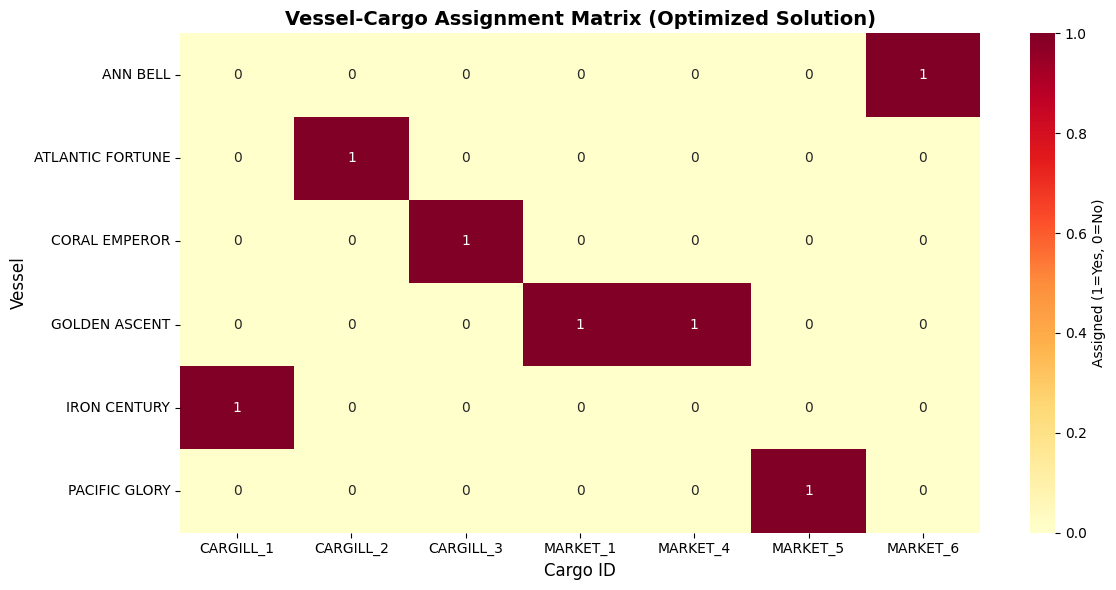


Summary:
  Total vessels used: 7
  Total cargoes assigned: 7
  Committed cargoes: 3
  Market cargoes: 4


In [ ]:
# Simple matrix visualization: Which vessel does which cargo?

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create assignment matrix from assignments_df (after Cell 10)
if 'assignments_df' in globals() and len(assignments_df) > 0:
    # Build matrix: rows = vessels, columns = cargoes
    assign_matrix = (
        assignments_df
        .assign(assigned=1)
        .pivot_table(
            index='Vessel_Name',
            columns='Cargo_ID',
            values='assigned',
            aggfunc='max',
            fill_value=0
        )
    )
    
    print("Assignment Matrix (1 = vessel assigned to cargo):")
    print(assign_matrix)
    
    # Visualize as heatmap
    plt.figure(figsize=(12, 6))
    sns.heatmap(assign_matrix, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Assigned (1=Yes, 0=No)'})
    plt.title('Vessel-Cargo Assignment Matrix (Optimized Solution)', fontsize=14, fontweight='bold')
    plt.ylabel('Vessel', fontsize=12)
    plt.xlabel('Cargo ID', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Summary stats
    print(f"\nSummary:")
    print(f"  Total vessels used: {assign_matrix.sum(axis=1).sum()}")
    print(f"  Total cargoes assigned: {assign_matrix.sum(axis=0).sum()}")
    print(f"  Committed cargoes: {assign_matrix[[c for c in assign_matrix.columns if 'CARGILL' in c]].sum(axis=0).sum()}")
    print(f"  Market cargoes: {assign_matrix[[c for c in assign_matrix.columns if 'MARKET' in c]].sum(axis=0).sum()}")
else:
    print("assignments_df not found. Run Cells 9-10 first to solve the optimization.")

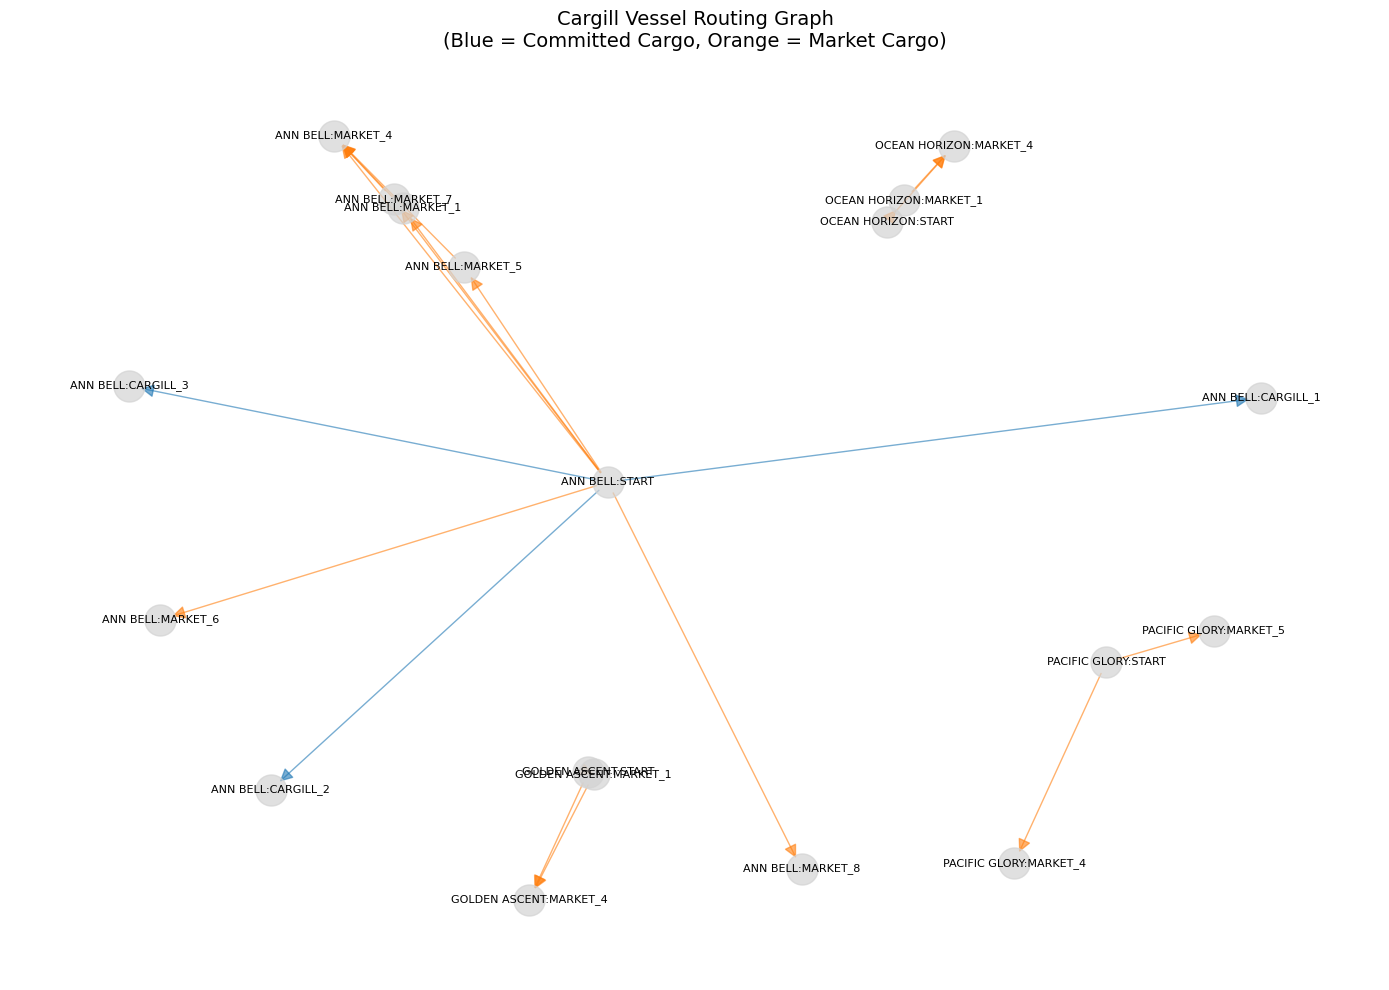

Graph has 19 nodes and 20 edges


In [ ]:
# Visualize feasible arcs for Cargill vessels as a graph

# %pip install networkx matplotlib -q
import networkx as nx
import matplotlib.pyplot as plt

# Build a directed graph (FIXED: DiGraph not Digraph)
G = nx.DiGraph()

# Add nodes and edges for Cargill vessels
for arc in cargill_arcs:
    vessel_name = arc['vessel_name']
    from_node = f"{vessel_name}:{arc['from_node']}"
    to_node = f"{vessel_name}:{arc['to_node']}"
    
    # Use different colors for committed vs market cargo
    color = "tab:blue" if arc['cargo_type'] == 'committed' else "tab:orange"
    
    G.add_node(from_node)
    G.add_node(to_node)
    G.add_edge(from_node, to_node, color=color, weight=arc['profit'])

# Draw the graph
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=1.5, iterations=50, seed=42)

# Get edge colors from attributes
edge_colors = [G[u][v]['color'] for u, v in G.edges()]

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=500, node_color='lightgray', alpha=0.7)

# Draw edges with colors
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, arrows=True, arrowsize=20, alpha=0.6)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("Cargill Vessel Routing Graph\n(Blue = Committed Cargo, Orange = Market Cargo)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

In [ ]:
# DIAGNOSTIC: Detailed cost breakdown for ALL possible vessel-cargo combinations
# This shows WHY the optimizer chose what it did

print("=" * 100)
print("COMPREHENSIVE COST BREAKDOWN: ALL POSSIBLE VESSEL-CARGO COMBINATIONS")
print("=" * 100)

# For each committed cargo, show ALL possible vessel assignments
for c_idx, committed_cargo in cargill_cargoes_processed.iterrows():
    cargo_id = committed_cargo['cargo_id']
    load_port = committed_cargo['load_port']
    discharge_port = committed_cargo['discharge_port']
    quantity = committed_cargo['quantity_mt']
    freight_rate = committed_cargo['freight_rate_usd_per_mt']
    
    print(f"\n{'='*100}")
    print(f"COMMITTED CARGO: {cargo_id}")
    print(f"  Route: {load_port} → {discharge_port}")
    print(f"  Quantity: {quantity:,.0f} MT")
    print(f"  Freight Rate: ${freight_rate:.2f}/MT")
    print(f"  Laycan: {committed_cargo['laycan_start_date'].date()} to {committed_cargo['laycan_end_date'].date()}")
    print(f"{'='*100}\n")
    
    # Check ALL Cargill vessels
    print("CARGILL VESSEL OPTIONS:")
    print("-" * 100)
    cargill_options = []
    
    for v_idx, vessel in cargill_vessels_processed.iterrows():
        vessel_name = vessel['vessel_name']
        start_port = vessel['current_position_port']
        start_time = vessel['estimated_time_of_departure']
        
        leg_data = evaluate_leg(
            start_port, start_time, vessel, committed_cargo,
            distance_lookup, get_bunker_price, get_market_freight_rate
        )
        
        if leg_data is not None:
            cargill_options.append({
                'vessel_name': vessel_name,
                'vessel_type': 'Cargill',
                'leg_data': leg_data
            })
            
            print(f"\n  VESSEL: {vessel_name}")
            print(f"    Start: {start_port} at {start_time.date()}")
            print(f"    Capacity: {vessel['deadweight_tonnage_dwt']:,.0f} MT (cargo: {quantity:,.0f} MT) ✓")
            print(f"\n    DISTANCE BREAKDOWN:")
            print(f"      Ballast: {start_port} → {load_port}: {leg_data['ballast_distance']:.1f} nm")
            print(f"      Laden: {load_port} → {discharge_port}: {leg_data['laden_distance']:.1f} nm")
            print(f"      Total distance: {leg_data['ballast_distance'] + leg_data['laden_distance']:.1f} nm")
            
            print(f"\n    TIME BREAKDOWN:")
            print(f"      Ballast: {leg_data['days_ballast']:.2f} days")
            print(f"      Waiting: {leg_data['days_waiting']:.2f} days")
            print(f"      Port (load+discharge): {leg_data['days_port']:.2f} days")
            print(f"      Laden: {leg_data['days_laden']:.2f} days")
            print(f"      TOTAL: {leg_data['total_days']:.2f} days")
            print(f"      Arrival at load: {leg_data['arrival_at_load'].date()}")
            print(f"      Actual load start: {leg_data['actual_load_start'].date()}")
            print(f"      Completion: {leg_data['completion_time'].date()}")
            
            print(f"\n    FUEL COST BREAKDOWN:")
            print(f"      Ballast fuel: {vessel['sea_consumption_mt_per_day'] * leg_data['days_ballast']:.2f} MT")
            print(f"        × Bunker price @ {start_port}: ${leg_data['bunker_price_ballast']:.2f}/MT")
            print(f"        = ${leg_data['fuel_cost_ballast']:,.2f}")
            print(f"      Waiting fuel: {vessel['port_consumption_idle_mt_per_day'] * leg_data['days_waiting']:.2f} MT")
            print(f"        × Bunker price @ {load_port}: ${leg_data['bunker_price_waiting']:.2f}/MT")
            print(f"        = ${leg_data['fuel_cost_waiting']:,.2f}")
            print(f"      Laden fuel: {vessel['consumption_laden'] * leg_data['days_laden']:.2f} MT")
            print(f"        × Bunker price @ {load_port}: ${leg_data['bunker_price_laden']:.2f}/MT")
            print(f"        = ${leg_data['fuel_cost_laden']:,.2f}")
            print(f"      Port fuel (working): {vessel['port_consumption_mt_per_day'] * leg_data['days_port']:.2f} MT")
            print(f"        × Bunker price @ {load_port}: ${leg_data['bunker_price_port']:.2f}/MT")
            print(f"        = ${leg_data['fuel_cost_port']:,.2f}")
            print(f"      TOTAL FUEL COST: ${leg_data['fuel_cost']:,.2f}")
            
            print(f"\n    OTHER COSTS:")
            print(f"      Hire cost: ${vessel['hire_rate_usd_per_day']:.2f}/day × {leg_data['total_days']:.2f} days = ${leg_data['hire_cost']:,.2f}")
            print(f"      Port costs: ${leg_data['port_costs']:,.2f}")
            print(f"      Commission: {committed_cargo['commission_percent']*100:.2f}% × ${leg_data['revenue']:,.2f} = ${leg_data['commission']:,.2f}")
            print(f"      TOTAL COSTS: ${leg_data['costs']:,.2f}")
            
            print(f"\n    REVENUE & PROFIT:")
            print(f"      Revenue: ${freight_rate:.2f}/MT × {quantity:,.0f} MT = ${leg_data['revenue']:,.2f}")
            print(f"      PROFIT: ${leg_data['profit']:,.2f}")
            print(f"      TCE: ${leg_data['profit']/leg_data['total_days']:,.2f}/day")
        else:
            print(f"\n  VESSEL: {vessel_name}")
            print(f"    ❌ INFEASIBLE (capacity, distance, or laycan issue)")
    
    # Check ALL Market vessels
    print(f"\n\nMARKET VESSEL OPTIONS:")
    print("-" * 100)
    market_options = []
    
    for m_idx, vessel in market_vessels_processed.iterrows():
        vessel_name = vessel['vessel_name']
        start_port = vessel['current_position_port']
        start_time = vessel['estimated_time_of_departure']
        
        leg_data = evaluate_leg(
            start_port, start_time, vessel, committed_cargo,
            distance_lookup, get_bunker_price, get_market_freight_rate
        )
        
        if leg_data is not None:
            market_options.append({
                'vessel_name': vessel_name,
                'vessel_type': 'Market',
                'leg_data': leg_data
            })
            
            print(f"\n  VESSEL: {vessel_name}")
            print(f"    Start: {start_port} at {start_time.date()}")
            print(f"    Capacity: {vessel['deadweight_tonnage_dwt']:,.0f} MT (cargo: {quantity:,.0f} MT) ✓")
            print(f"\n    DISTANCE BREAKDOWN:")
            print(f"      Ballast: {start_port} → {load_port}: {leg_data['ballast_distance']:.1f} nm")
            print(f"      Laden: {load_port} → {discharge_port}: {leg_data['laden_distance']:.1f} nm")
            print(f"      Total distance: {leg_data['ballast_distance'] + leg_data['laden_distance']:.1f} nm")
            
            print(f"\n    TIME BREAKDOWN:")
            print(f"      Ballast: {leg_data['days_ballast']:.2f} days")
            print(f"      Waiting: {leg_data['days_waiting']:.2f} days")
            print(f"      Port (load+discharge): {leg_data['days_port']:.2f} days")
            print(f"      Laden: {leg_data['days_laden']:.2f} days")
            print(f"      TOTAL: {leg_data['total_days']:.2f} days")
            
            print(f"\n    FUEL COST BREAKDOWN:")
            print(f"      Ballast fuel: {vessel['sea_consumption_mt_per_day'] * leg_data['days_ballast']:.2f} MT")
            print(f"        × Bunker price @ {start_port}: ${leg_data['bunker_price_ballast']:.2f}/MT")
            print(f"        = ${leg_data['fuel_cost_ballast']:,.2f}")
            print(f"      Waiting fuel: {vessel['port_consumption_idle_mt_per_day'] * leg_data['days_waiting']:.2f} MT")
            print(f"        × Bunker price @ {load_port}: ${leg_data['bunker_price_waiting']:.2f}/MT")
            print(f"        = ${leg_data['fuel_cost_waiting']:,.2f}")
            print(f"      Laden fuel: {vessel['consumption_laden'] * leg_data['days_laden']:.2f} MT")
            print(f"        × Bunker price @ {load_port}: ${leg_data['bunker_price_laden']:.2f}/MT")
            print(f"        = ${leg_data['fuel_cost_laden']:,.2f}")
            print(f"      Port fuel (working): {vessel['port_consumption_mt_per_day'] * leg_data['days_port']:.2f} MT")
            print(f"        × Bunker price @ {load_port}: ${leg_data['bunker_price_port']:.2f}/MT")
            print(f"        = ${leg_data['fuel_cost_port']:,.2f}")
            print(f"      TOTAL FUEL COST: ${leg_data['fuel_cost']:,.2f}")
            
            print(f"\n    OTHER COSTS:")
            print(f"      Hire cost: $0 (market vessel - no hire cost)")
            print(f"      Port costs: ${leg_data['port_costs']:,.2f}")
            print(f"      Commission: {committed_cargo['commission_percent']*100:.2f}% × ${leg_data['revenue']:,.2f} = ${leg_data['commission']:,.2f}")
            print(f"      TOTAL COSTS: ${leg_data['costs']:,.2f}")
            
            print(f"\n    REVENUE & PROFIT:")
            print(f"      Revenue: ${freight_rate:.2f}/MT × {quantity:,.0f} MT = ${leg_data['revenue']:,.2f}")
            print(f"      PROFIT: ${leg_data['profit']:,.2f}")
            print(f"      TCE: ${leg_data['profit']/leg_data['total_days']:,.2f}/day")
        else:
            print(f"\n  VESSEL: {vessel_name}")
            print(f"    ❌ INFEASIBLE (capacity, distance, or laycan issue)")
    
    # Summary comparison
    print(f"\n\n{'='*100}")
    print(f"SUMMARY FOR {cargo_id}:")
    print(f"{'='*100}")
    
    all_options = cargill_options + market_options
    if len(all_options) > 0:
        # Sort by profit
        all_options.sort(key=lambda x: x['leg_data']['profit'], reverse=True)
        
        print(f"\nRanked by PROFIT (best to worst):")
        print("-" * 100)
        for rank, opt in enumerate(all_options, 1):
            print(f"{rank}. {opt['vessel_name']} ({opt['vessel_type']}): "
                  f"Profit = ${opt['leg_data']['profit']:,.2f}, "
                  f"TCE = ${opt['leg_data']['profit']/opt['leg_data']['total_days']:,.2f}/day")
        
        best = all_options[0]
        print(f"\n✓ BEST OPTION: {best['vessel_name']} ({best['vessel_type']})")
        print(f"  Profit: ${best['leg_data']['profit']:,.2f}")
    else:
        print("  ❌ NO FEASIBLE OPTIONS FOUND!")

# Now show what happens if Cargill vessels take market cargoes
print(f"\n\n{'='*100}")
print("WHAT IF CARGILL VESSELS TAKE MARKET CARGOES?")
print(f"{'='*100}\n")

for m_idx, market_cargo in market_cargoes_processed.iterrows():
    cargo_id = market_cargo['cargo_id']
    load_port = market_cargo['load_port']
    discharge_port = market_cargo['discharge_port']
    quantity = market_cargo['quantity_mt']
    freight_rate = market_cargo['freight_rate_usd_per_mt']
    
    print(f"\n{'='*100}")
    print(f"MARKET CARGO: {cargo_id}")
    print(f"  Route: {load_port} → {discharge_port}")
    print(f"  Quantity: {quantity:,.0f} MT")
    print(f"  Freight Rate: ${freight_rate:.2f}/MT")
    print(f"  Laycan: {market_cargo['laycan_start_date'].date()} to {market_cargo['laycan_end_date'].date()}")
    print(f"{'='*100}\n")
    
    market_cargo_options = []
    
    for v_idx, vessel in cargill_vessels_processed.iterrows():
        vessel_name = vessel['vessel_name']
        start_port = vessel['current_position_port']
        start_time = vessel['estimated_time_of_departure']
        
        leg_data = evaluate_leg(
            start_port, start_time, vessel, market_cargo,
            distance_lookup, get_bunker_price, get_market_freight_rate
        )
        
        if leg_data is not None:
            market_cargo_options.append({
                'vessel_name': vessel_name,
                'leg_data': leg_data
            })
            
            print(f"  {vessel_name}:")
            print(f"    Revenue: ${leg_data['revenue']:,.2f}")
            print(f"    Costs: ${leg_data['costs']:,.2f}")
            print(f"      - Fuel: ${leg_data['fuel_cost']:,.2f}")
            print(f"      - Hire: ${leg_data['hire_cost']:,.2f}")
            print(f"      - Port: ${leg_data['port_costs']:,.2f}")
            print(f"      - Commission: ${leg_data['commission']:,.2f}")
            print(f"    PROFIT: ${leg_data['profit']:,.2f}")
            print(f"    TCE: ${leg_data['profit']/leg_data['total_days']:,.2f}/day")
            print()
    
    if len(market_cargo_options) == 0:
        print("  ❌ No Cargill vessels can feasibly take this market cargo")
    else:
        best_market = max(market_cargo_options, key=lambda x: x['leg_data']['profit'])
        print(f"  ✓ Best option: {best_market['vessel_name']} with profit ${best_market['leg_data']['profit']:,.2f}")

print(f"\n{'='*100}")
print("END OF DIAGNOSTIC")
print(f"{'='*100}")

COMPREHENSIVE COST BREAKDOWN: ALL POSSIBLE VESSEL-CARGO COMBINATIONS

COMMITTED CARGO: CARGILL_1
  Route: KAMSAR ANCHORAGE → QINGDAO
  Quantity: 180,000 MT
  Freight Rate: $23.00/MT
  Laycan: 2026-04-02 to 2026-04-10

CARGILL VESSEL OPTIONS:
----------------------------------------------------------------------------------------------------

  VESSEL: ANN BELL
    Start: QINGDAO at 2026-02-25
    Capacity: 180,803 MT (cargo: 180,000 MT) ✓

    DISTANCE BREAKDOWN:
      Ballast: QINGDAO → KAMSAR ANCHORAGE: 11124.0 nm
      Laden: KAMSAR ANCHORAGE → QINGDAO: 11124.0 nm
      Total distance: 22248.0 nm

    TIME BREAKDOWN:
      Ballast: 37.08 days
      Waiting: 0.00 days
      Port (load+discharge): 1.00 days
      Laden: 38.62 days
      TOTAL: 76.70 days
      Arrival at load: 2026-04-03
      Actual load start: 2026-04-03
      Completion: 2026-05-12

    FUEL COST BREAKDOWN:
      Ballast fuel: 1409.04 MT
        × Bunker price @ QINGDAO: $643.71/MT
        = $907,019.18
      Waiti

In [ ]:
# DEEP COST COMPARISON: Cargill vessel (market cargo) vs Market vessel (committed cargo)
# Find similar routes and compare costs in detail

print("=" * 120)
print("DEEP COST COMPARISON: Cargill Vessel (Market Cargo) vs Market Vessel (Committed Cargo)")
print("=" * 120)

# Find scenarios where routes are similar (same or nearby ports)
comparisons = []

# Strategy: For each committed cargo, find market cargoes with similar routes
# Then compare: Cargill vessel doing market cargo vs Market vessel doing committed cargo

for c_idx, committed_cargo in cargill_cargoes_processed.iterrows():
    committed_id = committed_cargo['cargo_id']
    committed_load = committed_cargo['load_port']
    committed_discharge = committed_cargo['discharge_port']
    
    # Find market cargoes with similar routes (same discharge port or nearby)
    for m_idx, market_cargo in market_cargoes_processed.iterrows():
        market_id = market_cargo['cargo_id']
        market_load = market_cargo['load_port']
        market_discharge = market_cargo['discharge_port']
        
        # Check if routes are similar (same discharge port is a good match)
        if market_discharge == committed_discharge:
            # Scenario: Compare
            # 1. Cargill vessel doing MARKET cargo
            # 2. Market vessel doing COMMITTED cargo
            
            # Find best Cargill vessel for market cargo
            best_cargill_market = None
            best_cargill_market_profit = float('-inf')
            
            for v_idx, cargill_vessel in cargill_vessels_processed.iterrows():
                leg_data = evaluate_leg(
                    cargill_vessel['current_position_port'],
                    cargill_vessel['estimated_time_of_departure'],
                    cargill_vessel,
                    market_cargo,
                    distance_lookup,
                    get_bunker_price,
                    get_market_freight_rate
                )
                
                if leg_data and leg_data['profit'] > best_cargill_market_profit:
                    best_cargill_market_profit = leg_data['profit']
                    best_cargill_market = {
                        'vessel': cargill_vessel,
                        'vessel_name': cargill_vessel['vessel_name'],
                        'cargo': market_cargo,
                        'cargo_id': market_id,
                        'leg_data': leg_data
                    }
            
            # Find best Market vessel for committed cargo
            best_market_committed = None
            best_market_committed_profit = float('-inf')
            
            for m_v_idx, market_vessel in market_vessels_processed.iterrows():
                leg_data = evaluate_leg(
                    market_vessel['current_position_port'],
                    market_vessel['estimated_time_of_departure'],
                    market_vessel,
                    committed_cargo,
                    distance_lookup,
                    get_bunker_price,
                    get_market_freight_rate
                )
                
                if leg_data and leg_data['profit'] > best_market_committed_profit:
                    best_market_committed_profit = leg_data['profit']
                    best_market_committed = {
                        'vessel': market_vessel,
                        'vessel_name': market_vessel['vessel_name'],
                        'cargo': committed_cargo,
                        'cargo_id': committed_id,
                        'leg_data': leg_data
                    }
            
            # Only add if both are feasible
            if best_cargill_market and best_market_committed:
                comparisons.append({
                    'scenario': f"{best_cargill_market['vessel_name']} (MARKET: {market_id}) vs {best_market_committed['vessel_name']} (COMMITTED: {committed_id})",
                    'cargill_market': best_cargill_market,
                    'market_committed': best_market_committed,
                    'route_similarity': f"Both discharge at {market_discharge}"
                })

# Show top 3 comparisons (by profit difference)
if len(comparisons) > 0:
    # Sort by absolute profit difference
    comparisons.sort(key=lambda x: abs(x['cargill_market']['leg_data']['profit'] - x['market_committed']['leg_data']['profit']), reverse=True)
    
    for comp_idx, comp in enumerate(comparisons[:3], 1):
        print(f"\n{'='*120}")
        print(f"SCENARIO {comp_idx}: {comp['scenario']}")
        print(f"Route Similarity: {comp['route_similarity']}")
        print(f"{'='*120}\n")
        
        carg_mkt = comp['cargill_market']
        mkt_comm = comp['market_committed']
        
        # Left side: Cargill vessel doing market cargo
        print("OPTION A: CARGILL VESSEL DOING MARKET CARGO")
        print("-" * 120)
        print(f"Vessel: {carg_mkt['vessel_name']} (Cargill)")
        print(f"Cargo: {carg_mkt['cargo_id']} (Market)")
        print(f"Route: {carg_mkt['cargo']['load_port']} → {carg_mkt['cargo']['discharge_port']}")
        print(f"Quantity: {carg_mkt['cargo']['quantity_mt']:,.0f} MT")
        print(f"Freight Rate: ${carg_mkt['cargo']['freight_rate_usd_per_mt']:.2f}/MT")
        
        ld = carg_mkt['leg_data']
        v = carg_mkt['vessel']
        
        print(f"\nDISTANCE & TIME:")
        print(f"  Ballast: {v['current_position_port']} → {carg_mkt['cargo']['load_port']}: {ld['ballast_distance']:.1f} nm, {ld['days_ballast']:.2f} days")
        print(f"  Waiting: {ld['days_waiting']:.2f} days")
        print(f"  Laden: {ld['laden_distance']:.1f} nm, {ld['days_laden']:.2f} days")
        print(f"  Port: {ld['days_port']:.2f} days")
        print(f"  TOTAL TIME: {ld['total_days']:.2f} days")
        
        print(f"\nDETAILED COST BREAKDOWN:")
        print(f"  REVENUE:")
        print(f"    {carg_mkt['cargo']['freight_rate_usd_per_mt']:.2f}/MT × {carg_mkt['cargo']['quantity_mt']:,.0f} MT = ${ld['revenue']:,.2f}")
        
        print(f"\n  FUEL COSTS:")
        fuel_ballast_qty = v['sea_consumption_mt_per_day'] * ld['days_ballast']
        fuel_waiting_qty = v['port_consumption_idle_mt_per_day'] * ld['days_waiting']
        fuel_laden_qty = v['consumption_laden'] * ld['days_laden']
        fuel_port_qty = v['port_consumption_mt_per_day'] * ld['days_port']
        
        print(f"    Ballast: {fuel_ballast_qty:.2f} MT × ${ld['bunker_price_ballast']:.2f}/MT = ${ld['fuel_cost_ballast']:,.2f}")
        print(f"    Waiting: {fuel_waiting_qty:.2f} MT × ${ld['bunker_price_waiting']:.2f}/MT = ${ld['fuel_cost_waiting']:,.2f}")
        print(f"    Laden: {fuel_laden_qty:.2f} MT × ${ld['bunker_price_laden']:.2f}/MT = ${ld['fuel_cost_laden']:,.2f}")
        print(f"    Port: {fuel_port_qty:.2f} MT × ${ld['bunker_price_port']:.2f}/MT = ${ld['fuel_cost_port']:,.2f}")
        print(f"    TOTAL FUEL: ${ld['fuel_cost']:,.2f}")
        
        print(f"\n  OTHER COSTS:")
        print(f"    Hire: ${v['hire_rate_usd_per_day']:.2f}/day × {ld['total_days']:.2f} days = ${ld['hire_cost']:,.2f}")
        print(f"    Port costs: ${ld['port_costs']:,.2f}")
        print(f"    Commission: {carg_mkt['cargo']['commission_percent']*100:.2f}% × ${ld['revenue']:,.2f} = ${ld['commission']:,.2f}")
        print(f"    TOTAL COSTS: ${ld['costs']:,.2f}")
        
        print(f"\n  PROFIT:")
        print(f"    ${ld['revenue']:,.2f} - ${ld['costs']:,.2f} = ${ld['profit']:,.2f}")
        print(f"    TCE: ${ld['profit']/ld['total_days']:,.2f}/day")
        
        # Right side: Market vessel doing committed cargo
        print(f"\n\nOPTION B: MARKET VESSEL DOING COMMITTED CARGO")
        print("-" * 120)
        print(f"Vessel: {mkt_comm['vessel_name']} (Market)")
        print(f"Cargo: {mkt_comm['cargo_id']} (Committed)")
        print(f"Route: {mkt_comm['cargo']['load_port']} → {mkt_comm['cargo']['discharge_port']}")
        print(f"Quantity: {mkt_comm['cargo']['quantity_mt']:,.0f} MT")
        print(f"Freight Rate: ${mkt_comm['cargo']['freight_rate_usd_per_mt']:.2f}/MT")
        
        ld2 = mkt_comm['leg_data']
        v2 = mkt_comm['vessel']
        
        print(f"\nDISTANCE & TIME:")
        print(f"  Ballast: {v2['current_position_port']} → {mkt_comm['cargo']['load_port']}: {ld2['ballast_distance']:.1f} nm, {ld2['days_ballast']:.2f} days")
        print(f"  Waiting: {ld2['days_waiting']:.2f} days")
        print(f"  Laden: {ld2['laden_distance']:.1f} nm, {ld2['days_laden']:.2f} days")
        print(f"  Port: {ld2['days_port']:.2f} days")
        print(f"  TOTAL TIME: {ld2['total_days']:.2f} days")
        
        print(f"\nDETAILED COST BREAKDOWN:")
        print(f"  REVENUE:")
        print(f"    {mkt_comm['cargo']['freight_rate_usd_per_mt']:.2f}/MT × {mkt_comm['cargo']['quantity_mt']:,.0f} MT = ${ld2['revenue']:,.2f}")
        
        print(f"\n  FUEL COSTS:")
        fuel_ballast_qty2 = v2['sea_consumption_mt_per_day'] * ld2['days_ballast']
        fuel_waiting_qty2 = v2['port_consumption_idle_mt_per_day'] * ld2['days_waiting']
        fuel_laden_qty2 = v2['consumption_laden'] * ld2['days_laden']
        fuel_port_qty2 = v2['port_consumption_mt_per_day'] * ld2['days_port']
        
        print(f"    Ballast: {fuel_ballast_qty2:.2f} MT × ${ld2['bunker_price_ballast']:.2f}/MT = ${ld2['fuel_cost_ballast']:,.2f}")
        print(f"    Waiting: {fuel_waiting_qty2:.2f} MT × ${ld2['bunker_price_waiting']:.2f}/MT = ${ld2['fuel_cost_waiting']:,.2f}")
        print(f"    Laden: {fuel_laden_qty2:.2f} MT × ${ld2['bunker_price_laden']:.2f}/MT = ${ld2['fuel_cost_laden']:,.2f}")
        print(f"    Port: {fuel_port_qty2:.2f} MT × ${ld2['bunker_price_port']:.2f}/MT = ${ld2['fuel_cost_port']:,.2f}")
        print(f"    TOTAL FUEL: ${ld2['fuel_cost']:,.2f}")
        
        print(f"\n  OTHER COSTS:")
        print(f"    Hire: $0/day (Market vessel - no hire cost)")
        print(f"    Port costs: ${ld2['port_costs']:,.2f}")
        print(f"    Commission: {mkt_comm['cargo']['commission_percent']*100:.2f}% × ${ld2['revenue']:,.2f} = ${ld2['commission']:,.2f}")
        print(f"    TOTAL COSTS: ${ld2['costs']:,.2f}")
        
        print(f"\n  PROFIT:")
        print(f"    ${ld2['revenue']:,.2f} - ${ld2['costs']:,.2f} = ${ld2['profit']:,.2f}")
        print(f"    TCE: ${ld2['profit']/ld2['total_days']:,.2f}/day")
        
        # Side-by-side comparison
        print(f"\n\n{'='*120}")
        print("SIDE-BY-SIDE COMPARISON")
        print(f"{'='*120}")
        print(f"{'Metric':<40} {'Option A (Cargill→Market)':<35} {'Option B (Market→Committed)':<35} {'Difference':<20}")
        print("-" * 120)
        print(f"{'Revenue':<40} ${ld['revenue']:>30,.2f} ${ld2['revenue']:>30,.2f} ${ld['revenue']-ld2['revenue']:>15,.2f}")
        print(f"{'Fuel Cost':<40} ${ld['fuel_cost']:>30,.2f} ${ld2['fuel_cost']:>30,.2f} ${ld['fuel_cost']-ld2['fuel_cost']:>15,.2f}")
        print(f"{'Hire Cost':<40} ${ld['hire_cost']:>30,.2f} ${ld2['hire_cost']:>30,.2f} ${ld['hire_cost']-ld2['hire_cost']:>15,.2f}")
        print(f"{'Port Costs':<40} ${ld['port_costs']:>30,.2f} ${ld2['port_costs']:>30,.2f} ${ld['port_costs']-ld2['port_costs']:>15,.2f}")
        print(f"{'Commission':<40} ${ld['commission']:>30,.2f} ${ld2['commission']:>30,.2f} ${ld['commission']-ld2['commission']:>15,.2f}")
        print(f"{'Total Costs':<40} ${ld['costs']:>30,.2f} ${ld2['costs']:>30,.2f} ${ld['costs']-ld2['costs']:>15,.2f}")
        print(f"{'PROFIT':<40} ${ld['profit']:>30,.2f} ${ld2['profit']:>30,.2f} ${ld['profit']-ld2['profit']:>15,.2f}")
        print(f"{'TCE ($/day)':<40} ${ld['profit']/ld['total_days']:>30,.2f} ${ld2['profit']/ld2['total_days']:>30,.2f} ${(ld['profit']/ld['total_days'])-(ld2['profit']/ld2['total_days']):>15,.2f}")
        print(f"{'Total Days':<40} {ld['total_days']:>30.2f} {ld2['total_days']:>30.2f} {ld['total_days']-ld2['total_days']:>15.2f}")
        
        # Key insights
        print(f"\n{'='*120}")
        print("KEY INSIGHTS:")
        print(f"{'='*120}")
        
        hire_diff = ld['hire_cost'] - ld2['hire_cost']
        fuel_diff = ld['fuel_cost'] - ld2['fuel_cost']
        revenue_diff = ld['revenue'] - ld2['revenue']
        profit_diff = ld['profit'] - ld2['profit']
        
        print(f"1. HIRE COST DIFFERENCE: ${hire_diff:,.2f}")
        print(f"   → Cargill vessel pays ${ld['hire_cost']:,.2f} in hire costs")
        print(f"   → Market vessel pays $0 (no hire cost)")
        print(f"   → This is a ${hire_diff:,.2f} advantage for Market vessel")
        
        print(f"\n2. FUEL COST DIFFERENCE: ${fuel_diff:,.2f}")
        if abs(fuel_diff) > 10000:
            print(f"   → Significant difference! Check vessel fuel efficiency and distances")
            print(f"   → Cargill: {fuel_ballast_qty+fuel_laden_qty:.2f} MT total fuel")
            print(f"   → Market: {fuel_ballast_qty2+fuel_laden_qty2:.2f} MT total fuel")
        
        print(f"\n3. REVENUE DIFFERENCE: ${revenue_diff:,.2f}")
        print(f"   → Market cargo rate: ${carg_mkt['cargo']['freight_rate_usd_per_mt']:.2f}/MT")
        print(f"   → Committed cargo rate: ${mkt_comm['cargo']['freight_rate_usd_per_mt']:.2f}/MT")
        
        print(f"\n4. NET PROFIT DIFFERENCE: ${profit_diff:,.2f}")
        if profit_diff > 0:
            print(f"   → Option A (Cargill→Market) is MORE profitable by ${profit_diff:,.2f}")
        else:
            print(f"   → Option B (Market→Committed) is MORE profitable by ${abs(profit_diff):,.2f}")
        
        print(f"\n5. WHY THE OPTIMIZER CHOSE:")
        if profit_diff > 0:
            print(f"   → If optimizer chose Option B, it's because:")
            print(f"     - Option A doesn't cover a committed cargo (must be done!)")
            print(f"     - Option B covers a committed cargo (required)")
            print(f"     - The ${abs(profit_diff):,.2f} profit loss is worth it to fulfill contract")
        else:
            print(f"   → Option B is both more profitable AND covers committed cargo")
            print(f"   → This is the clear winner!")

else:
    print("No similar routes found for comparison.")
    print("Try running this after the optimization has generated feasible arcs.")

DEEP COST COMPARISON: Cargill Vessel (Market Cargo) vs Market Vessel (Committed Cargo)

SCENARIO 1: GOLDEN ASCENT (MARKET: MARKET_1) vs IRON CENTURY (COMMITTED: CARGILL_1)
Route Similarity: Both discharge at QINGDAO

OPTION A: CARGILL VESSEL DOING MARKET CARGO
------------------------------------------------------------------------------------------------------------------------
Vessel: GOLDEN ASCENT (Cargill)
Cargo: MARKET_1 (Market)
Route: DAMPIER → QINGDAO
Quantity: 170,000 MT
Freight Rate: $9.00/MT

DISTANCE & TIME:
  Ballast: FANGCHENG → DAMPIER: 2681.1 nm, 9.08 days
  Waiting: 0.00 days
  Laden: 3331.2 nm, 11.76 days
  Port: 1.50 days
  TOTAL TIME: 22.34 days

DETAILED COST BREAKDOWN:
  REVENUE:
    9.00/MT × 170,000 MT = $1,530,000.00

  FUEL COSTS:
    Ballast: 336.04 MT × $643.42/MT = $216,216.71
    Waiting: 0.00 MT × $489.48/MT = $0.00
    Laden: 482.27 MT × $489.48/MT = $236,063.97
    Port: 4.65 MT × $489.48/MT = $2,276.10
    TOTAL FUEL: $454,556.78

  OTHER COSTS:
    Hi

# Sensitivity Analysis

This section performs sensitivity analysis on the optimal solution:
1. **Port Delay in China**: Find additional delay days that make current solution suboptimal
2. **Bunker Price Increase**: Find price increase % that makes current solution suboptimal

In [ ]:
# Cell 22: Sensitivity Analysis Setup - Wrapper Functions

def create_evaluate_leg_with_delays(base_evaluate_leg_fn, port_delay_overrides):
    """
    Create a modified evaluate_leg function with port delay overrides.
    
    Args:
        base_evaluate_leg_fn: Original evaluate_leg function
        port_delay_overrides: Dict mapping port_name -> additional_delay_days
    
    Returns:
        Modified evaluate_leg function
    """
    def evaluate_leg_modified(start_port, start_time, vessel_row, cargo_row, distance_lookup, 
                              get_bunker_price_fn, get_market_freight_rate_fn):
        # Create a copy of cargo_row to avoid modifying original
        cargo_row_copy = cargo_row.copy()
        
        # Add delay to discharge port if specified
        if port_delay_overrides:
            discharge_port = cargo_row['discharge_port']
            if discharge_port in port_delay_overrides:
                additional_hours = port_delay_overrides[discharge_port] * 24.0
                original_discharge_time = cargo_row['discharge_turn_time_hours']
                cargo_row_copy['discharge_turn_time_hours'] = original_discharge_time + additional_hours
        
        # Call original function with modified cargo_row
        result = base_evaluate_leg_fn(start_port, start_time, vessel_row, cargo_row_copy, 
                                       distance_lookup, get_bunker_price_fn, get_market_freight_rate_fn)
        return result
    return evaluate_leg_modified


def create_bunker_price_fn_with_multiplier(base_get_bunker_price_fn, multiplier):
    """
    Create a modified get_bunker_price function with price multiplier.
    
    Args:
        base_get_bunker_price_fn: Original get_bunker_price function
        multiplier: Price multiplier (e.g., 1.5 = 50% increase)
    
    Returns:
        Modified get_bunker_price function
    """
    def get_bunker_price_modified(port_name, fuel_grade='VLSFO', date=None):
        base_price = base_get_bunker_price_fn(port_name, fuel_grade, date)
        if base_price is None:
            return None
        return base_price * multiplier
    return get_bunker_price_modified

print("✓ Sensitivity analysis wrapper functions created")

✓ Sensitivity analysis wrapper functions created


In [ ]:
# Cell 23: Base Optimization Function with Parameter Overrides

def run_optimization_with_overrides(port_delay_overrides=None, bunker_price_multiplier=1.0):
    """
    Run optimization with parameter overrides.
    
    Args:
        port_delay_overrides: Dict mapping port_name -> additional_delay_days (None = no delays)
        bunker_price_multiplier: Multiplier for all bunker prices (1.0 = no change)
    
    Returns:
        dict with keys: 'status', 'objective_value', 'selected_cargill_arcs', 'selected_market_arcs', 
                        'cargill_arcs', 'market_arcs', 'cargill_arc_vars', 'market_arc_vars', 'model'
    """
    from ortools.sat.python import cp_model
    import json
    import time
    
    # #region agent log
    with open("/Users/roysougata/Cargill Hackathon/.cursor/debug.log", "a") as f:
        f.write(json.dumps({"sessionId": "debug-session", "runId": "diagnosis", "hypothesisId": "H1", "location": "run_optimization_with_overrides:entry", "message": "Function entry", "data": {"port_delay_overrides": str(port_delay_overrides), "bunker_price_multiplier": bunker_price_multiplier}, "timestamp": int(time.time() * 1000)}) + "\n")
    # #endregion agent log
    
    # Check required variables exist (H1, H4)
    required_vars = ['cargill_vessels_processed', 'market_vessels_processed', 
                     'cargill_cargoes_processed', 'market_cargoes_processed',
                     'distance_lookup', 'get_bunker_price', 'get_market_freight_rate', 'evaluate_leg']
    missing_vars = [v for v in required_vars if v not in globals()]
    
    # #region agent log
    with open("/Users/roysougata/Cargill Hackathon/.cursor/debug.log", "a") as f:
        f.write(json.dumps({"sessionId": "debug-session", "runId": "diagnosis", "hypothesisId": "H1", "location": "run_optimization_with_overrides:check_vars", "message": "Checking required variables", "data": {"missing_vars": missing_vars, "all_present": len(missing_vars) == 0}, "timestamp": int(time.time() * 1000)}) + "\n")
    # #endregion agent log
    
    if missing_vars:
        return {
            'status': cp_model.MODEL_INVALID,
            'status_name': 'ERROR_MISSING_VARS',
            'objective_value': None,
            'selected_cargill_arcs': [],
            'selected_market_arcs': [],
            'cargill_arcs': [],
            'market_arcs': [],
            'cargill_arc_vars': {},
            'market_arc_vars': {},
            'model': None,
            'solver': None,
            'error': f"Missing variables: {missing_vars}"
        }
    
    try:
        # Recreate all_cargoes if not in scope (from Cell 7 logic)
        if 'all_cargoes' not in globals():
            # #region agent log
            with open("/Users/roysougata/Cargill Hackathon/.cursor/debug.log", "a") as f:
                f.write(json.dumps({"sessionId": "debug-session", "runId": "diagnosis", "hypothesisId": "H4", "location": "run_optimization_with_overrides:create_all_cargoes", "message": "Creating all_cargoes", "data": {"cargill_count": len(cargill_cargoes_processed), "market_count": len(market_cargoes_processed)}, "timestamp": int(time.time() * 1000)}) + "\n")
            # #endregion agent log
            all_cargoes = pd.concat([
                cargill_cargoes_processed.assign(cargo_type='committed', cargo_idx_in_type=range(len(cargill_cargoes_processed))),
                market_cargoes_processed.assign(cargo_type='market', cargo_idx_in_type=range(len(market_cargoes_processed)))
            ], ignore_index=True).reset_index(drop=True)
            # #region agent log
            with open("/Users/roysougata/Cargill Hackathon/.cursor/debug.log", "a") as f:
                f.write(json.dumps({"sessionId": "debug-session", "runId": "diagnosis", "hypothesisId": "H4", "location": "run_optimization_with_overrides:all_cargoes_created", "message": "all_cargoes created", "data": {"total_count": len(all_cargoes)}, "timestamp": int(time.time() * 1000)}) + "\n")
            # #endregion agent log
        else:
            all_cargoes = globals()['all_cargoes']
        
        # Create modified functions
        # #region agent log
        with open("/Users/roysougata/Cargill Hackathon/.cursor/debug.log", "a") as f:
            f.write(json.dumps({"sessionId": "debug-session", "runId": "diagnosis", "hypothesisId": "H5", "location": "run_optimization_with_overrides:before_create_functions", "message": "Before creating modified functions", "data": {}, "timestamp": int(time.time() * 1000)}) + "\n")
        # #endregion agent log
        evaluate_leg_modified = create_evaluate_leg_with_delays(evaluate_leg, port_delay_overrides)
        get_bunker_price_modified = create_bunker_price_fn_with_multiplier(get_bunker_price, bunker_price_multiplier)
        # #region agent log
        with open("/Users/roysougata/Cargill Hackathon/.cursor/debug.log", "a") as f:
            f.write(json.dumps({"sessionId": "debug-session", "runId": "diagnosis", "hypothesisId": "H5", "location": "run_optimization_with_overrides:after_create_functions", "message": "Modified functions created", "data": {}, "timestamp": int(time.time() * 1000)}) + "\n")
        # #endregion agent log
    
        # Generate arcs (reusing logic from Cell 7)
        # #region agent log
        with open("/Users/roysougata/Cargill Hackathon/.cursor/debug.log", "a") as f:
            f.write(json.dumps({"sessionId": "debug-session", "runId": "diagnosis", "hypothesisId": "H2", "location": "run_optimization_with_overrides:before_arc_generation", "message": "Starting arc generation", "data": {"vessel_count": len(cargill_vessels_processed)}, "timestamp": int(time.time() * 1000)}) + "\n")
        # #endregion agent log
        cargill_arcs_modified = []
        
        for v_idx, vessel in cargill_vessels_processed.iterrows():
            vessel_name = vessel['vessel_name']
            start_port = vessel['current_position_port']
            start_time = vessel['estimated_time_of_departure']
        
            # Arcs from Start -> any cargo
            for c_idx, cargo in all_cargoes.iterrows():
                leg_data = evaluate_leg_modified(
                    start_port, start_time, vessel, cargo,
                    distance_lookup, get_bunker_price_modified, get_market_freight_rate
                )
                
                if leg_data is not None:
                    cargill_arcs_modified.append({
                    'vessel_idx': v_idx,
                    'vessel_name': vessel_name,
                    'from_node': 'START',
                    'from_port': start_port,
                    'from_time': start_time,
                    'to_node': cargo['cargo_id'],
                    'to_cargo_idx': c_idx,
                    'cargo_type': cargo['cargo_type'],
                    'leg_data': leg_data,
                    'profit': leg_data['profit'],
                    'end_port': leg_data['end_port'],
                    'end_time': leg_data['end_time']
                })
        
        # Arcs from cargo -> cargo (for chaining)
        for c1_idx, cargo1 in all_cargoes.iterrows():
            leg1_data = evaluate_leg_modified(
                start_port, start_time, vessel, cargo1,
                distance_lookup, get_bunker_price_modified, get_market_freight_rate
            )
            
            if leg1_data is not None:
                end_port_c1 = leg1_data['end_port']
                end_time_c1 = leg1_data['end_time']
                
                for c2_idx, cargo2 in all_cargoes.iterrows():
                    if c1_idx == c2_idx:
                        continue
                    
                    leg2_data = evaluate_leg_modified(
                        end_port_c1, end_time_c1, vessel, cargo2,
                        distance_lookup, get_bunker_price_modified, get_market_freight_rate
                    )
                    
                    if leg2_data is not None:
                        cargill_arcs_modified.append({
                            'vessel_idx': v_idx,
                            'vessel_name': vessel_name,
                            'from_node': cargo1['cargo_id'],
                            'from_port': end_port_c1,
                            'from_time': end_time_c1,
                            'to_node': cargo2['cargo_id'],
                            'to_cargo_idx': c2_idx,
                            'cargo_type': cargo2['cargo_type'],
                            'leg_data': leg2_data,
                            'profit': leg2_data['profit'],
                            'end_port': leg2_data['end_port'],
                            'end_time': leg2_data['end_time']
                        })
        
        # Generate arcs for Market vessels
        market_arcs_modified = []
        
        for m_idx, vessel in market_vessels_processed.iterrows():
            vessel_name = vessel['vessel_name']
            start_port = vessel['current_position_port']
            start_time = vessel['estimated_time_of_departure']
            
            for c_idx, cargo in cargill_cargoes_processed.iterrows():
                leg_data = evaluate_leg_modified(
                    start_port, start_time, vessel, cargo,
                    distance_lookup, get_bunker_price_modified, get_market_freight_rate
                )
                
                if leg_data is not None:
                    market_arcs_modified.append({
                    'vessel_idx': m_idx,
                    'vessel_name': vessel_name,
                    'from_node': 'START',
                    'from_port': start_port,
                    'from_time': start_time,
                    'to_node': cargo['cargo_id'],
                    'to_cargo_idx': c_idx,
                    'cargo_type': 'committed',
                    'leg_data': leg_data,
                    'profit': leg_data['profit'],
                    'end_port': leg_data['end_port'],
                    'end_time': leg_data['end_time']
                })
        
        # Build CP-SAT model (reusing logic from Cell 8)
        model = cp_model.CpModel()
        
        # Create decision variables
        cargill_arc_vars = {}
        for i, arc in enumerate(cargill_arcs_modified):
            var_name = f"cargill_arc_{arc['vessel_idx']}_{arc['from_node']}_{arc['to_node']}"
            cargill_arc_vars[i] = model.NewBoolVar(var_name)
        
        market_arc_vars = {}
        for i, arc in enumerate(market_arcs_modified):
            var_name = f"market_arc_{arc['vessel_idx']}_{arc['to_node']}"
            market_arc_vars[i] = model.NewBoolVar(var_name)
        
        # Constraint 1: Each committed cargo assigned exactly once
        for c_idx, cargo in cargill_cargoes_processed.iterrows():
            cargo_id = cargo['cargo_id']
            pairs_for_cargo = [
                i for i, arc in enumerate(cargill_arcs_modified)
                if arc['to_node'] == cargo_id and arc['cargo_type'] == 'committed'
            ]
            pairs_for_cargo.extend([
                i for i, arc in enumerate(market_arcs_modified)
                if arc['to_node'] == cargo_id
            ])
            
            if len(pairs_for_cargo) > 0:
                model.Add(sum(cargill_arc_vars[i] if i < len(cargill_arcs_modified) else market_arc_vars[i - len(cargill_arcs_modified)] 
                             for i in pairs_for_cargo) == 1)
        
        # Constraint 2: Market cargoes optional (at most once)
        for c_idx, cargo in market_cargoes_processed.iterrows():
            cargo_id = cargo['cargo_id']
            arcs_for_cargo = [
                i for i, arc in enumerate(cargill_arcs_modified)
                if arc['to_node'] == cargo_id and arc['cargo_type'] == 'market'
            ]
            
            if len(arcs_for_cargo) > 0:
                model.Add(sum(cargill_arc_vars[i] for i in arcs_for_cargo) <= 1)
        
        # Constraint 3: Flow conservation for Cargill vessels
        all_cargo_nodes = set()
        for arc in cargill_arcs_modified:
            if arc['from_node'] != 'START':
                all_cargo_nodes.add(arc['from_node'])
            all_cargo_nodes.add(arc['to_node'])
        
        for v_idx in cargill_vessels_processed.index:
            for cargo_node in all_cargo_nodes:
                inflow_arcs = [
                    i for i, arc in enumerate(cargill_arcs_modified)
                    if arc['vessel_idx'] == v_idx and arc['to_node'] == cargo_node
                ]
                
                outflow_arcs = [
                    i for i, arc in enumerate(cargill_arcs_modified)
                    if arc['vessel_idx'] == v_idx and arc['from_node'] == cargo_node
                ]
                
                if len(outflow_arcs) > 0:
                    inflow_sum = sum(cargill_arc_vars[i] for i in inflow_arcs)
                    outflow_sum = sum(cargill_arc_vars[i] for i in outflow_arcs)
                    model.Add(inflow_sum == outflow_sum)
        
        # Constraint 4: Each Cargill vessel starts at most once
        for v_idx in cargill_vessels_processed.index:
            start_arcs = [
                i for i, arc in enumerate(cargill_arcs_modified)
                if arc['vessel_idx'] == v_idx and arc['from_node'] == 'START'
            ]
            
            if len(start_arcs) > 0:
                model.Add(sum(cargill_arc_vars[i] for i in start_arcs) <= 1)
        
        # Constraint 5: Each Market vessel assigned at most once
        for m_idx in market_vessels_processed.index:
            vessel_arcs = [
                i for i, arc in enumerate(market_arcs_modified)
                if arc['vessel_idx'] == m_idx
            ]
            
            if len(vessel_arcs) > 0:
                model.Add(sum(market_arc_vars[i] for i in vessel_arcs) <= 1)
        
        # Objective: Maximize total profit
        objective_terms = []
        
        for i, arc in enumerate(cargill_arcs_modified):
            profit_scaled = int(round(arc['profit'] * 100))
            objective_terms.append(cargill_arc_vars[i] * profit_scaled)
        
        for i, arc in enumerate(market_arcs_modified):
            profit_scaled = int(round(arc['profit'] * 100))
            objective_terms.append(market_arc_vars[i] * profit_scaled)
        
        model.Maximize(sum(objective_terms))
    
        # Solve
        # #region agent log
        with open("/Users/roysougata/Cargill Hackathon/.cursor/debug.log", "a") as f:
            f.write(json.dumps({"sessionId": "debug-session", "runId": "diagnosis", "hypothesisId": "H3", "location": "run_optimization_with_overrides:before_solve", "message": "Before solving", "data": {"cargill_arcs_count": len(cargill_arcs_modified), "market_arcs_count": len(market_arcs_modified), "model_vars_count": len(cargill_arc_vars) + len(market_arc_vars)}, "timestamp": int(time.time() * 1000)}) + "\n")
        # #endregion agent log
        solver = cp_model.CpSolver()
        solver.parameters.max_time_in_seconds = 300.0
        solver.parameters.num_search_workers = 4
        
        solve_status = solver.Solve(model)
        
        # #region agent log
        with open("/Users/roysougata/Cargill Hackathon/.cursor/debug.log", "a") as f:
            f.write(json.dumps({"sessionId": "debug-session", "runId": "diagnosis", "hypothesisId": "H3", "location": "run_optimization_with_overrides:after_solve", "message": "After solving", "data": {"solve_status": int(solve_status), "status_name": solver.StatusName(solve_status)}, "timestamp": int(time.time() * 1000)}) + "\n")
        # #endregion agent log
    
        # Extract selected arcs
        selected_cargill_arcs = []
        selected_market_arcs = []
        
        if solve_status == cp_model.OPTIMAL or solve_status == cp_model.FEASIBLE:
            for i, arc in enumerate(cargill_arcs_modified):
                if solver.Value(cargill_arc_vars[i]) == 1:
                    selected_cargill_arcs.append(arc)
            
            for i, arc in enumerate(market_arcs_modified):
                if solver.Value(market_arc_vars[i]) == 1:
                    selected_market_arcs.append(arc)
    
        objective_value = solver.ObjectiveValue() / 100.0 if (solve_status == cp_model.OPTIMAL or solve_status == cp_model.FEASIBLE) else None
        
        # #region agent log
        with open("/Users/roysougata/Cargill Hackathon/.cursor/debug.log", "a") as f:
            f.write(json.dumps({"sessionId": "debug-session", "runId": "diagnosis", "hypothesisId": "H3", "location": "run_optimization_with_overrides:solve_complete", "message": "Solver completed", "data": {"status": int(solve_status), "status_name": solver.StatusName(solve_status), "objective_value": objective_value, "cargill_arcs_count": len(selected_cargill_arcs), "market_arcs_count": len(selected_market_arcs)}, "timestamp": int(time.time() * 1000)}) + "\n")
        # #endregion agent log
        
        return {
            'status': solve_status,
            'status_name': solver.StatusName(solve_status),
            'objective_value': objective_value,
            'selected_cargill_arcs': selected_cargill_arcs,
            'selected_market_arcs': selected_market_arcs,
            'cargill_arcs': cargill_arcs_modified,
            'market_arcs': market_arcs_modified,
            'cargill_arc_vars': cargill_arc_vars,
            'market_arc_vars': market_arc_vars,
            'model': model,
            'solver': solver
        }
    except Exception as e:
        import traceback
        error_msg = str(e)
        error_trace = traceback.format_exc()
        # #region agent log
        with open("/Users/roysougata/Cargill Hackathon/.cursor/debug.log", "a") as f:
            f.write(json.dumps({"sessionId": "debug-session", "runId": "diagnosis", "hypothesisId": "H2", "location": "run_optimization_with_overrides:exception", "message": "Exception caught", "data": {"error": error_msg, "traceback": error_trace[:500]}, "timestamp": int(time.time() * 1000)}) + "\n")
        # #endregion agent log
        return {
            'status': cp_model.MODEL_INVALID,
            'status_name': 'ERROR_EXCEPTION',
            'objective_value': None,
            'selected_cargill_arcs': [],
            'selected_market_arcs': [],
            'cargill_arcs': [],
            'market_arcs': [],
            'cargill_arc_vars': {},
            'market_arc_vars': {},
            'model': None,
            'solver': None,
            'error': error_msg,
            'traceback': error_trace
        }

print("✓ Base optimization function with overrides created")

✓ Base optimization function with overrides created


In [ ]:
# Cell 24: Get Next-Best Solution Function

def get_next_best_solution(base_result, port_delay_overrides=None, bunker_price_multiplier=1.0):
    """
    Find the next-best solution by excluding the current optimal solution.
    Rebuilds the optimization model with exclusion constraints.
    
    Args:
        base_result: Result dict from run_optimization_with_overrides() containing current solution
        port_delay_overrides: Same as used in base_result (needed to rebuild arcs)
        bunker_price_multiplier: Same as used in base_result (needed to rebuild arcs)
    
    Returns:
        dict with next-best solution details, or None if no alternative solution exists
    """
    from ortools.sat.python import cp_model
    
    # Get the current solution's selected arcs (use the arc dictionaries for matching)
    current_cargill_arc_keys = set()
    current_market_arc_keys = set()
    
    for arc in base_result['selected_cargill_arcs']:
        key = (arc['vessel_idx'], arc['from_node'], arc['to_node'])
        current_cargill_arc_keys.add(key)
    
    for arc in base_result['selected_market_arcs']:
        key = (arc['vessel_idx'], arc['to_node'])
        current_market_arc_keys.add(key)
    
    # Rebuild optimization with same parameters to get fresh model
    rebuild_result = run_optimization_with_overrides(
        port_delay_overrides=port_delay_overrides,
        bunker_price_multiplier=bunker_price_multiplier
    )
    
    if rebuild_result['status'] != cp_model.OPTIMAL and rebuild_result['status'] != cp_model.FEASIBLE:
        return None
    
    # Map current solution to new arc indices
    cargill_arcs_list = rebuild_result['cargill_arcs']
    market_arcs_list = rebuild_result['market_arcs']
    cargill_arc_vars = rebuild_result['cargill_arc_vars']
    market_arc_vars = rebuild_result['market_arc_vars']
    model = rebuild_result['model']
    
    current_cargill_arc_indices = set()
    current_market_arc_indices = set()
    
    for i, arc in enumerate(cargill_arcs_list):
        key = (arc['vessel_idx'], arc['from_node'], arc['to_node'])
        if key in current_cargill_arc_keys:
            current_cargill_arc_indices.add(i)
    
    for i, arc in enumerate(market_arcs_list):
        key = (arc['vessel_idx'], arc['to_node'])
        if key in current_market_arc_keys:
            current_market_arc_indices.add(i)
    
    # Create difference variables to enforce at least one change
    diff_vars = []
    
    # For Cargill arcs
    for i in range(len(cargill_arcs_list)):
        was_selected = (i in current_cargill_arc_indices)
        diff_var = model.NewBoolVar(f'diff_cargill_{i}')
        
        if was_selected:
            # If was selected, diff = 1 means it's now 0 (deselected)
            model.Add(cargill_arc_vars[i] == 0).OnlyEnforceIf(diff_var)
            model.Add(cargill_arc_vars[i] == 1).OnlyEnforceIf(diff_var.Not())
        else:
            # If was not selected, diff = 1 means it's now 1 (selected)
            model.Add(cargill_arc_vars[i] == 1).OnlyEnforceIf(diff_var)
            model.Add(cargill_arc_vars[i] == 0).OnlyEnforceIf(diff_var.Not())
        
        diff_vars.append(diff_var)
    
    # For Market arcs
    for i in range(len(market_arcs_list)):
        was_selected = (i in current_market_arc_indices)
        diff_var = model.NewBoolVar(f'diff_market_{i}')
        
        if was_selected:
            model.Add(market_arc_vars[i] == 0).OnlyEnforceIf(diff_var)
            model.Add(market_arc_vars[i] == 1).OnlyEnforceIf(diff_var.Not())
        else:
            model.Add(market_arc_vars[i] == 1).OnlyEnforceIf(diff_var)
            model.Add(market_arc_vars[i] == 0).OnlyEnforceIf(diff_var.Not())
        
        diff_vars.append(diff_var)
    
    # At least one difference required
    model.Add(sum(diff_vars) >= 1)
    
    # Solve for next-best
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 300.0
    solver.parameters.num_search_workers = 4
    
    solve_status = solver.Solve(model)
    
    if solve_status != cp_model.OPTIMAL and solve_status != cp_model.FEASIBLE:
        return None
    
    # Extract next-best solution
    next_best_cargill_arcs = []
    next_best_market_arcs = []
    
    for i, arc in enumerate(cargill_arcs_list):
        if solver.Value(cargill_arc_vars[i]) == 1:
            next_best_cargill_arcs.append(arc)
    
    for i, arc in enumerate(market_arcs_list):
        if solver.Value(market_arc_vars[i]) == 1:
            next_best_market_arcs.append(arc)
    
    objective_value = solver.ObjectiveValue() / 100.0
    
    return {
        'status': solve_status,
        'status_name': solver.StatusName(solve_status),
        'objective_value': objective_value,
        'selected_cargill_arcs': next_best_cargill_arcs,
        'selected_market_arcs': next_best_market_arcs
    }

print("✓ Next-best solution function created")

✓ Next-best solution function created


In [ ]:
# Cell 25: Port Delay Sensitivity Analysis

from ortools.sat.python import cp_model

def test_port_delay_sensitivity(ports, max_delay_days=30, tolerance=0.1):
    """
    Find the threshold delay days that make current solution suboptimal.
    
    Args:
        ports: List of port names to test (e.g., ['QINGDAO', 'FANGCHENG', 'LIANYUNGANG'])
        max_delay_days: Maximum delay days to test
        tolerance: Binary search tolerance (days)
    
    Returns:
        dict with threshold delay days and detailed results
    """
    print("=" * 80)
    print("PORT DELAY SENSITIVITY ANALYSIS")
    print("=" * 80)
    print(f"Testing {len(ports)} ports: {', '.join(ports[:5])}{'...' if len(ports) > 5 else ''}")
    print(f"Max delay days: {max_delay_days}")
    print()
    
    # Get baseline solution (no delays)
    print("Step 1: Getting baseline solution (no delays)...")
    baseline_result = run_optimization_with_overrides(port_delay_overrides=None, bunker_price_multiplier=1.0)
    
    # #region agent log
    import json
    import time
    with open("/Users/roysougata/Cargill Hackathon/.cursor/debug.log", "a") as f:
        status_val = baseline_result.get('status')
        # Convert CpSolverStatus to int for JSON serialization
        status_int = int(status_val) if status_val is not None else None
        f.write(json.dumps({"sessionId": "debug-session", "runId": "diagnosis", "hypothesisId": "H3", "location": "test_port_delay_sensitivity:baseline_result", "message": "Baseline result received", "data": {"status": status_int, "status_name": baseline_result.get('status_name'), "has_error": 'error' in baseline_result}, "timestamp": int(time.time() * 1000)}) + "\n")
    # #endregion agent log
    
    if baseline_result['status'] != cp_model.OPTIMAL and baseline_result['status'] != cp_model.FEASIBLE:
        print(f"ERROR: Could not find baseline solution!")
        print(f"  Status: {baseline_result.get('status_name', 'UNKNOWN')}")
        print(f"  Status code: {baseline_result.get('status', 'N/A')}")
        if 'error' in baseline_result:
            print(f"  Error: {baseline_result['error']}")
        return None
    
    baseline_profit = baseline_result['objective_value']
    print(f"Baseline profit: ${baseline_profit:,.2f}")
    
    # Get baseline next-best solution
    print("\nStep 2: Getting baseline next-best solution...")
    baseline_next_best = get_next_best_solution(baseline_result)
    
    if baseline_next_best is None:
        print("WARNING: No alternative solution found at baseline. Cannot perform sensitivity analysis.")
        return None
    
    baseline_next_best_profit = baseline_next_best['objective_value']
    print(f"Baseline next-best profit: ${baseline_next_best_profit:,.2f}")
    
    # Store baseline assignments for comparison
    def get_assignment_signature(result):
        """Get a signature of the solution assignments."""
        sig = {
            'cargill_assignments': sorted([
                (arc['vessel_name'], arc['to_node']) 
                for arc in result['selected_cargill_arcs']
            ]),
            'market_assignments': sorted([
                (arc['vessel_name'], arc['to_node']) 
                for arc in result['selected_market_arcs']
            ])
        }
        return sig
    
    baseline_signature = get_assignment_signature(baseline_result)
    
    # Binary search for threshold where assignments change
    print("\nStep 3: Binary search for threshold delay days (checking for assignment changes)...")
    low = 0.0
    high = max_delay_days
    threshold = None
    test_results = []
    
    while high - low > tolerance:
        mid = (low + high) / 2.0
        
        # Create delay overrides for all specified ports
        port_delay_overrides = {port: mid for port in ports}
        
        print(f"  Testing delay: {mid:.2f} days...", end=" ")
        
        # Run optimization with delays (get NEW optimal solution)
        test_result = run_optimization_with_overrides(
            port_delay_overrides=port_delay_overrides,
            bunker_price_multiplier=1.0
        )
        
        if test_result['status'] != cp_model.OPTIMAL and test_result['status'] != cp_model.FEASIBLE:
            print("INFEASIBLE")
            high = mid
            continue
        
        current_profit = test_result['objective_value']
        current_signature = get_assignment_signature(test_result)
        
        # Check if assignments have changed
        assignments_changed = (current_signature != baseline_signature)
        
        test_results.append({
            'delay_days': mid,
            'current_profit': current_profit,
            'assignments_changed': assignments_changed,
            'assignments': current_signature
        })
        
        if assignments_changed:
            print(f"Assignments CHANGED (profit: ${current_profit:,.2f})")
            threshold = mid
            high = mid
        else:
            print(f"Assignments same (profit: ${current_profit:,.2f})")
            low = mid
    
    if threshold is None:
        threshold = high
    
    print(f"\n✓ Threshold found: {threshold:.2f} days")
    
    # Get detailed results at threshold
    port_delay_overrides = {port: threshold for port in ports}
    threshold_result = run_optimization_with_overrides(
        port_delay_overrides=port_delay_overrides,
        bunker_price_multiplier=1.0
    )
    threshold_signature = get_assignment_signature(threshold_result)
    
    return {
        'threshold_delay_days': threshold,
        'baseline_profit': baseline_profit,
        'baseline_assignments': baseline_signature,
        'threshold_profit': threshold_result['objective_value'] if threshold_result['status'] in [cp_model.OPTIMAL, cp_model.FEASIBLE] else None,
        'threshold_assignments': threshold_signature,
        'test_results': test_results,
        'ports': ports
    }

print("✓ Port delay sensitivity function created")

✓ Port delay sensitivity function created


In [ ]:
# Cell 26: Bunker Price Sensitivity Analysis

def test_bunker_price_sensitivity(max_multiplier=2.0, tolerance=0.01):
    """
    Find the threshold bunker price multiplier that makes current solution suboptimal.
    
    Args:
        max_multiplier: Maximum price multiplier to test (e.g., 2.0 = 100% increase)
        tolerance: Binary search tolerance (multiplier)
    
    Returns:
        dict with threshold multiplier and detailed results
    """
    print("=" * 80)
    print("BUNKER PRICE SENSITIVITY ANALYSIS")
    print("=" * 80)
    print(f"Max multiplier: {max_multiplier}x ({((max_multiplier-1)*100):.1f}% increase)")
    print()
    
    # Get baseline solution (no price change)
    print("Step 1: Getting baseline solution (no price change)...")
    baseline_result = run_optimization_with_overrides(port_delay_overrides=None, bunker_price_multiplier=1.0)
    
    if baseline_result['status'] != cp_model.OPTIMAL and baseline_result['status'] != cp_model.FEASIBLE:
        print("ERROR: Could not find baseline solution!")
        return None
    
    baseline_profit = baseline_result['objective_value']
    print(f"Baseline profit: ${baseline_profit:,.2f}")
    
    # Get baseline next-best solution
    print("\nStep 2: Getting baseline next-best solution...")
    baseline_next_best = get_next_best_solution(baseline_result)
    
    if baseline_next_best is None:
        print("WARNING: No alternative solution found at baseline. Cannot perform sensitivity analysis.")
        return None
    
    baseline_next_best_profit = baseline_next_best['objective_value']
    print(f"Baseline next-best profit: ${baseline_next_best_profit:,.2f}")
    
    # Binary search for threshold
    print("\nStep 3: Binary search for threshold price multiplier...")
    low = 1.0
    high = max_multiplier
    threshold = None
    test_results = []
    
    while high - low > tolerance:
        mid = (low + high) / 2.0
        price_increase_pct = (mid - 1.0) * 100
        
        print(f"  Testing multiplier: {mid:.3f}x ({price_increase_pct:.1f}% increase)...", end=" ")
        
        # Run optimization with price multiplier
        test_result = run_optimization_with_overrides(
            port_delay_overrides=None,
            bunker_price_multiplier=mid
        )
        
        if test_result['status'] != cp_model.OPTIMAL and test_result['status'] != cp_model.FEASIBLE:
            print("INFEASIBLE")
            high = mid
            continue
        
        current_profit = test_result['objective_value']
        
        # Get next-best with price multiplier
        next_best = get_next_best_solution(test_result, bunker_price_multiplier=mid)
        
        if next_best is None:
            print(f"Profit: ${current_profit:,.2f} (no alternative)")
            high = mid
            continue
        
        next_best_profit = next_best['objective_value']
        
        test_results.append({
            'multiplier': mid,
            'price_increase_pct': price_increase_pct,
            'current_profit': current_profit,
            'next_best_profit': next_best_profit,
            'current_better': current_profit > next_best_profit
        })
        
        if current_profit > next_best_profit:
            print(f"Current better (${current_profit:,.2f} > ${next_best_profit:,.2f})")
            low = mid
        else:
            print(f"Next-best better (${next_best_profit:,.2f} > ${current_profit:,.2f})")
            threshold = mid
            high = mid
    
    if threshold is None:
        threshold = high
    
    threshold_pct = (threshold - 1.0) * 100
    print(f"\n✓ Threshold found: {threshold:.3f}x ({threshold_pct:.1f}% increase)")
    
    # Get detailed results at threshold
    threshold_result = run_optimization_with_overrides(
        port_delay_overrides=None,
        bunker_price_multiplier=threshold
    )
    threshold_next_best = get_next_best_solution(threshold_result, bunker_price_multiplier=threshold)
    
    return {
        'threshold_multiplier': threshold,
        'threshold_price_increase_pct': threshold_pct,
        'baseline_profit': baseline_profit,
        'baseline_next_best_profit': baseline_next_best_profit,
        'threshold_current_profit': threshold_result['objective_value'] if threshold_result['status'] in [cp_model.OPTIMAL, cp_model.FEASIBLE] else None,
        'threshold_next_best_profit': threshold_next_best['objective_value'] if threshold_next_best else None,
        'test_results': test_results
    }

print("✓ Bunker price sensitivity function created")

✓ Bunker price sensitivity function created


In [ ]:
# Cell 27: Run Sensitivity Analysis Scenarios

# Load all ports from port_locations.csv for port delay testing
# Only test Chinese ports for port delays
china_ports_list = ['QINGDAO', 'FANGCHENG', 'LIANYUNGANG', 'CAOFEIDIAN', 'JINGTANG', 'XIAMEN', 'TIANJIN']
all_ports_to_test = china_ports_list
print(f"Loaded {len(all_ports_to_test)} ports for testing")

print("=" * 80)
print("RUNNING SENSITIVITY ANALYSIS SCENARIOS")
print("=" * 80)
print()

# Run Port Delay Sensitivity Analysis
print("\n" + "=" * 80)
port_delay_results = test_port_delay_sensitivity(
    ports=all_ports_to_test,
    max_delay_days=300,
    tolerance=0.1
)

# Run Bunker Price Sensitivity Analysis
print("\n" + "=" * 80)
bunker_price_results = test_bunker_price_sensitivity(
    max_multiplier=10.0,
    tolerance=0.01
)

# Display Summary
print("\n" + "=" * 80)
print("SENSITIVITY ANALYSIS SUMMARY")
print("=" * 80)

if port_delay_results:
    print(f"\n1. PORT DELAY SENSITIVITY")
    print(f"   Threshold: {port_delay_results['threshold_delay_days']:.2f} additional days")
    print(f"   Baseline profit: ${port_delay_results['baseline_profit']:,.2f}")
    print(f"   At threshold profit: ${port_delay_results['threshold_profit']:,.2f}")
    print(f"   Tested {len(port_delay_results['ports'])} ports: {', '.join(port_delay_results['ports'][:10])}{'...' if len(port_delay_results['ports']) > 10 else ''}")
    
    # Show assignment changes if they occurred
    if 'baseline_assignments' in port_delay_results and 'threshold_assignments' in port_delay_results:
        baseline_assignments = port_delay_results['baseline_assignments']
        threshold_assignments = port_delay_results['threshold_assignments']
        
        if baseline_assignments != threshold_assignments:
            print(f"\n   ⚠️  ASSIGNMENTS CHANGED at threshold!")
            print(f"   Baseline assignments:")
            for vessel, cargo in baseline_assignments.get('cargill_assignments', []):
                print(f"     - {vessel} → {cargo}")
            for vessel, cargo in baseline_assignments.get('market_assignments', []):
                print(f"     - {vessel} (Market) → {cargo}")
            print(f"   Threshold assignments:")
            for vessel, cargo in threshold_assignments.get('cargill_assignments', []):
                print(f"     - {vessel} → {cargo}")
            for vessel, cargo in threshold_assignments.get('market_assignments', []):
                print(f"     - {vessel} (Market) → {cargo}")
        else:
            print(f"   ✓ Assignments remain the same (no change up to {port_delay_results['threshold_delay_days']:.2f} days)")

if bunker_price_results:
    print(f"\n2. BUNKER PRICE INCREASE")
    print(f"   Threshold: {bunker_price_results['threshold_multiplier']:.3f}x ({bunker_price_results['threshold_price_increase_pct']:.1f}% increase)")
    print(f"   Baseline profit: ${bunker_price_results['baseline_profit']:,.2f}")
    print(f"   At threshold - Current: ${bunker_price_results['threshold_current_profit']:,.2f}")
    print(f"   At threshold - Next-best: ${bunker_price_results['threshold_next_best_profit']:,.2f}")

print("\n" + "=" * 80)

Loaded 7 ports for testing
RUNNING SENSITIVITY ANALYSIS SCENARIOS


PORT DELAY SENSITIVITY ANALYSIS
Testing 7 ports: QINGDAO, FANGCHENG, LIANYUNGANG, CAOFEIDIAN, JINGTANG...
Max delay days: 300

Step 1: Getting baseline solution (no delays)...
Baseline profit: $19,548,154.33

Step 2: Getting baseline next-best solution...
Baseline next-best profit: $19,133,686.67

Step 3: Binary search for threshold delay days (checking for assignment changes)...
  Testing delay: 150.00 days... Assignments CHANGED (profit: $11,465,276.94)
  Testing delay: 75.00 days... Assignments same (profit: $15,392,674.90)
  Testing delay: 112.50 days... Assignments same (profit: $13,314,935.18)
  Testing delay: 131.25 days... Assignments same (profit: $12,276,065.32)
  Testing delay: 140.62 days... Assignments CHANGED (profit: $11,832,651.48)
  Testing delay: 135.94 days... Assignments same (profit: $12,016,347.86)
  Testing delay: 138.28 days... Assignments CHANGED (profit: $11,924,495.13)
  Testing delay: 137.11

KeyError: 'next_best_profit'

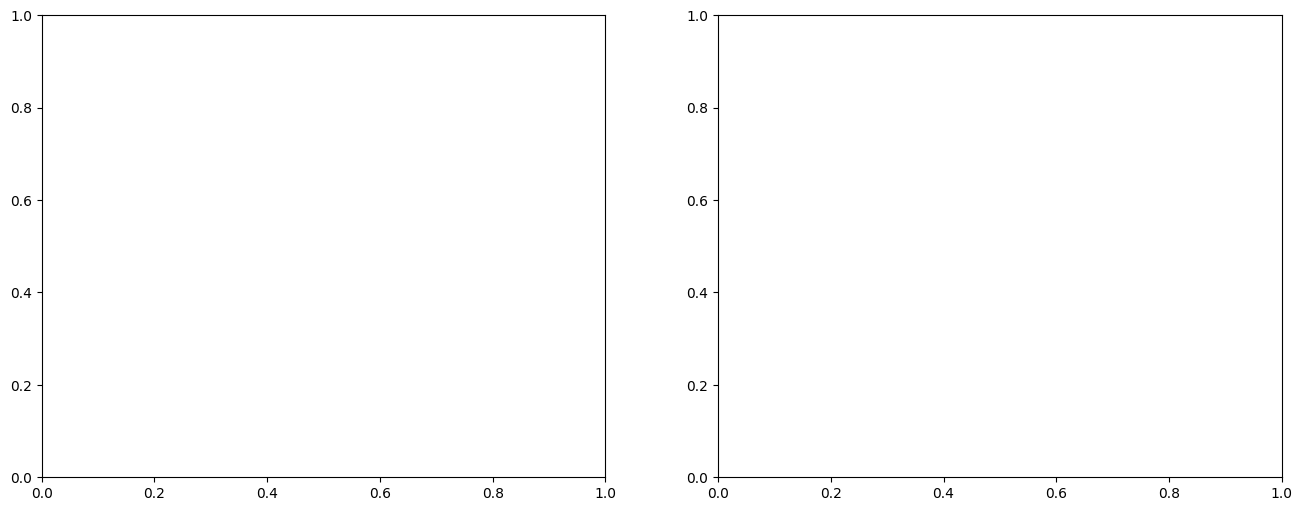

In [ ]:
# Cell 28: Visualization of Sensitivity Analysis Results

import matplotlib.pyplot as plt

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Port Delay Sensitivity
if port_delay_results and port_delay_results.get('test_results'):
    test_results = port_delay_results['test_results']
    if test_results:
        delays = [r['delay_days'] for r in test_results]
        current_profits = [r['current_profit'] for r in test_results]
        next_best_profits = [r['next_best_profit'] for r in test_results]
        
        ax1.plot(delays, current_profits, 'b-o', label='Current Solution', linewidth=2, markersize=6)
        ax1.plot(delays, next_best_profits, 'r-s', label='Next-Best Solution', linewidth=2, markersize=6)
        
        # Highlight threshold
        threshold = port_delay_results['threshold_delay_days']
        ax1.axvline(x=threshold, color='g', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.2f} days')
        
        ax1.set_xlabel('Additional Delay Days', fontsize=12)
        ax1.set_ylabel('Total Profit ($)', fontsize=12)
        ax1.set_title('Port Delay Sensitivity Analysis', fontsize=14, fontweight='bold')
        ax1.legend(fontsize=10)
        ax1.grid(True, alpha=0.3)
        ax1.ticklabel_format(style='plain', axis='y')
    else:
        ax1.text(0.5, 0.5, 'No test results available', ha='center', va='center', transform=ax1.transAxes)
        ax1.set_title('Port Delay Sensitivity Analysis', fontsize=14, fontweight='bold')
else:
    ax1.text(0.5, 0.5, 'Port delay analysis not run', ha='center', va='center', transform=ax1.transAxes)
    ax1.set_title('Port Delay Sensitivity Analysis', fontsize=14, fontweight='bold')

# Plot 2: Bunker Price Sensitivity
if bunker_price_results and bunker_price_results.get('test_results'):
    test_results = bunker_price_results['test_results']
    if test_results:
        multipliers = [r['multiplier'] for r in test_results]
        price_increases = [r['price_increase_pct'] for r in test_results]
        current_profits = [r['current_profit'] for r in test_results]
        next_best_profits = [r['next_best_profit'] for r in test_results]
        
        ax2.plot(price_increases, current_profits, 'b-o', label='Current Solution', linewidth=2, markersize=6)
        ax2.plot(price_increases, next_best_profits, 'r-s', label='Next-Best Solution', linewidth=2, markersize=6)
        
        # Highlight threshold
        threshold_pct = bunker_price_results['threshold_price_increase_pct']
        ax2.axvline(x=threshold_pct, color='g', linestyle='--', linewidth=2, 
                   label=f'Threshold: {threshold_pct:.1f}% increase')
        
        ax2.set_xlabel('Bunker Price Increase (%)', fontsize=12)
        ax2.set_ylabel('Total Profit ($)', fontsize=12)
        ax2.set_title('Bunker Price Sensitivity Analysis', fontsize=14, fontweight='bold')
        ax2.legend(fontsize=10)
        ax2.grid(True, alpha=0.3)
        ax2.ticklabel_format(style='plain', axis='y')
    else:
        ax2.text(0.5, 0.5, 'No test results available', ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title('Bunker Price Sensitivity Analysis', fontsize=14, fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'Bunker price analysis not run', ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('Bunker Price Sensitivity Analysis', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Sensitivity analysis visualizations created")

## Chatbot Demo

Runs 2–3 example queries against the voyage optimization data. Disabled if API keys are not configured.

In [ ]:
# Chatbot demo (safe on/off: requires API keys in chatbot_config.txt)
CHATBOT_ENABLED = False
cfg = {}
try:
    from load_env import load_env_file
    cfg = load_env_file("config/chatbot_config.txt") or load_env_file(".env") or {}
    tk = cfg.get("TEAM_API_KEY", "") or cfg.get("OPENAI_API_KEY", "")
    sk = cfg.get("SHARED_OPENAI_KEY", "")
    CHATBOT_ENABLED = bool(tk and sk and "your-" not in str(tk).lower())
except Exception:
    pass

if CHATBOT_ENABLED and cfg:
    from voyage_chatbot import VoyageChatbot
    chatbot = VoyageChatbot(team_api_key=cfg["TEAM_API_KEY"], shared_openai_key=cfg["SHARED_OPENAI_KEY"])
    for q in ["What is the best voyage assignment for PACIFIC GLORY?", "Compare the top 3 most profitable voyages.", "How does risk adjustment affect the portfolio?"]:
        print(f"Q: {q[:60]}...")
        print(f"A: {chatbot.chat(q)[:300]}...")
        print()
else:
    print("Chatbot disabled (API keys not configured in config/chatbot_config.txt or .env)")